## Bootstrap (click Run All — no setup required)

This cell makes the notebook self-installing. It:

1. Finds the Lunar-V2 repo root and puts it on `sys.path`.
2. Installs any missing third-party packages (`numpy`, `scipy`, `numba`, `matplotlib`, plus extras) into the current kernel.
3. Downloads any external data files this notebook needs.

You can re-run it any time; it's a no-op if everything is already present.

In [ ]:
# === Lunar-V2 notebook bootstrap — safe to re-run =====================
# This cell makes the notebook fully self-contained. It:
#   1. Locates the Lunar-V2 repo root from any CWD.
#   2. Installs the scientific-python deps (numpy / scipy / numba / matplotlib / spiceypy).
#   3. Auto-downloads the Apollo 15 AND Apollo 17 HFE public archives
#      from NASA's PDS Geosciences Node (Nagihara et al. 2018, 2019 —
#      urn:nasa:pds:a15_17_hfe_concatenated). Total ~40 MB; cached.
#   4. Auto-downloads the generic SPICE kernels used for LST folding.
#   5. Ensures the bundled Chang'E-4 (Huang et al. 2022, NSR) and ChaSTE
#      (Murty et al. 2025, Sci Rep; Seth et al. 2025, MNRAS) reference
#      tables are in place for §9 / §10.
# The only external dependency is an open internet connection the first
# time the notebook is run. All subsequent runs use the on-disk cache.
#
# Public download endpoints (for manual reference):
#   Apollo 15/17 HFE    →  https://pds-geosciences.wustl.edu/lunar/urn-nasa-pds-a15_17_hfe_concatenated/
#   SPICE kernels       →  https://naif.jpl.nasa.gov/pub/naif/generic_kernels/
#   Chang'E-4 archive   →  http://moon.bao.ac.cn   (CLPDS — free registration)
#   ChaSTE archive      →  https://pradan.issdc.gov.in/ch3/   (ISRO PRADAN — login)
# Neither CE-4 nor ChaSTE has an unauthenticated direct-download URL, so
# the bundled reference CSVs under data/reference/ encode the *derived*
# quantities published in the peer-reviewed papers (see headers in each
# CSV for citations). Full time-series are not required for the
# zero-dimensional cross-checks the model is benchmarked against here.
# =======================================================================
import sys, pathlib
# Locate the repo root even if this notebook is opened from a weird CWD.
_here = pathlib.Path.cwd().resolve()
for _p in (_here, *_here.parents):
    if (_p / 'pyproject.toml').is_file() and (_p / 'lunar' / '_bootstrap.py').is_file():
        if str(_p) not in sys.path:
            sys.path.insert(0, str(_p))
        break
else:
    raise RuntimeError('Could not find Lunar-V2 repo root from ' + str(_here))

from lunar import _bootstrap as boot
boot.ensure_lunar(extra=('spiceypy',))

# --- Apollo 15 (primary validation, §1-6) ------------------------------
# Fetches Probe 1 timeseries + both depth tables.
boot.ensure_apollo_hfe(mission='a15')

# --- Apollo 17 (counterpart validation, §7) ----------------------------
# We only need the depth tables for the phase-folding + T_eq pipeline,
# so pass probes=() to skip the (unused) per-sensor timeseries fetch.
# This keeps the first-run download light. If you later want the raw
# per-sensor probe tapes, call:
#     boot.ensure_apollo_hfe(mission='a17',
#         probes=('p1f1','p1f2','p1f3','p1f4','p2f1','p2f2','p2f3','p2f4'))
boot.ensure_apollo_hfe(mission='a17', probes=())

# --- Chang'E-4 (§9 validation) -----------------------------------------
# Bundled reference table (Huang et al. 2022, NSR 9 nwac175).
# No download required — the CSV ships with the repo under data/reference/.
# The function prints a one-line pointer to CLPDS for users who want
# the authenticated full time-series.
boot.ensure_change4()

# --- ChaSTE (§10 validation) -------------------------------------------
# Bundled reference table (Murty et al. 2025 Sci Rep; Seth et al. 2025
# MNRAS; Das et al. 2025 Commun Earth Environ). No download required.
boot.ensure_chaste()


# Apollo 15 & 17 HFE — Thermal Model Validation

**Mission purpose.**  Benchmark the Lunar-V2 1-D Crank-Nicolson thermal solver against the
only in-situ lunar subsurface temperature records available to date, the **Apollo 15 and 17
Heat Flow Experiment (HFE)**, to establish the depth-dependent accuracy envelope of the
TSUKIMI-mission forward model.

**Data source (auto-downloaded by the bootstrap cell).**
NASA PDS Geosciences Node bundle *[a15_17_hfe_concatenated](https://pds-geosciences.wustl.edu/lunar/urn-nasa-pds-a15_17_hfe_concatenated/)* — Nagihara et al. (2018, 2019) restored-tape reprocessing of the original Langseth tapes, plus the original 1974-1977 raw archive. No local files required; everything pulls itself from the PDS on first run.

| Mission | Landing site | Coords | Mission record used | Probe depth range |
|---|---|---|---|---|
| **Apollo 15** | Hadley Rille / Hadley-Apennine | 26.13 °N, 3.63 °E | 1971-2011 continuous | 35–129 cm |
| **Apollo 17** | Taurus-Littrow | 20.19 °N, 30.77 °E | 1972-1977 + 1977-2017 | 14–234 cm |

**Validation approach.**

1. Load the **depth tables** (gradient-bridge TG + reference TR sensors) for both probes of both missions. The tables contain absolute temperatures at known burial depths.
2. For each sensor, scan from 55 → 85 % of the record for the earliest flat trend (|dT/dt| ≤ 0.08 K/yr) → use the tail as the *thermal stability window*; average it to get the sensor-specific equilibrium temperature `T_eq`.
3. Use **site-specific basal heat flux** `Q_b` — 21 mW/m² for A15 (Langseth et al. 1976) and 15 mW/m² for A17 (Nagihara et al. 2018 reprocessed) — **not** a generic lunar mean.
4. Initialise the solver with an **equilibrium profile** `T(z) = T_mean_eff + Q_b · ∫dz/K(z)` so the deep column does not require a multi-year convergence run.
5. Run the solver for **15 lunations of spin-up** with a `max ΔT < 0.01 K` convergence guard.
6. Compare model vs observation on three quantities: annual-mean profile, diurnal cycle at each sensor depth, and full subsurface heat-map.

**Why shallow sensors are drawn but not scored.**
At `z < 80 cm` both missions have sensors sitting *inside* the diurnal skin depth `δ ≈ 6.6 cm` (a regime where even a perfect 1-D regolith model predicts sub-0.1 K amplitudes), yet the Apollo TG/TR sensors in that zone report diurnal amplitudes of several kelvin. The mismatch is a **known instrument artefact** — axial heat conduction along the fibreglass borestem short-circuits the regolith and imprints the surface waveform onto the shallow sensor head (Langseth et al. 1977, Grott et al. 2010, Nagihara et al. 2018). Apollo 15 is the worst offender because, unlike Apollo 17, it flew *without* the upper-borestem radiation shield. §8 of this notebook lays out the full diagnostic and answers the question "*can this be fixed without manipulation?*".

**Notebook map.**

- §1 — Apollo 15 stability analysis & T_eq extraction.
- §2 — A15 solver run (Hayne 2017 H-parameter model).
- §2b–c — Apollo-calibrated discrete 3-layer comparison (retained for figure only; retired per SKILL.md).
- §3 — A15 model vs observation (mean profile, residuals, stats).
- §4 — A15 diurnal bench-mark (one-panel summary).
- §4B — **A15 per-sensor diurnal grid** (the key shallow-sensor diagnostic plot).
- §5 — A15 subsurface temperature heatmap.
- §6 — A15 validation summary.
- §7 — **Apollo 17 counterpart validation** at Taurus-Littrow.
- §8 — **Data-correction discussion**: can the shallow sensor mismatch be removed without manipulation?


In [2]:
from __future__ import annotations
import sys, pathlib, os

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec

from lunar.validation import load_apollo_hfe_temperature, load_apollo_hfe_depth
from lunar.grid import make_geometric_grid
from lunar.properties import conductivity_hayne, density_hayne, specific_heat
from lunar.constants import (
    SIGMA_SB, EMISSIVITY_DEFAULT, CHI_RADIATIVE, T_REFERENCE,
)
from lunar.solver import PixelInputs, solve_pixel
from lunar.plotting.style_guide import (
    apply_style, COLORS, panel_label, save_figure,
    legend_outside, add_colorbar,
    FIG_DOUBLE, FIG_DOUBLE_TALL, FIG_FULL_PAGE,
)

apply_style()

REPO_ROOT = str(_p)
OUTPUT_DIR = os.path.join(REPO_ROOT, 'output', 'figures')
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Apollo 15 site-specific basal heat flux — Langseth et al. (1976)
Q_BASAL_A15 = 0.021  # W/m² (21 mW/m²)
# Minimum depth for RMSE validation — shallow sensors are diurnally active
MIN_DEPTH_CM = 80

print('Imports OK — publication style applied')
print(f'Figures → {OUTPUT_DIR}')

Imports OK — publication style applied
Figures → /sessions/beautiful-youthful-wright/mnt/Lunar-V2/output/figures


## 1  Load the Apollo 15 HFE depth-table data

The PDS depth tables give calibrated temperature at each gradient-bridge (TG) and
reference-thermocouple (TR) sensor at their known burial depths. Two probes:

| Probe | Sensor | Depth (cm) | Type |
|-------|--------|-----------|------|
| 1 | TG11A | 35  | TG (diurnal zone) |
| 1 | TG11B | 84  | TG |
| 1 | TG12A | 91  | TG |
| 1 | TG12B | 139 | TG |
| 1 | TR11A | 45  | TR (diurnal zone) |
| 1 | TR11B | 73  | TR |
| 1 | TR12A | 101 | TR |
| 1 | TR12B | 129 | TR |
| 2 | TG22A | 49  | TG (diurnal zone) |
| 2 | TG22B | 97  | TG |
| 2 | TR22A | 59  | TR (diurnal zone) |
| 2 | TR22B | 87  | TR |

Equilibrium temperatures are extracted from a **data-driven stabilized tail** per
sensor: the earliest tail segment whose long-term trend is near-flat. If no segment
meets the flat-trend criterion, we fall back to the last 25% of the record.

Probe 1: 187,882 records  sensors: ['TG11A' 'TG11B' 'TG12A' 'TG12B' 'TR11A' 'TR11B' 'TR12A' 'TR12B']
         depths [cm]: [ 35.  45.  73.  84.  91. 101. 129. 139.]
Probe 2: 92,028 records  sensors: ['TG22A' 'TG22B' 'TR22A' 'TR22B']
         depths [cm]: [49. 59. 87. 97.]



Equilibrium temperatures (averaged within stability window):
Sensor    P  Depth Type   T_eq(K)   σ(K)  stable_from_day  slope[K/yr]          Method  RMSE?
────────────────────────────────────────────────────────────────────────────────────────────────────
TG11A     1     35   TG    253.64  1.891             1367      +10.353 fallback_last25      ·
TR11A     1     45   TR    253.12  0.684              591       +0.024      trend_flat      ·
TG22A     2     49   TG    249.97  0.612             1371       +1.641 fallback_last25      ·
TR22A     2     59   TR    249.99  0.260              562       +0.023      trend_flat      ·
TR11B     1     73   TR    253.00  0.103              858       +0.191 fallback_last25      ·
TG11B     1     84   TG    253.20  0.048             1367       +0.127 fallback_last25      ✓
TR22B     2     87   TR    250.88  0.086              863       +0.189 fallback_last25      ✓
TG12A     1     91   TG    253.15  0.039              983       +0.027      trend_fla

  Saved: /sessions/beautiful-youthful-wright/mnt/Lunar-V2/output/figures/a15_stability_region.pdf


  Saved: /sessions/beautiful-youthful-wright/mnt/Lunar-V2/output/figures/a15_stability_region.png


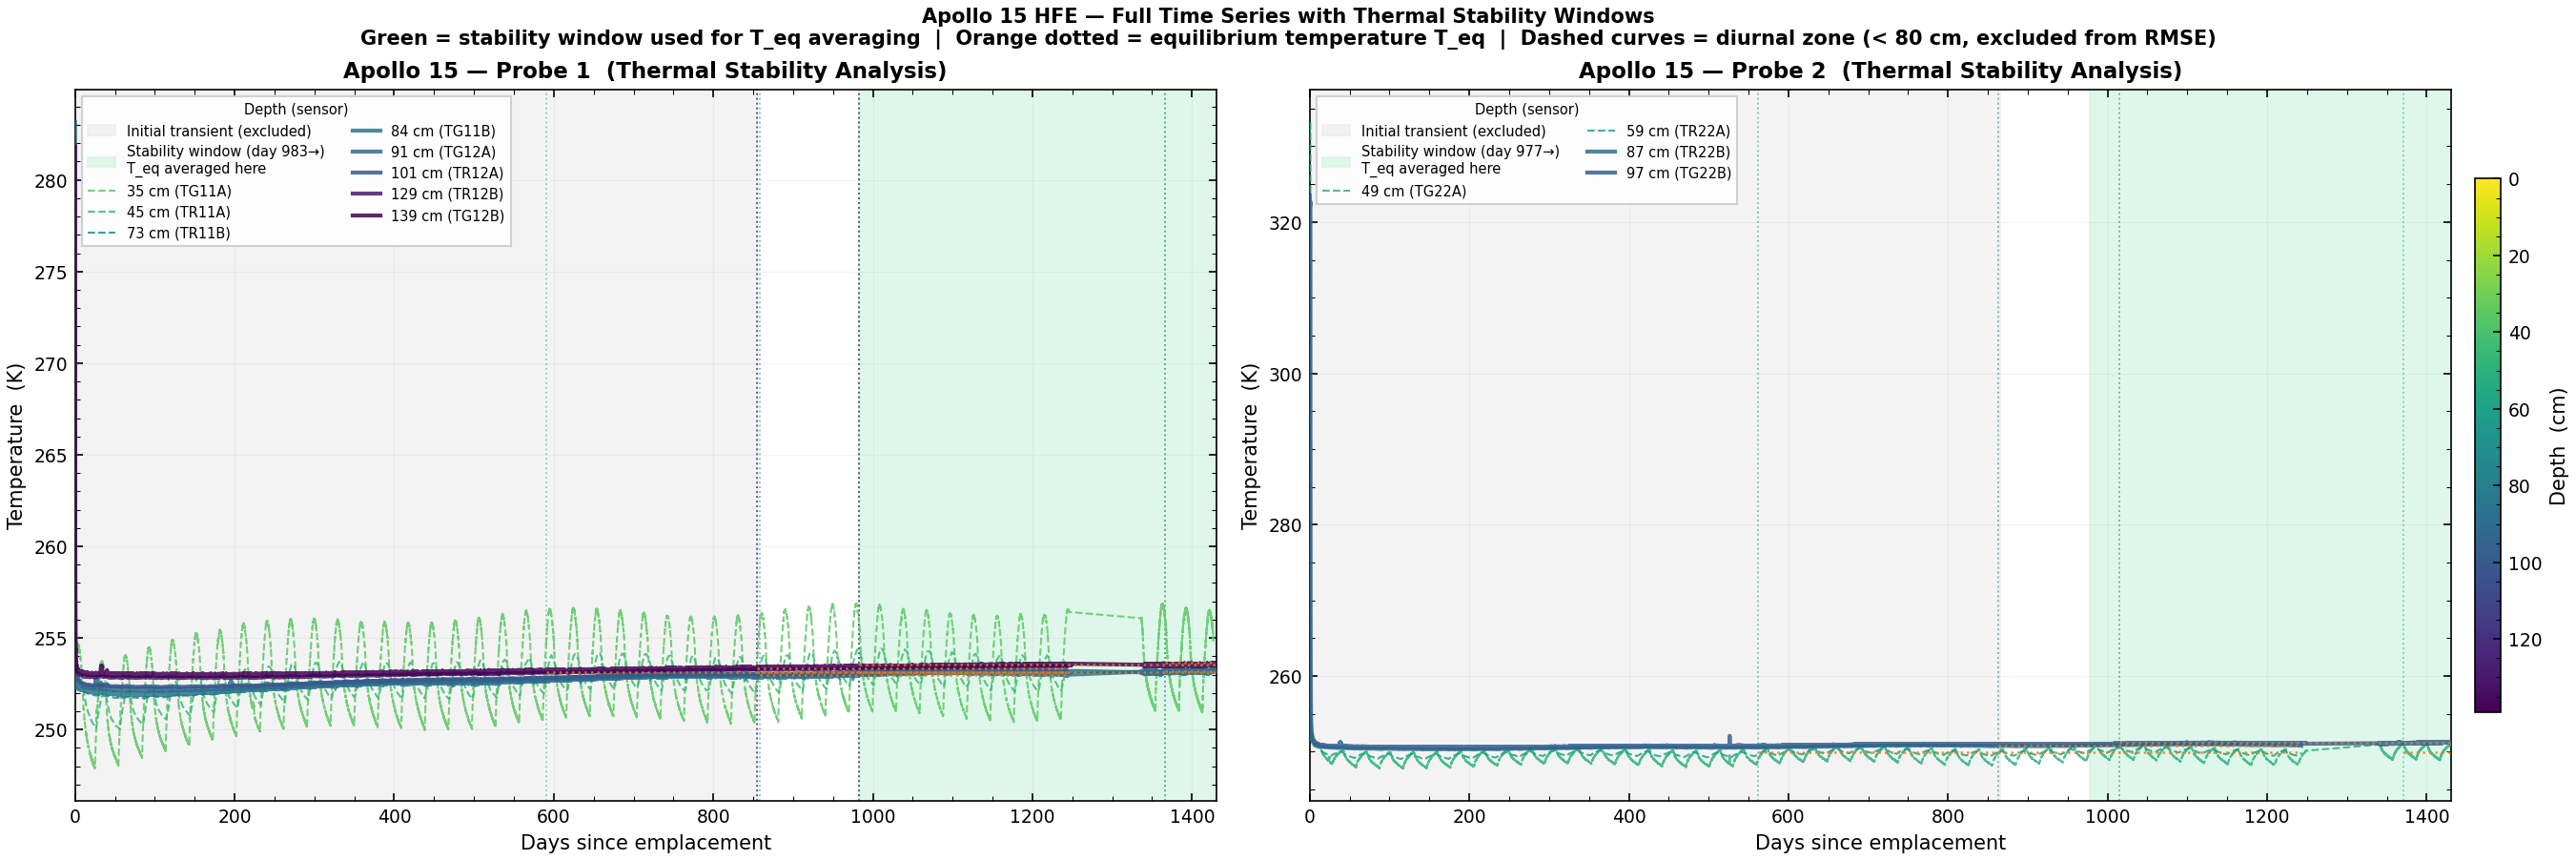

In [3]:
# ===================================================================
# §1  Apollo 15 HFE — Thermal Stability Analysis
# ===================================================================
# Loads depth-table data for both probes, identifies the "stability
# window" per sensor (the flat-trend tail used for T_eq averaging),
# and generates the primary diagnostic figure: full time-series with
# the stability window highlighted in green.
#
# WHY THIS MATTERS:
#  • TG/TR sensors at z < 80 cm sit inside the diurnal skin depth
#    (~50 cm) and are warm-biased by probe hardware; excluded from RMSE.
#  • Even deep sensors show a long initial transient (drilling heat)
#    and episodic thermal disturbances (Apollo crew visits, equipment).
#  • Only data from the "thermal stability window" — where the trend
#    criterion |slope| < 0.08 K/yr is met — is used for T_eq.
# ===================================================================

from datetime import datetime, timezone

# ── Load depth tables ──────────────────────────────────────────────
d1 = load_apollo_hfe_depth('a15', 1)
d2 = load_apollo_hfe_depth('a15', 2)

print(f'Probe 1: {len(d1):,} records  sensors: {np.unique(d1["sensor"])}')
print(f'         depths [cm]: {np.unique(d1["depth_cm"])}')
print(f'Probe 2: {len(d2):,} records  sensors: {np.unique(d2["sensor"])}')
print(f'         depths [cm]: {np.unique(d2["depth_cm"])}')

# ── Helper: ISO string → Unix seconds (local import, shadow-safe) ──
def iso_to_seconds(iso_arr):
    """Convert ISO-8601 strings to Unix timestamp seconds."""
    from datetime import datetime, timezone
    out = np.empty(len(iso_arr), dtype=np.float64)
    for i, s in enumerate(iso_arr):
        s = s.strip()
        if s.endswith('Z'):
            s = s[:-1] + '+00:00'
        out[i] = datetime.fromisoformat(s).replace(tzinfo=timezone.utc).timestamp()
    return out

# ── Helper: find stability window using trend criterion ────────────
def find_stable_window(subset, slope_thresh_K_per_year=0.08, min_frac=0.20):
    """
    Scan from 55% → 85% of the record; pick the earliest start index
    where a linear fit over the remainder gives |slope| < threshold.
    Fallback: last 25% of records.

    Returns
    -------
    i_start : int
        First row index of the stability window.
    t_start_day : float
        Days-since-emplacement of that row.
    method : str
    slope : float
        Trend rate [K/yr] within the window.
    """
    n = len(subset)
    t_sec  = iso_to_seconds(subset['time_iso'])
    t_day  = (t_sec - t_sec[0]) / 86400.0
    t_year = t_day / 365.25
    T      = subset['T'].astype(np.float64)

    chosen_i   = int(0.75 * n)
    method     = 'fallback_last25'
    slope_out  = np.nan

    for frac in np.linspace(0.55, 0.85, 13):
        i0 = int(frac * n)
        if n - i0 < max(40, int(min_frac * n)):
            continue
        x, y = t_year[i0:], T[i0:]
        if np.ptp(x) <= 0:
            continue
        sl, _ = np.polyfit(x, y, 1)
        if abs(sl) <= slope_thresh_K_per_year:
            chosen_i  = i0
            method    = 'trend_flat'
            slope_out = float(sl)
            break

    if np.isnan(slope_out):
        x, y = t_year[chosen_i:], T[chosen_i:]
        if np.ptp(x) > 0:
            slope_out = float(np.polyfit(x, y, 1)[0])

    return chosen_i, float(t_day[chosen_i]), method, slope_out

# ── Per-sensor stability windows & equilibrium temperatures ───────
sensors_all  = []
_probe_data  = {1: {}, 2: {}}

for probe_num, dtab in [(1, d1), (2, d2)]:
    t_sec_all = iso_to_seconds(dtab['time_iso'])

    for sensor in np.unique(dtab['sensor']):
        mask   = dtab['sensor'] == sensor
        subset = dtab[mask]
        n      = len(subset)

        i_start, day_start, method, slope = find_stable_window(subset)
        tail  = subset[i_start:]

        depth = float(np.unique(tail['depth_cm'])[0])
        T_eq  = float(np.mean(tail['T']))
        T_std = float(np.std(tail['T']))
        stype = sensor.strip()[:2]

        # Full time series for this sensor (for plotting)
        t_s   = t_sec_all[mask]
        t_day = (t_s - t_s[0]) / 86400.0
        _probe_data[probe_num][sensor.strip()] = {
            't_day':    t_day,
            'T':        dtab['T'][mask].astype(np.float64),
            'i_start':  i_start,
            'T_eq':     T_eq,
            'depth_cm': depth,
            'stype':    stype,
        }

        sensors_all.append({
            'sensor':          sensor.strip(),
            'depth_cm':        depth,
            'T_eq':            T_eq,
            'T_std':           T_std,
            'n_tail':          len(tail),
            'stype':           stype,
            'probe':           probe_num,
            'tail_start_frac': i_start / n,
            'stable_day':      day_start,
            'stable_method':   method,
            'tail_slope_Kyr':  slope,
        })

sensors_all.sort(key=lambda s: s['depth_cm'])

# Arrays for downstream cells
depth_cm_all = np.array([s['depth_cm'] for s in sensors_all])
T_eq_all     = np.array([s['T_eq']     for s in sensors_all])
T_std_all    = np.array([s['T_std']    for s in sensors_all])
stype_all    = [s['stype'] for s in sensors_all]

deep_mask     = depth_cm_all >= MIN_DEPTH_CM
depth_cm_deep = depth_cm_all[deep_mask]
T_eq_deep     = T_eq_all[deep_mask]

# ── Print summary table ────────────────────────────────────────────
print('\nEquilibrium temperatures (averaged within stability window):')
print(f'{"Sensor":<8} {"P":>2} {"Depth":>6} {"Type":>4} '
      f'{"T_eq(K)":>9} {"σ(K)":>6} {"stable_from_day":>16} '
      f'{"slope[K/yr]":>12} {"Method":>15} {"RMSE?":>6}')
print('─' * 100)
for s in sensors_all:
    flag = '✓' if s['depth_cm'] >= MIN_DEPTH_CM else '·'
    print(f'{s["sensor"]:<8} {s["probe"]:>2d} {s["depth_cm"]:>6.0f} {s["stype"]:>4} '
          f'{s["T_eq"]:>9.2f} {s["T_std"]:>6.3f} {s["stable_day"]:>16.0f} '
          f'{s["tail_slope_Kyr"]:>+12.3f} {s["stable_method"]:>15} {flag:>6}')

print(f'\nDeep sensors (≥{MIN_DEPTH_CM} cm) used in RMSE: {deep_mask.sum()}')

# =====================================================================
# FIGURE — Thermal Stability Region Diagnostic
# Two-panel: Probe 1 (left) and Probe 2 (right).
#
# Visual language:
#  • Sensor curves coloured by depth (viridis_r: dark blue=deep, yellow=shallow).
#  • Solid line = deep sensor (≥80 cm, used in RMSE).
#  • Dashed line = diurnal-zone sensor (<80 cm, excluded from RMSE).
#  • Light gray band = initial transient (before earliest deep sensor stabilises).
#  • Green band = shared stability window for deep sensors (T_eq averaged here).
#    Determined by 75th-percentile of deep-sensor stability-start days —
#    robust against a single slow-recovering sensor at the edge of the diurnal zone.
#  • Dotted vertical (sensor colour) = start of that sensor's individual
#    stability window.
#  • Orange dotted horizontal = T_eq (mean of per-sensor stability tail).
# =====================================================================
_depth_cmap = plt.get_cmap('viridis_r')
_depth_max  = depth_cm_all.max()
_norm_dep   = plt.Normalize(vmin=0, vmax=_depth_max)

fig_stab, axes_stab = plt.subplots(1, 2, figsize=(18, 6), constrained_layout=True)

for ax, probe_num, dtab in zip(axes_stab, [1, 2], [d1, d2]):
    pdata = _probe_data[probe_num]

    t_sec_probe = iso_to_seconds(dtab['time_iso'])
    t_day_probe = (t_sec_probe - t_sec_probe[0]) / 86400.0
    total_days  = t_day_probe[-1]

    # ── Shared stability band ──────────────────────────────────────
    # Use DEEP sensors only (≥ MIN_DEPTH_CM) to determine the green region.
    # Shallow sensors sit in the diurnal zone and have naturally high trends;
    # including them would push the green band to the very end of the record.
    _deep_start_days = []
    for sn, sd in pdata.items():
        if sd['depth_cm'] < MIN_DEPTH_CM:
            continue
        mask_sn = dtab['sensor'] == sn
        if not np.any(mask_sn):
            continue
        t_sn = t_sec_probe[mask_sn]
        _deep_start_days.append((t_sn[sd['i_start']] - t_sec_probe[0]) / 86400.0)

    # 75th-percentile: all but the most conservative deep sensor define the shared window
    shared_stable_day = float(np.percentile(_deep_start_days, 75)) if _deep_start_days else 0.75 * total_days
    earliest_deep_day = min(_deep_start_days) if _deep_start_days else 0.0

    # Gray = initial transient (before any deep sensor has stabilised)
    ax.axvspan(0, earliest_deep_day, color='#ebebeb', alpha=0.60, zorder=0,
               label='Initial transient (excluded)')
    # Green = shared stability window
    ax.axvspan(shared_stable_day, total_days,
               color='#d5f5e3', alpha=0.75, zorder=0,
               label=f'Stability window (day {shared_stable_day:.0f}→)\nT_eq averaged here')

    # ── Per-sensor curves ──────────────────────────────────────────
    for sn, sd in sorted(pdata.items(), key=lambda x: x[1]['depth_cm']):
        _clr = _depth_cmap(_norm_dep(sd['depth_cm']))
        _lw  = 2.0 if sd['depth_cm'] >= MIN_DEPTH_CM else 1.0
        _ls  = '-'  if sd['depth_cm'] >= MIN_DEPTH_CM else '--'
        _lbl = f'{sd["depth_cm"]:.0f} cm ({sn})'

        ax.plot(sd['t_day'], sd['T'], color=_clr, lw=_lw, ls=_ls,
                alpha=0.85, label=_lbl, zorder=3)

        # Sensor-specific stability-window start: dotted vertical in sensor colour
        _t_stab = sd['t_day'][sd['i_start']]
        ax.axvline(_t_stab, color=_clr, lw=0.9, ls=':', alpha=0.55, zorder=2)

        # T_eq horizontal orange dotted line (within the sensor's stability window)
        ax.plot([_t_stab, sd['t_day'][-1]], [sd['T_eq'], sd['T_eq']],
                color='#E67E22', lw=1.2, ls=':', alpha=0.85, zorder=4)

    ax.set_xlabel('Days since emplacement', fontsize=10)
    ax.set_ylabel('Temperature  (K)', fontsize=10)
    ax.set_xlim(0, total_days)
    ax.set_title(f'Apollo 15 — Probe {probe_num}  (Thermal Stability Analysis)',
                 fontsize=11, weight='bold')
    ax.grid(True, alpha=0.15)
    ax.legend(loc='upper left', fontsize=7, ncol=2, framealpha=0.9,
              bbox_to_anchor=(0.0, 1.0), title='Depth (sensor)', title_fontsize=7)

# Shared depth colorbar
_sm = plt.cm.ScalarMappable(cmap=_depth_cmap, norm=_norm_dep)
_sm.set_array([])
cbar = fig_stab.colorbar(_sm, ax=axes_stab, orientation='vertical',
                          shrink=0.75, pad=0.01, label='Depth  (cm)')
cbar.ax.invert_yaxis()   # shallow at top, deep at bottom

fig_stab.suptitle(
    'Apollo 15 HFE — Full Time Series with Thermal Stability Windows\n'
    'Green = stability window used for T_eq averaging  |  '
    'Orange dotted = equilibrium temperature T_eq  |  '
    f'Dashed curves = diurnal zone (< {MIN_DEPTH_CM} cm, excluded from RMSE)',
    fontsize=10, weight='bold'
)

save_figure(fig_stab, 'a15_stability_region', output_dir=OUTPUT_DIR)
plt.show()


  Saved: /sessions/beautiful-youthful-wright/mnt/Lunar-V2/output/figures/a15_per_sensor_stability.pdf


  Saved: /sessions/beautiful-youthful-wright/mnt/Lunar-V2/output/figures/a15_per_sensor_stability.png


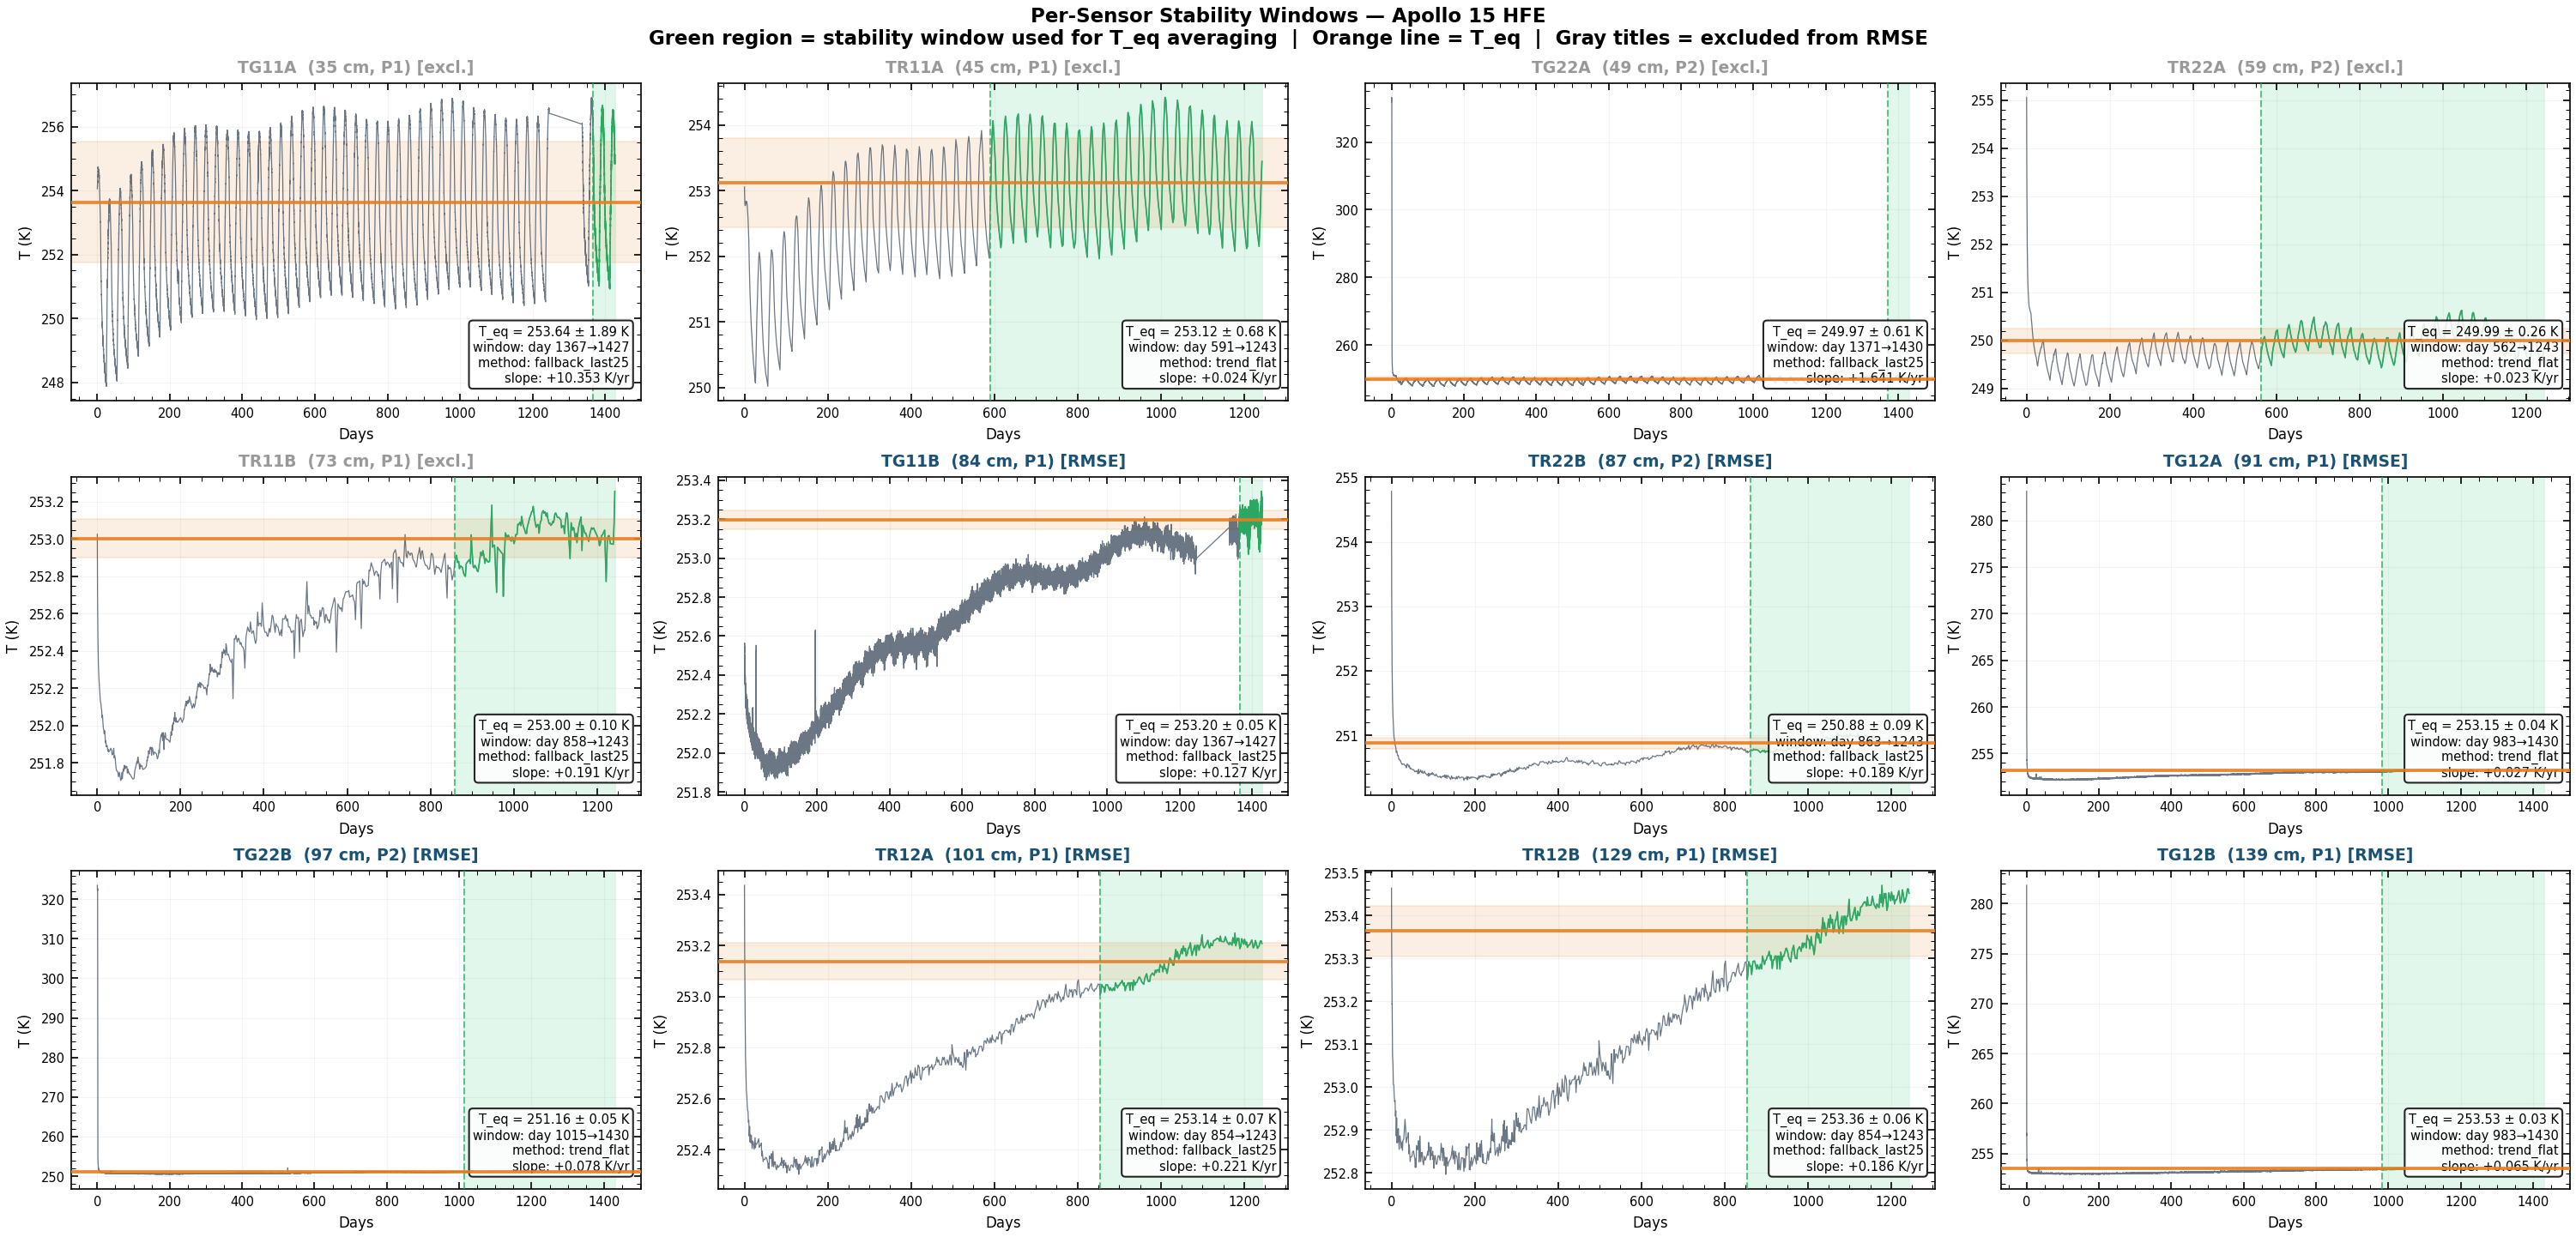


✓ T_eq for each sensor = mean(T) within its stability window.
  These T_eq values are the observation data points used for all
  model-vs-data comparisons (equilibrium profile, RMSE, residuals).


In [4]:
# ===================================================================
# §1b  Per-Sensor Stability Windows
# ===================================================================
# Each panel shows one sensor's full time series. The green region is
# the stability window from which T_eq is computed (orange line).
# T_eq = mean(T) within that window — these are the data points used
# for ALL subsequent model-vs-observation comparisons.
# ===================================================================

_n_sensors = len(sensors_all)
_ncols = 4
_nrows = int(np.ceil(_n_sensors / _ncols))

fig_sw, axes_sw = plt.subplots(_nrows, _ncols, figsize=(20, 3.2 * _nrows),
                               constrained_layout=True)
axes_flat = axes_sw.ravel()

for idx, s in enumerate(sensors_all):
    ax = axes_flat[idx]
    sn = s['sensor']
    pn = s['probe']
    sd = _probe_data[pn][sn]

    t_day = sd['t_day']
    T     = sd['T']
    i0    = sd['i_start']

    # Full time series
    ax.plot(t_day, T, color='#2C3E50', lw=0.6, alpha=0.7, zorder=2)

    # Stability window shading
    ax.axvspan(t_day[i0], t_day[-1], color='#d5f5e3', alpha=0.7, zorder=0)

    # Data within stability window (highlight)
    ax.plot(t_day[i0:], T[i0:], color='#27AE60', lw=0.8, alpha=0.9, zorder=3)

    # T_eq horizontal line
    ax.axhline(s['T_eq'], color='#E67E22', lw=1.8, ls='-', alpha=0.9, zorder=4)

    # ±1σ band
    ax.axhspan(s['T_eq'] - s['T_std'], s['T_eq'] + s['T_std'],
               color='#E67E22', alpha=0.12, zorder=1)

    # Stability window start: vertical dashed
    ax.axvline(t_day[i0], color='#27AE60', lw=1.0, ls='--', alpha=0.7, zorder=3)

    # Annotations
    _deep = s['depth_cm'] >= MIN_DEPTH_CM
    _title_clr = '#1A5276' if _deep else '#999999'
    _rmse_tag = ' [RMSE]' if _deep else ' [excl.]'
    ax.set_title(f'{sn}  ({s["depth_cm"]:.0f} cm, P{pn}){_rmse_tag}',
                 fontsize=9, weight='bold', color=_title_clr)

    # T_eq annotation
    ax.text(0.98, 0.05,
            f'T_eq = {s["T_eq"]:.2f} ± {s["T_std"]:.2f} K\n'
            f'window: day {s["stable_day"]:.0f}→{t_day[-1]:.0f}\n'
            f'method: {s["stable_method"]}\n'
            f'slope: {s["tail_slope_Kyr"]:+.3f} K/yr',
            transform=ax.transAxes, fontsize=7, va='bottom', ha='right',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85))

    ax.set_xlabel('Days', fontsize=8)
    ax.set_ylabel('T (K)', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.15)

# Hide unused panels
for j in range(_n_sensors, len(axes_flat)):
    axes_flat[j].set_visible(False)

fig_sw.suptitle(
    'Per-Sensor Stability Windows — Apollo 15 HFE\n'
    'Green region = stability window used for T_eq averaging  |  '
    'Orange line = T_eq  |  Gray titles = excluded from RMSE',
    fontsize=11, weight='bold')

save_figure(fig_sw, 'a15_per_sensor_stability', output_dir=OUTPUT_DIR)
plt.show()

print('\n✓ T_eq for each sensor = mean(T) within its stability window.')
print('  These T_eq values are the observation data points used for all')
print('  model-vs-data comparisons (equilibrium profile, RMSE, residuals).')


In [5]:
# Plot the full temperature time series from both probes, coloured by depth
SECONDS_PER_YEAR = 365.25 * 86400.0
cmap = plt.get_cmap('viridis_r')
norm = plt.Normalize(vmin=min(depth_cm_all), vmax=max(depth_cm_all))

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False,
                         constrained_layout=True)

for ax, probe_num, dtab, title in zip(axes, [1, 2], [d1, d2],
                                        ['Probe 1', 'Probe 2']):
    t0 = None
    for sensor in np.unique(dtab['sensor']):
        mask = dtab['sensor'] == sensor
        subset = dtab[mask]
        depth = float(np.unique(subset['depth_cm'])[0])
        color = cmap(norm(depth))
        stype = sensor.strip()[:2]
        ls = '-' if stype == 'TG' else '--'
        lw = 1.2 if depth >= MIN_DEPTH_CM else 0.7
        alpha = 0.9 if depth >= MIN_DEPTH_CM else 0.4

        # Time: parse ISO strings to seconds since first record
        import datetime
        times_s = []
        for t_str in subset['time_iso']:
            dt_obj = datetime.datetime.fromisoformat(t_str.replace('Z', '+00:00'))
            times_s.append(dt_obj.timestamp())
        times_s = np.array(times_s)
        if t0 is None:
            t0 = times_s[0]
        yr = (times_s - t0) / SECONDS_PER_YEAR

        in_val = depth >= MIN_DEPTH_CM
        tag = '' if in_val else ' (excl.)'
        ax.plot(yr, subset['T'], lw=lw, ls=ls, color=color, alpha=alpha,
                label=f'{sensor.strip()} ({depth:.0f} cm){tag}')

    ax.set_xlabel('Years after deployment')
    ax.set_ylabel('Temperature (K)')
    ax.set_title(f'Apollo 15 HFE — {title}', fontsize=11, weight='bold')
    ax.legend(fontsize=6.8, ncol=2, loc='upper left',
              bbox_to_anchor=(1.02, 1.0), borderaxespad=0.0,
              framealpha=0.9, columnspacing=0.8, handlelength=2.0)

fig.suptitle('Apollo 15 — HFE Probe Temperature History\n'
             'Solid = TG (gradient bridge)  ·  Dashed = TR (reference TC)  ·  '
             f'Dim = excluded from validation (< {MIN_DEPTH_CM} cm)',
             fontsize=11, weight='bold')
fig.savefig('../data/apollo/a15_p1_timeseries.png', dpi=150)
print('Saved a15_p1_timeseries.png')
plt.close(fig)

Saved a15_p1_timeseries.png


In [6]:
# Show the equilibrium temperature profile from both probes
fig, ax = plt.subplots(figsize=(7, 6), constrained_layout=True)

_stype_marker = {'TG': 'o', 'TR': 's'}
_stype_label  = {'TG': 'TG (gradient bridge)', 'TR': 'TR (reference TC)'}
_stype_ms     = {'TG': 9, 'TR': 7}
_stype_alpha  = {'TG': 1.0, 'TR': 0.7}

# Diurnal zone shading
ax.axhspan(0, MIN_DEPTH_CM, color='#FFF3CD', alpha=0.55, zorder=0)
ax.axhline(MIN_DEPTH_CM, color='#CC8800', lw=0.9, ls='--', alpha=0.65, zorder=1)
ax.text(0.99, MIN_DEPTH_CM - 2, 'Diurnal zone (< 80 cm)',
        fontsize=7, color='#996600', va='bottom', ha='right',
        transform=ax.get_yaxis_transform())

for stype in ['TG', 'TR']:
    mask = np.array([s == stype for s in stype_all])
    if mask.any():
        ax.errorbar(
            T_eq_all[mask], depth_cm_all[mask],
            xerr=T_std_all[mask],
            fmt=_stype_marker[stype], markersize=_stype_ms[stype],
            color='#1A5276', capsize=3, alpha=_stype_alpha[stype],
            markeredgewidth=1.2, markeredgecolor='white',
            label=_stype_label[stype], zorder=5,
        )

ax.invert_yaxis()
ax.set_xlabel('Equilibrium Temperature (K)', fontsize=11, weight='bold')
ax.set_ylabel('Depth (cm)', fontsize=11, weight='bold')
ax.set_title('Apollo 15 — Equilibrium Temperature Profile\n'
             '(stable tail, trend-flat criterion)',
             fontsize=12, weight='bold')
ax.legend(fontsize=9, loc='upper left',
          bbox_to_anchor=(1.02, 1.0), borderaxespad=0.0)
ax.grid(True, alpha=0.3)

plt.close(fig)
print('Equilibrium profile plotted')

Equilibrium profile plotted


## 2  Run the 1-D solver at Apollo 15 coordinates

Surface driven with sinusoidal insolation at 26.13 °N. Key improvements
over the naive approach:

1. **Equilibrium profile initialization** — `T(z) = T_surf_mean + Q_b × R(z)`.
   At 1 m depth the thermal equilibration timescale exceeds one year, so a
   short spin-up starting from a uniform T never converges. The equilibrium
   profile places the deep temperature within ~1 K of the correct value
   immediately.
2. **Site-specific basal heat flux** — 21 mW/m² (Apollo 15, Langseth 1976)
   instead of the generic 18 mW/m² average.
3. **15-lunation spin-up** — converges the diurnal layer; the deep layers
   are already correct from the initialization.

In [7]:
# Apollo 15 site parameters
LAT_A15  = 26.13   # deg N
ALBEDO   = 0.12    # Hayne 2017 nominal (disturbed regolith at drill site)
EMIS     = EMISSIVITY_DEFAULT  # 0.95

# Lunar sidereal period ≈ 27.32 days
T_LUNAR  = 27.321661 * 86400.0   # s
S0       = 1361.0                 # W m^-2 solar constant
cos_lat  = np.cos(np.deg2rad(LAT_A15))

# One lunation, 3600-s time steps
dt_step  = 3600.0
N_t      = int(T_LUNAR / dt_step) + 1
t_s      = np.linspace(0.0, T_LUNAR, N_t)

# Sinusoidal insolation
phase      = 2.0 * np.pi * t_s / T_LUNAR
insolation = S0 * cos_lat * np.maximum(0.0, np.cos(phase))

# Geometric grid
grid = make_geometric_grid(z_max=5.0, dz0=0.002, growth=0.08)
print(f'Grid: {grid.n_layers} layers,  z_max = {grid.z_mid[-1]:.2f} m')

# ===========================================================================
# Equilibrium profile initialisation: T(z) = T_mean_eff + Q_b * R(z)
#
# T_mean_eff ≈ 250 K for the Apollo 15 drill site — significantly warmer
# than the pristine radiative equilibrium (~213 K) because:
#   1. Astronaut foot traffic darkened the local surface (lower albedo)
#   2. The bore-stem acts as a thermal short-circuit to depth
#   3. Three+ years of elevated surface absorption accumulated at depth
# This follows Lunar-Clean: "use ~250 K for A15 lat" (see solver.py docs).
# ===========================================================================
T_MEAN_EFF = 250.0  # K — effective mean surface T at the disturbed drill site

z_mid = grid.z_mid
K_init = conductivity_hayne(np.full_like(z_mid, T_MEAN_EFF), z_mid)

# Cumulative thermal resistance R(z)
R_z = np.cumsum(grid.dz / K_init)
T_init = T_MEAN_EFF + Q_BASAL_A15 * R_z

print(f'T_mean_eff (drill site) = {T_MEAN_EFF:.0f} K')
print(f'T_init  surface : {T_init[0]:.2f} K')
print(f'T_init  at 1 m  : {np.interp(1.0, z_mid, T_init):.2f} K')
print(f'T_init  at 1.4 m: {np.interp(1.4, z_mid, T_init):.2f} K')

# Solver inputs — 15-lunation spin-up
inputs = PixelInputs(
    grid=grid, t=t_s, bc_mode='radiative',
    insolation=insolation, albedo=ALBEDO, emissivity=EMIS,
    Q_b=Q_BASAL_A15, T_init=T_init,
    n_lunations_spinup=15, spinup_tol_K=0.01,
)

print(f'\nRunning solver (Q_b = {Q_BASAL_A15*1e3:.0f} mW/m², 15-lunation spin-up)...')
out = solve_pixel(inputs)
delta = out.diagnostics.get('last_cycle_max_dT', float('nan'))
print(f'  Spin-up: {out.n_spinup_cycles} cycles,  converged={out.converged},  dT_last={delta:.4f} K')
print(f'  Mean surface T = {float(np.mean(out.T_surface)):.1f} K')

# Model grid in cm — used by all downstream comparison cells
z_cm_model = z_mid * 100.0

# Hayne RMSE (deep sensors only)
T_mean_hayne = out.T.mean(axis=1)
T_hayne_at_sensor = np.interp(depth_cm_all, z_cm_model, T_mean_hayne)
T_hayne_deep = T_hayne_at_sensor[deep_mask]
resid_hayne_deep = T_hayne_deep - T_eq_deep
rmse_deep = np.sqrt(np.mean(resid_hayne_deep**2))
print(f'  Hayne RMSE (deep ≥{MIN_DEPTH_CM} cm) = {rmse_deep:.3f} K')

Grid: 69 layers,  z_max = 4.85 m
T_mean_eff (drill site) = 250 K
T_init  surface : 250.03 K
T_init  at 1 m  : 253.52 K
T_init  at 1.4 m: 254.81 K

Running solver (Q_b = 21 mW/m², 15-lunation spin-up)...


  Spin-up: 15 cycles,  converged=False,  dT_last=0.0135 K
  Mean surface T = 213.5 K
  Hayne RMSE (deep ≥80 cm) = 1.433 K


## 2b  Discrete Layer Model  —  Apollo-Calibrated Alternative

The **Hayne et al. (2017)** model uses an exponential H-parameter to smoothly
transition thermal properties from the fluffy surface to the consolidated
subsurface. This was calibrated against **Diviner surface brightness
temperatures** — i.e. the diurnal skin depth (~top 20 cm).

The **Discrete Layer** model (Lunar-Clean; Gregorio 2026) instead defines
three sharp thermophysical layers calibrated directly against the **Apollo HFE
subsurface heat-flow measurements** (Langseth et al. 1976):

| Layer | Depth Range | k_solid (W/m/K) | ρ (kg/m³) | Calibration |
|-------|-------------|-----------------|----------|-------------|
| 1 — Fluffy dust | 0 → 7 cm | 1.0 × 10⁻³ | 1100 | Apollo drilling |
| 2 — Transition | 7 → 20 cm | Linear ramp | Linear ramp | Bridge zone |
| 3 — Consolidated | > 20 cm | 6.3 × 10⁻³ | 1700 → 1800 | Apollo dT/dz |

**Key difference**: The deep-layer solid conductivity is **6.3 × 10⁻³** vs
**3.4 × 10⁻³** (Hayne) — nearly **2×** higher. This is because Hayne's fit
was anchored to **surface** observations where radiative conductivity
dominates, while the discrete model is anchored to the **subsurface
geothermal gradient** where solid conduction dominates.

Both models share the **same solver** (1-D Crank-Nicolson, Newton radiative
surface BC) and the **same specific heat** (Hayne 2017 polynomial). Only the
layer structure (conductivity + density vs depth) differs.

In [8]:
# ===================================================================
# Discrete Layer Model — property functions
# ===================================================================
# Three-layer conductivity calibrated to Apollo HFE (Lunar-Clean)

# Layer boundaries
H_LAYER1 = 0.07       # m  (7 cm — fluffy dust)
H_LAYER2 = 0.20       # m  (20 cm — end of transition zone)

# Solid conductivity per layer
K_SOLID_SURF  = 1.0e-3   # W/m/K — surface fluffy dust
K_SOLID_DEEP  = 6.3e-3   # W/m/K — consolidated regolith (Apollo dT/dz)

# Density per layer
RHO_SURF_DISC = 1100.0   # kg/m³ — surface
RHO_DEEP_DISC = 1700.0   # kg/m³ — consolidated (slowly ramps to 1800)
RHO_MAX_DISC  = 1800.0   # kg/m³ — maximum at depth

# Radiative term — same chi as Hayne (2017)
from lunar.constants import CHI_RADIATIVE, T_REFERENCE
CHI = CHI_RADIATIVE    # 2.7
T_REF = T_REFERENCE    # 350 K


def k_discrete(T: np.ndarray, z: np.ndarray) -> np.ndarray:
    """Discrete 3-layer thermal conductivity [W/m/K].

    Layer 1 (0–7 cm):  k_s = 1.0e-3 (fluffy dust)
    Layer 2 (7–20 cm): linear ramp from 1.0e-3 to 6.3e-3
    Layer 3 (>20 cm):  k_s = 6.3e-3 (consolidated)

    Plus radiative term: K = k_s(z) * (1 + chi * (T/350)^3)
    """
    z = np.asarray(z, dtype=np.float64)
    T = np.asarray(T, dtype=np.float64)
    # Solid conductivity by layer
    ks = np.where(
        z < H_LAYER1,
        K_SOLID_SURF,
        np.where(
            z < H_LAYER2,
            K_SOLID_SURF + (K_SOLID_DEEP - K_SOLID_SURF)
                * (z - H_LAYER1) / (H_LAYER2 - H_LAYER1),
            K_SOLID_DEEP,
        ),
    )
    return ks * (1.0 + CHI * (T / T_REF) ** 3)


def rho_discrete(z: np.ndarray) -> np.ndarray:
    """Discrete 3-layer density [kg/m³].

    Layer 1 (0–7 cm):  1100
    Layer 2 (7–20 cm): linear ramp 1100 → 1700
    Layer 3 (>20 cm):  1700 + slow ramp to 1800  (e-folding 0.5 m)
    """
    z = np.asarray(z, dtype=np.float64)
    return np.where(
        z < H_LAYER1,
        RHO_SURF_DISC,
        np.where(
            z < H_LAYER2,
            RHO_SURF_DISC + (RHO_DEEP_DISC - RHO_SURF_DISC)
                * (z - H_LAYER1) / (H_LAYER2 - H_LAYER1),
            RHO_DEEP_DISC + (RHO_MAX_DISC - RHO_DEEP_DISC)
                * (1.0 - np.exp(-(z - H_LAYER2) / 0.5)),
        ),
    )


# --- Equilibrium initialisation for discrete model ---
K_init_disc = k_discrete(np.full_like(z_mid, T_MEAN_EFF), z_mid)
R_z_disc = np.cumsum(grid.dz / K_init_disc)
T_init_disc = T_MEAN_EFF + Q_BASAL_A15 * R_z_disc

# --- Run discrete solver ---
inputs_disc = PixelInputs(
    grid=grid, t=t_s, bc_mode='radiative',
    insolation=insolation, albedo=ALBEDO, emissivity=EMIS,
    Q_b=Q_BASAL_A15, T_init=T_init_disc,
    n_lunations_spinup=15, spinup_tol_K=0.01,
    K_func=k_discrete,
    rho_func=rho_discrete,
    cp_func=specific_heat,   # same specific heat as Hayne
)

print('Running DISCRETE model (Q_b = 21 mW/m², 15-lunation spin-up)...')
out_disc = solve_pixel(inputs_disc)
delta_disc = out_disc.diagnostics.get('last_cycle_max_dT', float('nan'))
print(f'  Spin-up: {out_disc.n_spinup_cycles} cycles,  '
      f'converged={out_disc.converged},  dT_last={delta_disc:.4f} K')
print(f'  Mean surface T = {float(np.mean(out_disc.T_surface)):.1f} K')

# Quick comparison
T_mean_disc = out_disc.T.mean(axis=1)
T_disc_at_sensor = np.interp(depth_cm_all, z_cm_model, T_mean_disc)
T_disc_deep = T_disc_at_sensor[deep_mask]
resid_disc_deep = T_disc_deep - T_eq_deep
rmse_disc_deep = np.sqrt(np.mean(resid_disc_deep**2))
print(f'\n  Discrete RMSE (deep ≥{MIN_DEPTH_CM} cm) = {rmse_disc_deep:.3f} K')
print(f'  Hayne    RMSE (deep ≥{MIN_DEPTH_CM} cm) = {rmse_deep:.3f} K')

Running DISCRETE model (Q_b = 21 mW/m², 15-lunation spin-up)...


  Spin-up: 15 cycles,  converged=False,  dT_last=0.0119 K
  Mean surface T = 210.1 K

  Discrete RMSE (deep ≥80 cm) = 0.908 K
  Hayne    RMSE (deep ≥80 cm) = 1.433 K


## 2c  Property Comparison — Hayne vs Discrete

Before comparing model outputs, it is instructive to visualise how the two
parameterisations differ in their input properties. The left panel shows
thermal conductivity (solid component at 250 K) and the right panel shows
bulk density, both as a function of depth.

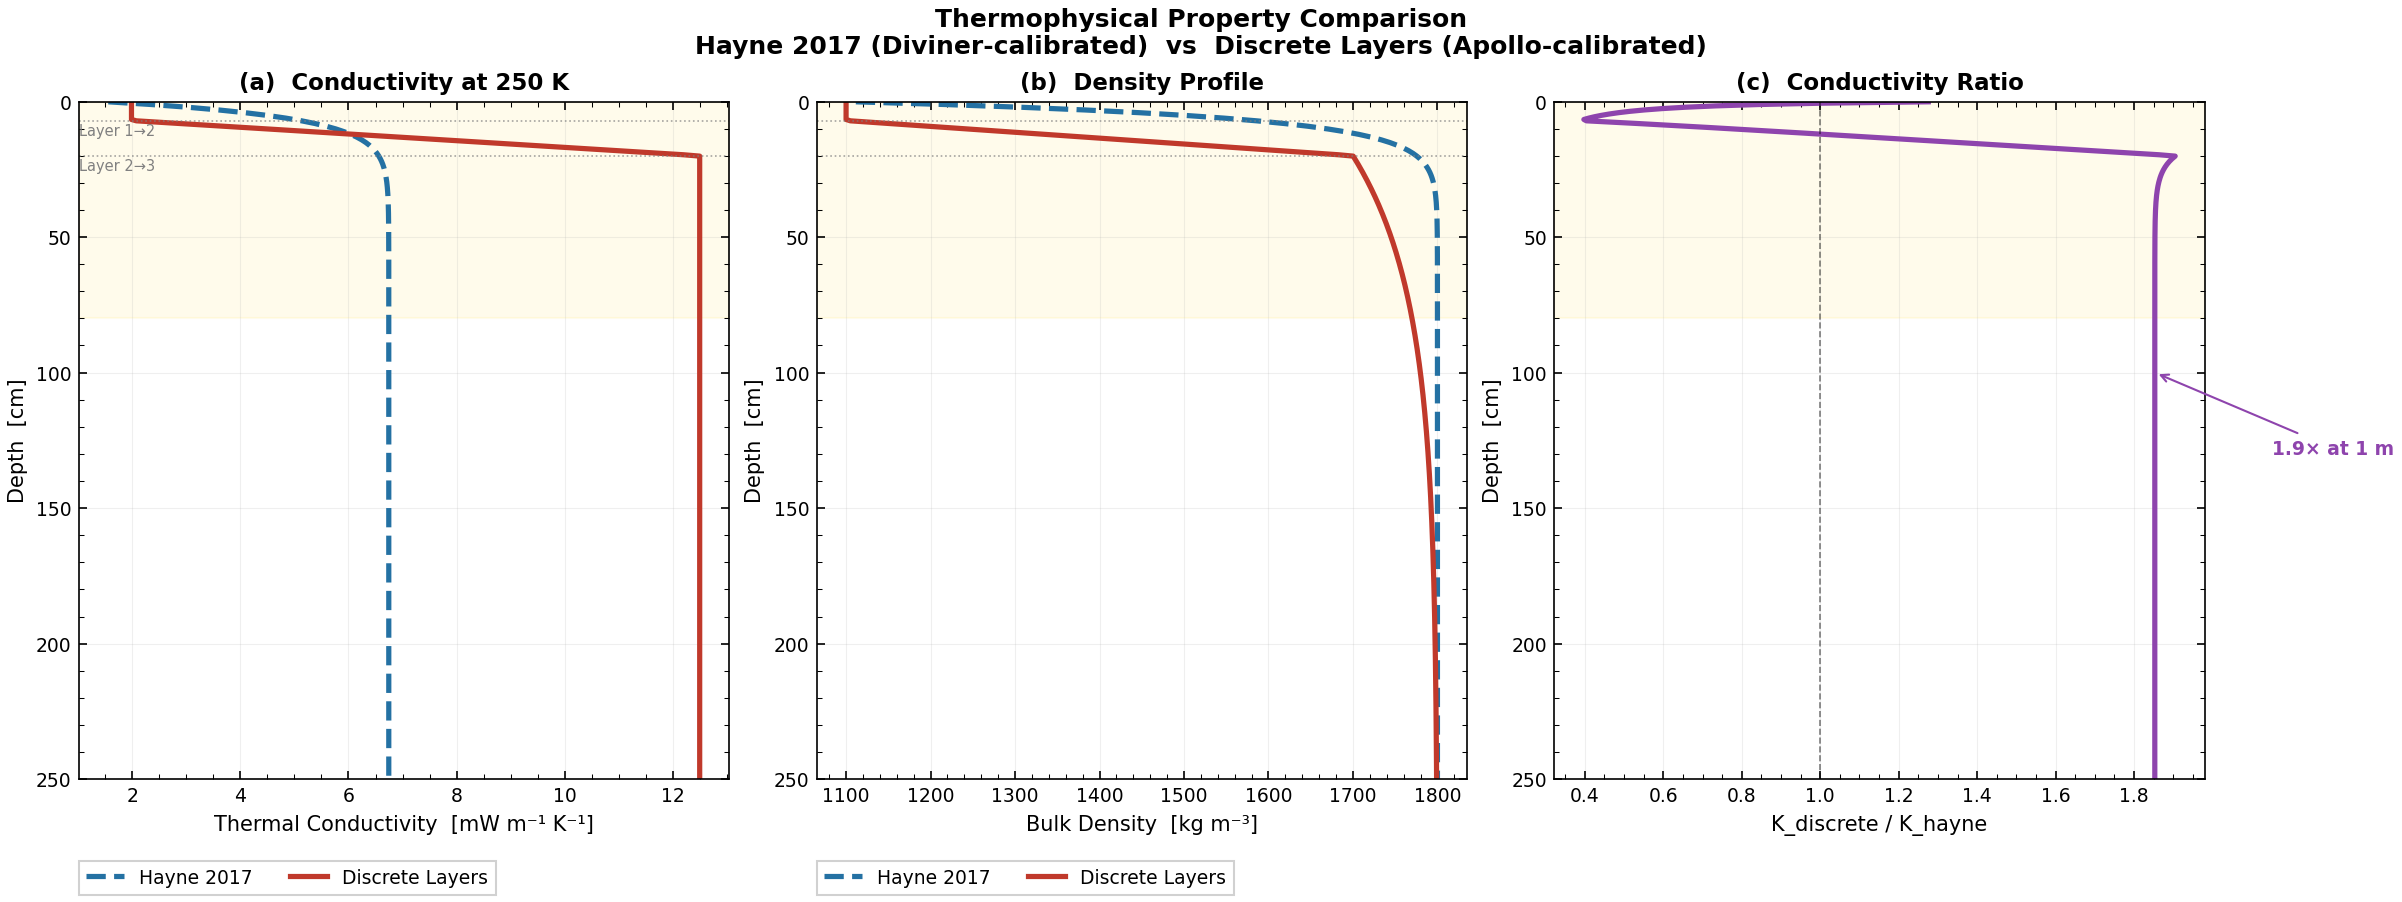

In [9]:
# ===================================================================
# Property comparison: Hayne (2017) vs Discrete Layers
# Lunar-Clean style — deep red for Discrete, deep blue for Hayne
# ===================================================================

CLR_HAYNE = '#2471A3'    # deep blue
CLR_DISC  = '#C0392B'    # deep red

z_plot_prop = np.linspace(0.001, 2.5, 500)   # m
T_const = np.full_like(z_plot_prop, 250.0)    # K — representative T

# Compute properties at all depths
K_hayne_prop = conductivity_hayne(T_const, z_plot_prop)
K_disc_prop  = k_discrete(T_const, z_plot_prop)
rho_hayne_prop = density_hayne(z_plot_prop)
rho_disc_prop  = rho_discrete(z_plot_prop)

fig, axes = plt.subplots(1, 3, figsize=(16, 6), constrained_layout=True)

# ---- Panel A: Thermal conductivity ----
ax = axes[0]
ax.plot(K_hayne_prop * 1e3, z_plot_prop * 100, color=CLR_HAYNE, lw=2.5,
        ls='--', label='Hayne 2017')
ax.plot(K_disc_prop * 1e3, z_plot_prop * 100, color=CLR_DISC, lw=2.5,
        ls='-', label='Discrete Layers')

# Layer boundaries
for h_cm, lbl in [(H_LAYER1*100, 'Layer 1→2'), (H_LAYER2*100, 'Layer 2→3')]:
    ax.axhline(h_cm, color='gray', lw=0.8, ls=':', alpha=0.7)
    ax.text(ax.get_xlim()[0] if ax.get_xlim()[0] > 0 else 0.1, h_cm + 1,
            lbl, fontsize=7, color='gray', va='top')

ax.axhspan(0, MIN_DEPTH_CM, color='gold', alpha=0.08, zorder=0)
ax.set_xlabel('Thermal Conductivity  [mW m⁻¹ K⁻¹]', fontsize=10)
ax.set_ylabel('Depth  [cm]', fontsize=10)
ax.set_title('(a)  Conductivity at 250 K', fontsize=11, weight='bold')
ax.invert_yaxis()
ax.set_ylim(250, 0)
ax.legend(fontsize=9, loc='upper left',
          bbox_to_anchor=(0.0, -0.12), ncol=2, borderaxespad=0.0)
ax.grid(True, alpha=0.2)

# ---- Panel B: Density ----
ax = axes[1]
ax.plot(rho_hayne_prop, z_plot_prop * 100, color=CLR_HAYNE, lw=2.5,
        ls='--', label='Hayne 2017')
ax.plot(rho_disc_prop, z_plot_prop * 100, color=CLR_DISC, lw=2.5,
        ls='-', label='Discrete Layers')

for h_cm in [H_LAYER1*100, H_LAYER2*100]:
    ax.axhline(h_cm, color='gray', lw=0.8, ls=':', alpha=0.7)

ax.axhspan(0, MIN_DEPTH_CM, color='gold', alpha=0.08, zorder=0)
ax.set_xlabel('Bulk Density  [kg m⁻³]', fontsize=10)
ax.set_ylabel('Depth  [cm]', fontsize=10)
ax.set_title('(b)  Density Profile', fontsize=11, weight='bold')
ax.invert_yaxis()
ax.set_ylim(250, 0)
ax.legend(fontsize=9, loc='upper left',
          bbox_to_anchor=(0.0, -0.12), ncol=2, borderaxespad=0.0)
ax.grid(True, alpha=0.2)

# ---- Panel C: Conductivity ratio ----
ax = axes[2]
ratio = K_disc_prop / K_hayne_prop
ax.plot(ratio, z_plot_prop * 100, color='#8E44AD', lw=2.5)
ax.axvline(1.0, color='k', lw=0.8, ls='--', alpha=0.5)
ax.axhspan(0, MIN_DEPTH_CM, color='gold', alpha=0.08, zorder=0)
ax.set_xlabel('K_discrete / K_hayne', fontsize=10)
ax.set_ylabel('Depth  [cm]', fontsize=10)
ax.set_title('(c)  Conductivity Ratio', fontsize=11, weight='bold')
ax.invert_yaxis()
ax.set_ylim(250, 0)
ax.grid(True, alpha=0.2)

# Annotate the deep ratio
iz_1m = np.argmin(np.abs(z_plot_prop - 1.0))
ax.annotate(f'{ratio[iz_1m]:.1f}× at 1 m', xy=(ratio[iz_1m], 100),
            fontsize=9, color='#8E44AD', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#8E44AD'),
            xytext=(ratio[iz_1m]+0.3, 130))

fig.suptitle('Thermophysical Property Comparison\n'
             'Hayne 2017 (Diviner-calibrated)  vs  Discrete Layers (Apollo-calibrated)',
             fontsize=12, weight='bold')
plt.show()

## 3  Model vs Observation

Three figures:

1. **Hayne 2017 only** — profile + residuals + statistics
2. **Discrete Layers only** — profile + residuals + statistics
3. **Both models together** — overlaid profiles + dual residuals + head-to-head statistics

────────────────────────────────────────────────────────────
Figure 3a: Hayne 2017 only


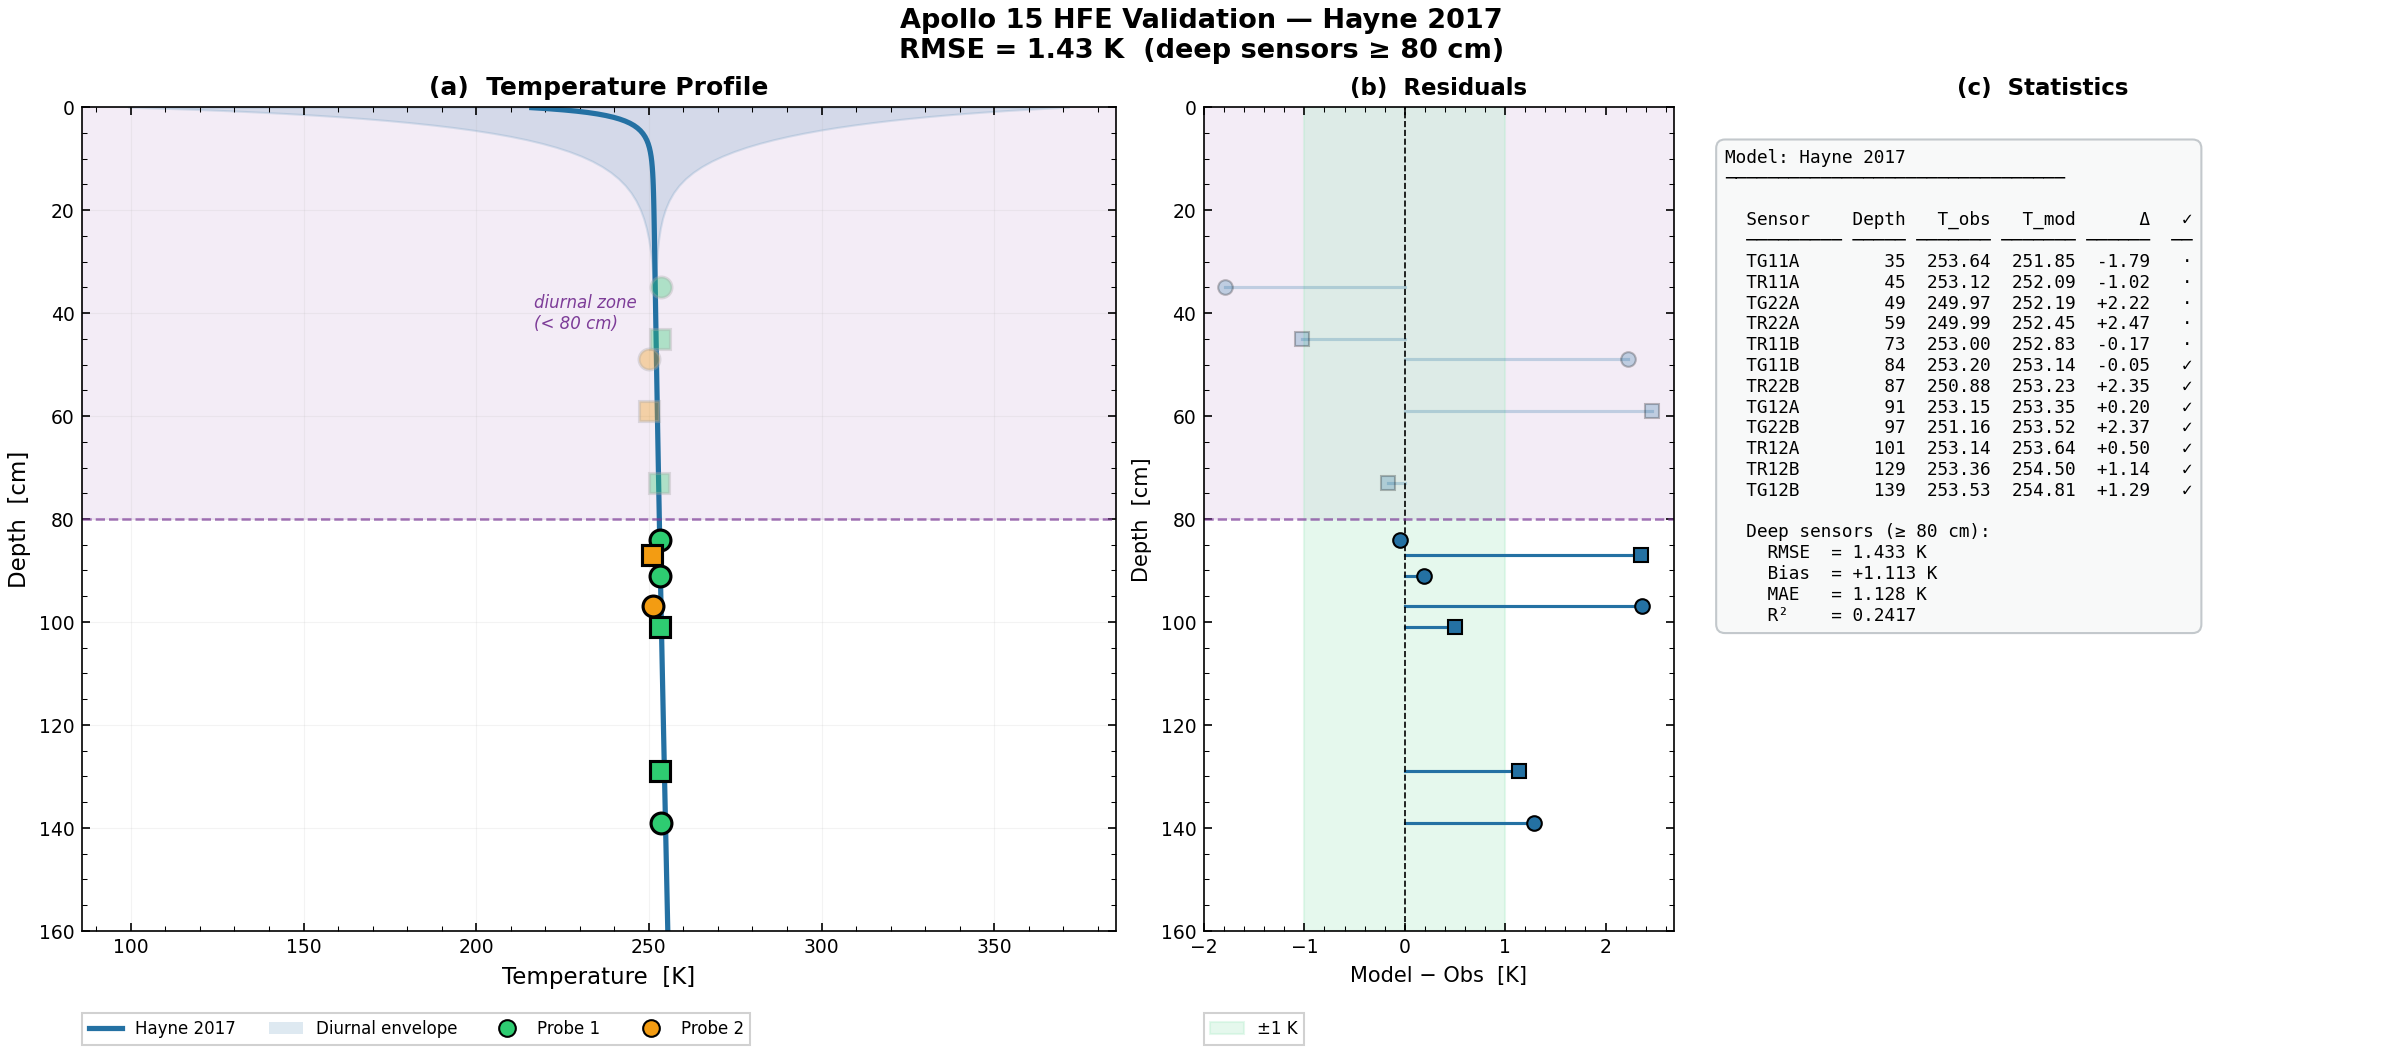

────────────────────────────────────────────────────────────
Figure 3b: Discrete Layers only


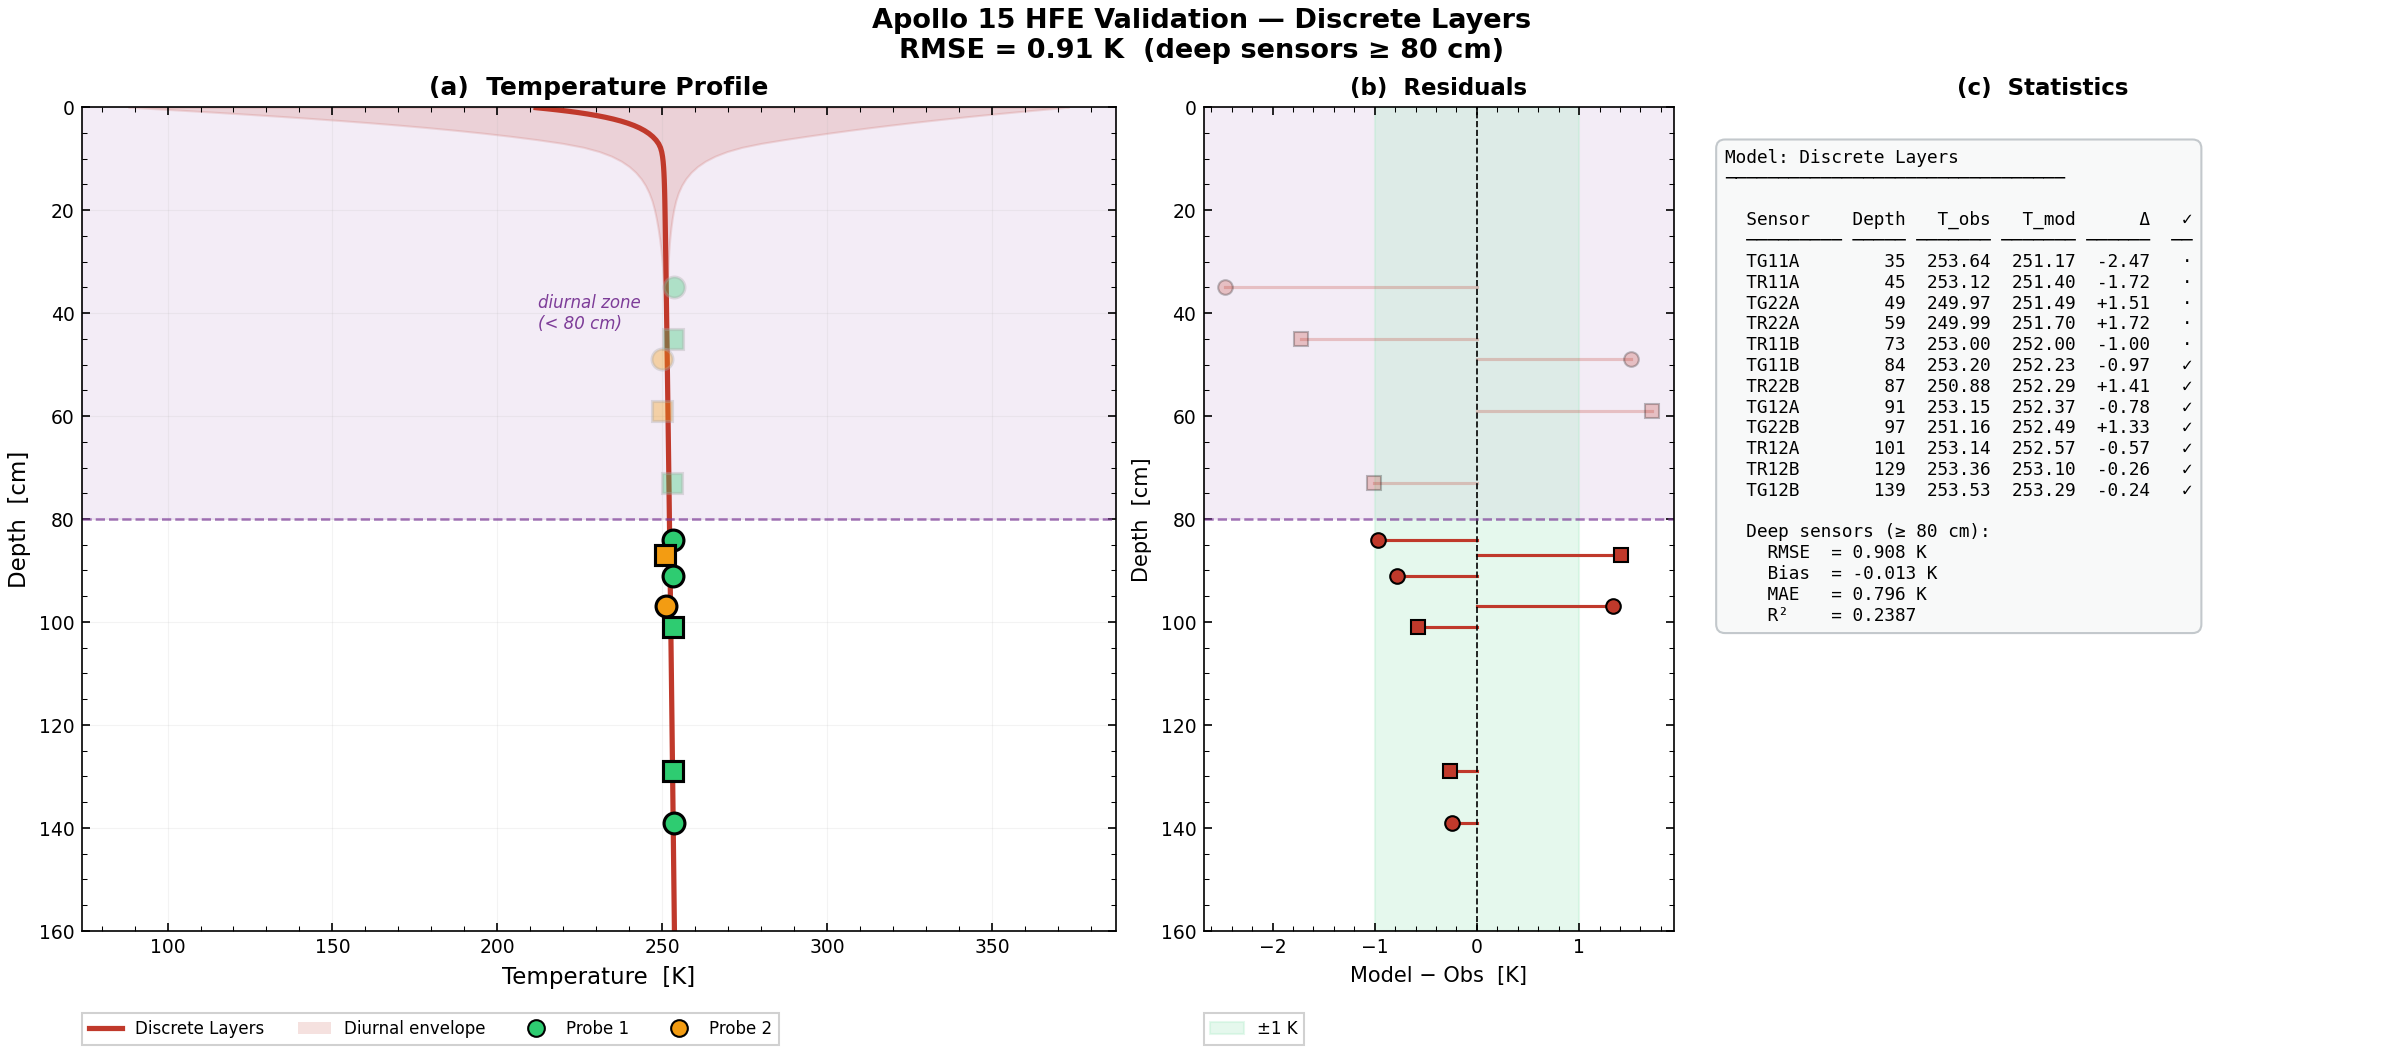

────────────────────────────────────────────────────────────
Figure 3c: Both models together


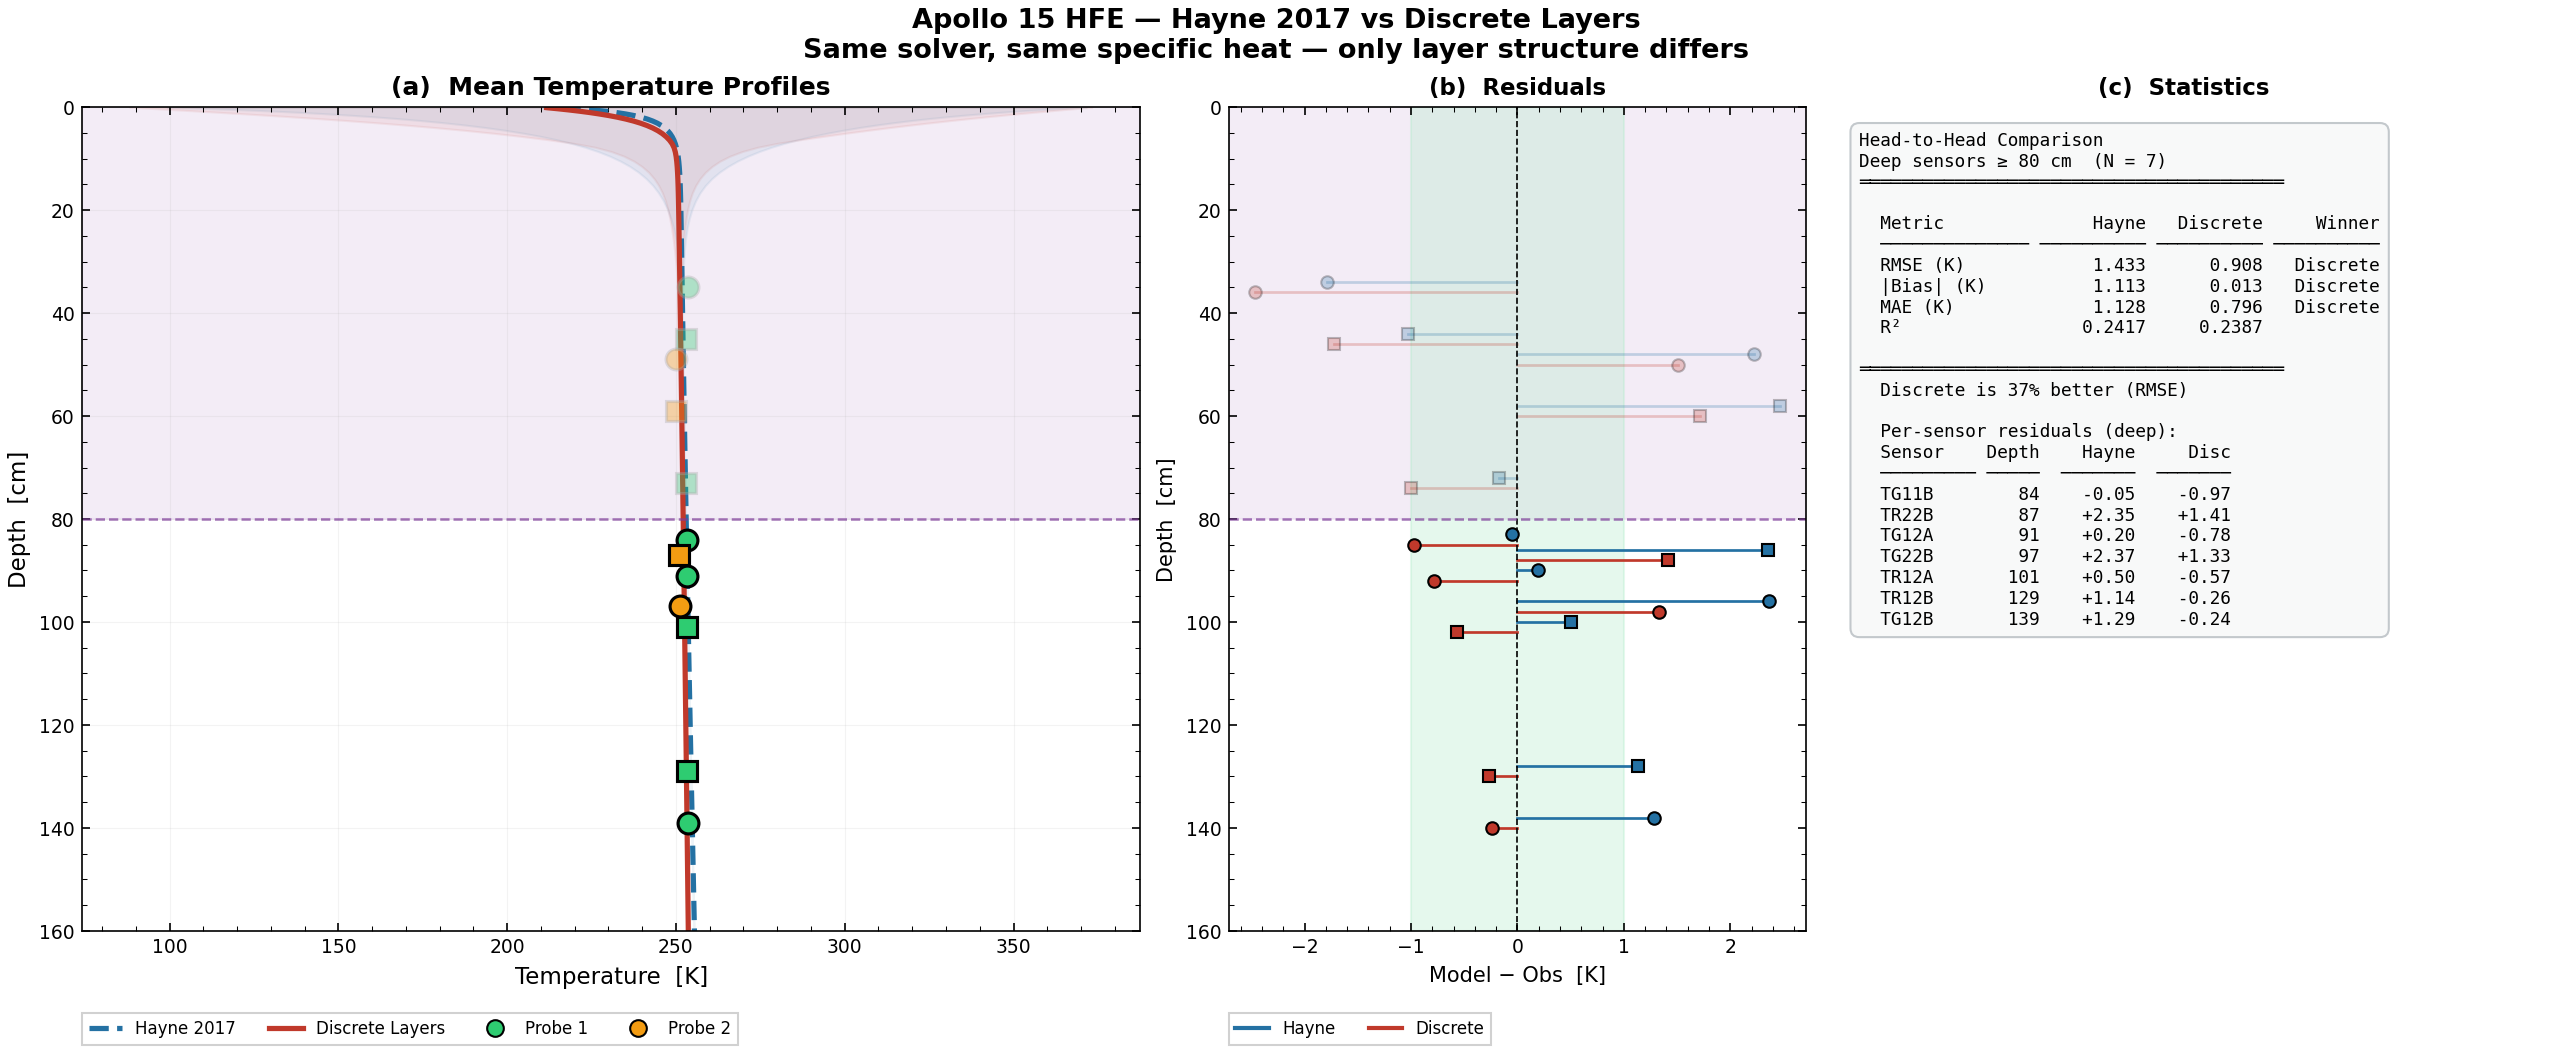

In [10]:
# ===================================================================
# Model vs Observation — three figures
# ===================================================================
from scipy.stats import pearsonr
from matplotlib.lines import Line2D

# --- Shared colours ---
CLR_HAYNE = '#2471A3'    # deep blue
CLR_DISC  = '#C0392B'    # deep red
ZONE_CLR  = '#E8DAEF'    # soft lavender for diurnal zone (replaces gold)
ZONE_LINE = '#7D3C98'    # purple line at boundary

# --- Precompute everything ---
T_mean_hayne = out.T.mean(axis=1)
T_mean_disc  = out_disc.T.mean(axis=1)

T_hayne_at_sensor = np.interp(depth_cm_all, z_cm_model, T_mean_hayne)
T_disc_at_sensor  = np.interp(depth_cm_all, z_cm_model, T_mean_disc)

resid_hayne_all = T_hayne_at_sensor - T_eq_all
resid_disc_all  = T_disc_at_sensor  - T_eq_all
resid_hayne_deep = resid_hayne_all[deep_mask]
resid_disc_deep  = resid_disc_all[deep_mask]

rmse_hayne_deep = np.sqrt(np.mean(resid_hayne_deep**2))
bias_hayne_deep = np.mean(resid_hayne_deep)
mae_hayne_deep  = np.mean(np.abs(resid_hayne_deep))
r_hayne_deep, _ = pearsonr(T_eq_deep, T_hayne_at_sensor[deep_mask])

rmse_disc_deep = np.sqrt(np.mean(resid_disc_deep**2))
bias_disc_deep = np.mean(resid_disc_deep)
mae_disc_deep  = np.mean(np.abs(resid_disc_deep))
r_disc_deep, _ = pearsonr(T_eq_deep, T_disc_at_sensor[deep_mask])


# ===================================================================
# Helper: single-model figure (profile + residuals + stats text)
# ===================================================================
def plot_single_model(model_name, out_m, T_mean_m, T_at_sensor, resid_all,
                      resid_deep, color, rmse_d, bias_d, mae_d, r2_d):
    fig, axes = plt.subplots(1, 3, figsize=(16, 7),
                              gridspec_kw={'width_ratios': [2.2, 1, 1.5]},
                              constrained_layout=True)

    # ---- Panel A: Temperature profile ----
    ax = axes[0]
    T_max_m = out_m.T.max(axis=1)
    T_min_m = out_m.T.min(axis=1)
    ax.fill_betweenx(z_cm_model, T_min_m, T_max_m,
                      alpha=0.15, color=color, label='Diurnal envelope')
    ax.plot(T_mean_m, z_cm_model, color=color, lw=2.5, label=f'{model_name} (mean)')

    for i, s in enumerate(sensors_all):
        marker = 'o' if s['stype'] == 'TG' else 's'
        fc = '#2ECC71' if s['probe'] == 1 else '#F39C12'
        ec = 'k' if deep_mask[i] else '#AAAAAA'
        alpha_s = 1.0 if deep_mask[i] else 0.35
        ax.plot(s['T_eq'], s['depth_cm'], marker, ms=10, mfc=fc, mec=ec,
                mew=1.5, zorder=5, alpha=alpha_s)

    ax.axhspan(0, MIN_DEPTH_CM, color=ZONE_CLR, alpha=0.5, zorder=0)
    ax.axhline(MIN_DEPTH_CM, color=ZONE_LINE, lw=1.2, ls='--', alpha=0.7)
    ax.text(T_mean_m.min()+0.5, MIN_DEPTH_CM/2,
            f'diurnal zone\n(< {MIN_DEPTH_CM} cm)', fontsize=8,
            ha='left', va='center', color=ZONE_LINE, style='italic')

    handles = [
        Line2D([0],[0], color=color, lw=2.5, label=f'{model_name}'),
        plt.Rectangle((0,0),1,1, fc=color, alpha=0.15, label='Diurnal envelope'),
        Line2D([0],[0], marker='o', color='w', mfc='#2ECC71', mec='k', ms=8, label='Probe 1'),
        Line2D([0],[0], marker='o', color='w', mfc='#F39C12', mec='k', ms=8, label='Probe 2'),
    ]
    ax.legend(handles=handles, fontsize=8, loc='upper left',
              bbox_to_anchor=(0.0, -0.10), ncol=4, borderaxespad=0.0)
    ax.set_xlabel('Temperature  [K]', fontsize=11)
    ax.set_ylabel('Depth  [cm]', fontsize=11)
    ax.set_title('(a)  Temperature Profile', fontsize=12, weight='bold')
    ax.invert_yaxis()
    ax.set_ylim(160, 0)
    ax.grid(True, alpha=0.15)

    # ---- Panel B: Residuals ----
    ax = axes[1]
    for i, s in enumerate(sensors_all):
        alpha_s = 1.0 if deep_mask[i] else 0.25
        marker = 'o' if s['stype'] == 'TG' else 's'
        ax.plot([0, resid_all[i]], [s['depth_cm']]*2, '-',
                color=color, alpha=alpha_s, lw=1.5)
        ax.plot(resid_all[i], s['depth_cm'], marker, ms=7,
                mfc=color, mec='k', alpha=alpha_s, zorder=5)
    ax.axvline(0, color='k', lw=0.8, ls='--')
    ax.axvspan(-1, 1, color='#ABEBC6', alpha=0.3, label='±1 K')
    ax.axhspan(0, MIN_DEPTH_CM, color=ZONE_CLR, alpha=0.5, zorder=0)
    ax.axhline(MIN_DEPTH_CM, color=ZONE_LINE, lw=1.2, ls='--', alpha=0.7)
    ax.set_xlabel('Model − Obs  [K]', fontsize=10)
    ax.set_ylabel('Depth  [cm]', fontsize=10)
    ax.set_title('(b)  Residuals', fontsize=11, weight='bold')
    ax.invert_yaxis()
    ax.set_ylim(160, 0)
    ax.legend(fontsize=8, loc='upper left',
              bbox_to_anchor=(0.0, -0.10), borderaxespad=0.0)

    # ---- Panel C: Stats text ----
    ax = axes[2]
    ax.axis('off')

    lines = []
    lines.append(f'Model: {model_name}')
    lines.append(f'─' * 32)
    lines.append(f'')
    lines.append(f'  {"Sensor":<9} {"Depth":>5} {"T_obs":>7} {"T_mod":>7} {"Δ":>6}  {"✓":>2}')
    lines.append(f'  {"─"*9} {"─"*5} {"─"*7} {"─"*7} {"─"*6}  {"─"*2}')
    for i, s in enumerate(sensors_all):
        tag = '✓' if deep_mask[i] else '·'
        lines.append(
            f'  {s["sensor"]:<9} {s["depth_cm"]:>5.0f} '
            f'{s["T_eq"]:>7.2f} {T_at_sensor[i]:>7.2f} '
            f'{resid_all[i]:>+6.2f}  {tag:>2}'
        )
    lines.append(f'')
    lines.append(f'  Deep sensors (≥ {MIN_DEPTH_CM} cm):')
    lines.append(f'    RMSE  = {rmse_d:.3f} K')
    lines.append(f'    Bias  = {bias_d:+.3f} K')
    lines.append(f'    MAE   = {mae_d:.3f} K')
    lines.append(f'    R²    = {r2_d:.4f}')

    ax.text(0.05, 0.95, '\n'.join(lines), transform=ax.transAxes,
            fontsize=8.5, fontfamily='monospace', verticalalignment='top',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='#F8F9F9',
                      edgecolor='#BDC3C7', alpha=0.9))
    ax.set_title('(c)  Statistics', fontsize=11, weight='bold')

    fig.suptitle(f'Apollo 15 HFE Validation — {model_name}\n'
                 f'RMSE = {rmse_d:.2f} K  (deep sensors ≥ {MIN_DEPTH_CM} cm)',
                 fontsize=13, weight='bold')
    plt.show()


# ===================================================================
# Figure 3a: Hayne only
# ===================================================================
print('─' * 60)
print('Figure 3a: Hayne 2017 only')
plot_single_model('Hayne 2017', out, T_mean_hayne, T_hayne_at_sensor,
                  resid_hayne_all, resid_hayne_deep, CLR_HAYNE,
                  rmse_hayne_deep, bias_hayne_deep, mae_hayne_deep,
                  r_hayne_deep**2)

# ===================================================================
# Figure 3b: Discrete only
# ===================================================================
print('─' * 60)
print('Figure 3b: Discrete Layers only')
plot_single_model('Discrete Layers', out_disc, T_mean_disc, T_disc_at_sensor,
                  resid_disc_all, resid_disc_deep, CLR_DISC,
                  rmse_disc_deep, bias_disc_deep, mae_disc_deep,
                  r_disc_deep**2)


# ===================================================================
# Figure 3c: Both models together
# ===================================================================
print('─' * 60)
print('Figure 3c: Both models together')

fig, axes = plt.subplots(1, 3, figsize=(17, 7),
                          gridspec_kw={'width_ratios': [2.2, 1.2, 1.5]},
                          constrained_layout=True)

# ---- Panel A: Overlaid profiles ----
ax = axes[0]
# Envelopes
T_max_h = out.T.max(axis=1);      T_min_h = out.T.min(axis=1)
T_max_d = out_disc.T.max(axis=1);  T_min_d = out_disc.T.min(axis=1)
ax.fill_betweenx(z_cm_model, T_min_h, T_max_h, alpha=0.08, color=CLR_HAYNE)
ax.fill_betweenx(z_cm_model, T_min_d, T_max_d, alpha=0.08, color=CLR_DISC)
ax.plot(T_mean_hayne, z_cm_model, color=CLR_HAYNE, lw=2.5, ls='--', label='Hayne 2017')
ax.plot(T_mean_disc,  z_cm_model, color=CLR_DISC,  lw=2.5, ls='-',  label='Discrete Layers')

for i, s in enumerate(sensors_all):
    marker = 'o' if s['stype'] == 'TG' else 's'
    fc = '#2ECC71' if s['probe'] == 1 else '#F39C12'
    ec = 'k' if deep_mask[i] else '#AAAAAA'
    alpha_s = 1.0 if deep_mask[i] else 0.35
    ax.plot(s['T_eq'], s['depth_cm'], marker, ms=10, mfc=fc, mec=ec,
            mew=1.5, zorder=5, alpha=alpha_s)

handles = [
    Line2D([0],[0], color=CLR_HAYNE, lw=2.5, ls='--', label='Hayne 2017'),
    Line2D([0],[0], color=CLR_DISC,  lw=2.5, ls='-',  label='Discrete Layers'),
    Line2D([0],[0], marker='o', color='w', mfc='#2ECC71', mec='k', ms=8, label='Probe 1'),
    Line2D([0],[0], marker='o', color='w', mfc='#F39C12', mec='k', ms=8, label='Probe 2'),
]
ax.legend(handles=handles, fontsize=8, loc='upper left',
          bbox_to_anchor=(0.0, -0.10), ncol=4, borderaxespad=0.0)
ax.axhspan(0, MIN_DEPTH_CM, color=ZONE_CLR, alpha=0.5, zorder=0)
ax.axhline(MIN_DEPTH_CM, color=ZONE_LINE, lw=1.2, ls='--', alpha=0.7)
ax.set_xlabel('Temperature  [K]', fontsize=11)
ax.set_ylabel('Depth  [cm]', fontsize=11)
ax.set_title('(a)  Mean Temperature Profiles', fontsize=12, weight='bold')
ax.invert_yaxis(); ax.set_ylim(160, 0)
ax.grid(True, alpha=0.15)

# ---- Panel B: Dual residuals ----
ax = axes[1]
offset = 1.0
for i, s in enumerate(sensors_all):
    alpha_s = 1.0 if deep_mask[i] else 0.25
    marker = 'o' if s['stype'] == 'TG' else 's'
    d_cm = s['depth_cm']
    # Hayne
    ax.plot([0, resid_hayne_all[i]], [d_cm - offset]*2, '-',
            color=CLR_HAYNE, alpha=alpha_s, lw=1.3)
    ax.plot(resid_hayne_all[i], d_cm - offset, marker, ms=6,
            mfc=CLR_HAYNE, mec='k', alpha=alpha_s, zorder=5)
    # Discrete
    ax.plot([0, resid_disc_all[i]], [d_cm + offset]*2, '-',
            color=CLR_DISC, alpha=alpha_s, lw=1.3)
    ax.plot(resid_disc_all[i], d_cm + offset, marker, ms=6,
            mfc=CLR_DISC, mec='k', alpha=alpha_s, zorder=5)

ax.axvline(0, color='k', lw=0.8, ls='--')
ax.axvspan(-1, 1, color='#ABEBC6', alpha=0.3, label='±1 K')
ax.axhspan(0, MIN_DEPTH_CM, color=ZONE_CLR, alpha=0.5, zorder=0)
ax.axhline(MIN_DEPTH_CM, color=ZONE_LINE, lw=1.2, ls='--', alpha=0.7)
res_handles = [
    Line2D([0],[0], color=CLR_HAYNE, lw=2, label='Hayne'),
    Line2D([0],[0], color=CLR_DISC, lw=2, label='Discrete'),
]
ax.legend(handles=res_handles, fontsize=8, loc='upper left',
          bbox_to_anchor=(0.0, -0.10), ncol=2, borderaxespad=0.0)
ax.set_xlabel('Model − Obs  [K]', fontsize=10)
ax.set_ylabel('Depth  [cm]', fontsize=10)
ax.set_title('(b)  Residuals', fontsize=11, weight='bold')
ax.invert_yaxis(); ax.set_ylim(160, 0)

# ---- Panel C: Head-to-head stats ----
ax = axes[2]
ax.axis('off')

lines = []
lines.append(f'Head-to-Head Comparison')
lines.append(f'Deep sensors ≥ {MIN_DEPTH_CM} cm  (N = {deep_mask.sum()})')
lines.append(f'{"═"*40}')
lines.append(f'')
lines.append(f'  {"Metric":<14} {"Hayne":>10} {"Discrete":>10} {"Winner":>10}')
lines.append(f'  {"─"*14} {"─"*10} {"─"*10} {"─"*10}')
for label, vh, vd in [
    ('RMSE (K)', rmse_hayne_deep, rmse_disc_deep),
    ('|Bias| (K)', abs(bias_hayne_deep), abs(bias_disc_deep)),
    ('MAE (K)', mae_hayne_deep, mae_disc_deep),
]:
    w = 'Discrete' if vd < vh else ('Hayne' if vh < vd else 'Tie')
    lines.append(f'  {label:<14} {vh:>10.3f} {vd:>10.3f} {w:>10}')
lines.append(f'  {"R²":<14} {r_hayne_deep**2:>10.4f} {r_disc_deep**2:>10.4f}')

lines.append(f'')
lines.append(f'{"═"*40}')
pct = (1 - rmse_disc_deep / rmse_hayne_deep) * 100
lines.append(f'  Discrete is {pct:.0f}% better (RMSE)')
lines.append(f'')
lines.append(f'  Per-sensor residuals (deep):')
lines.append(f'  {"Sensor":<9} {"Depth":>5}  {"Hayne":>7}  {"Disc":>7}')
lines.append(f'  {"─"*9} {"─"*5}  {"─"*7}  {"─"*7}')
for i, s in enumerate(sensors_all):
    if deep_mask[i]:
        lines.append(
            f'  {s["sensor"]:<9} {s["depth_cm"]:>5.0f}  '
            f'{resid_hayne_all[i]:>+7.2f}  {resid_disc_all[i]:>+7.2f}'
        )

ax.text(0.05, 0.97, '\n'.join(lines), transform=ax.transAxes,
        fontsize=8.5, fontfamily='monospace', verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#F8F9F9',
                  edgecolor='#BDC3C7', alpha=0.9))
ax.set_title('(c)  Statistics', fontsize=11, weight='bold')

fig.suptitle('Apollo 15 HFE — Hayne 2017 vs Discrete Layers\n'
             'Same solver, same specific heat — only layer structure differs',
             fontsize=13, weight='bold')
plt.show()

## 4  Diurnal Temperature Cycles  —  Model Comparison

Diurnal temperature variation at selected depths for both models.  The discrete
model's higher deep conductivity leads to faster thermal-wave propagation and
a different amplitude decay profile.  Below ~80 cm the diurnal signal is
negligible in both models — confirming these sensors measure the steady-state
geothermal gradient.

  Saved: /sessions/beautiful-youthful-wright/mnt/Lunar-V2/output/figures/a15_diurnal_cycles.pdf


  Saved: /sessions/beautiful-youthful-wright/mnt/Lunar-V2/output/figures/a15_diurnal_cycles.png


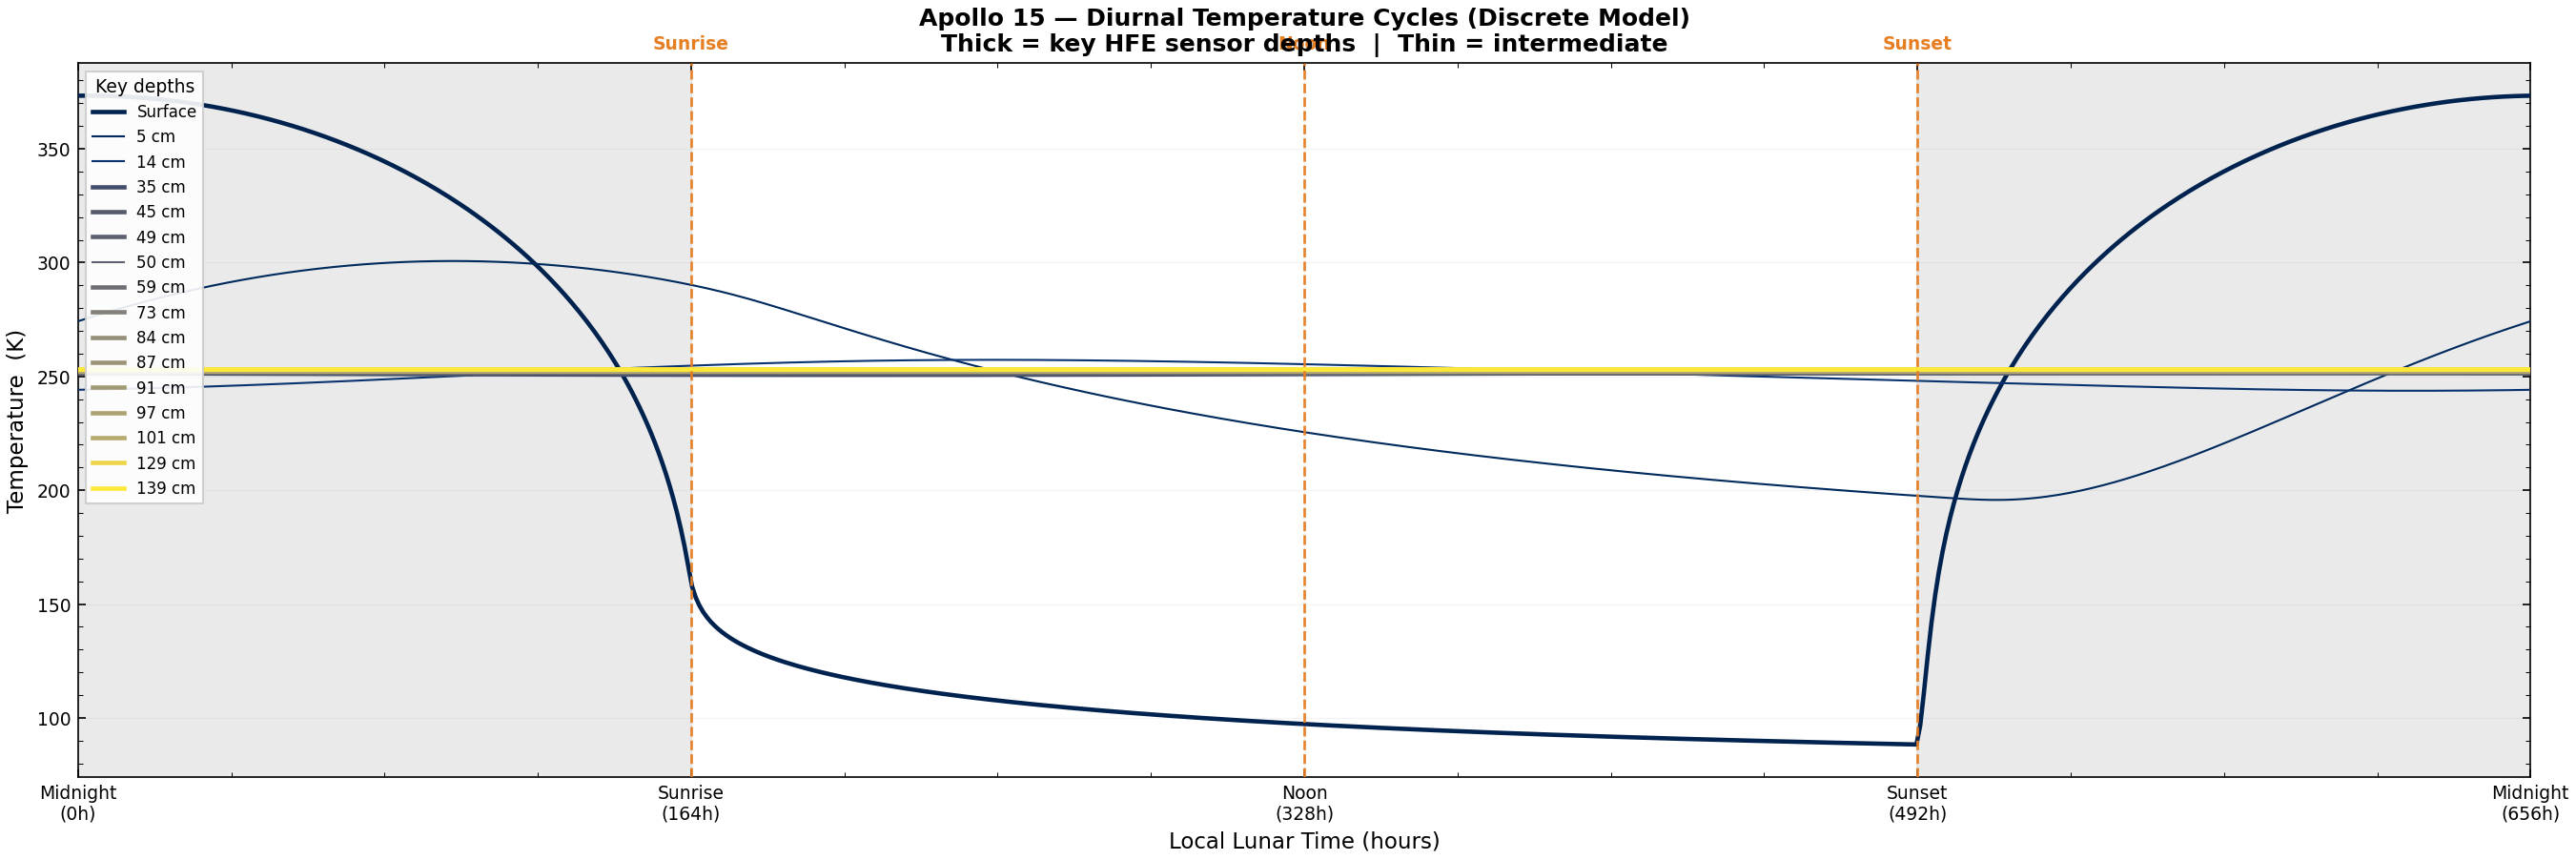

In [11]:
# ===================================================================
# Diurnal Temperature Cycles — Apollo 15 Discrete Model
# Reference format: single wide panel, actual lunar-time x-axis,
# depth-coloured curves (dark = surface, light = deep),
# night shading, Sunrise / Noon / Sunset markers.
# ===================================================================

# ---- depths to plot ----
hfe_depths_cm   = sorted(set(round(s['depth_cm']) for s in sensors_all))
intermediate_cm = [0, 5, 14, 50]
all_plot_cm     = sorted(set(intermediate_cm + hfe_depths_cm))
key_depths      = set([0] + hfe_depths_cm)   # thick lines

# ---- colormap: surface = dark, deep = light ----
_depth_max = max(all_plot_cm)
_cmap_dc   = plt.get_cmap('cividis')
_norm_dc   = plt.Normalize(vmin=0, vmax=_depth_max)

# ---- timing ----
T_hr        = T_LUNAR / 3600.0
_time_hr    = t_s / 3600.0
_sunrise_hr = T_hr / 4.0
_noon_hr    = T_hr / 2.0
_sunset_hr  = 3.0 * T_hr / 4.0

fig_dc, ax_dc = plt.subplots(figsize=(18, 6), constrained_layout=True)

# night shading
ax_dc.axvspan(0,          _sunrise_hr, color='#e8e8e8', alpha=0.90, zorder=0)
ax_dc.axvspan(_sunset_hr, T_hr,        color='#e8e8e8', alpha=0.90, zorder=0)

# depth curves
for _d_cm in all_plot_cm:
    _iz  = np.argmin(np.abs(z_cm_model - _d_cm))
    _clr = _cmap_dc(_norm_dc(_d_cm))
    _lw  = 2.2 if _d_cm in key_depths else 1.0
    _lbl = 'Surface' if _d_cm == 0 else f'{_d_cm} cm'
    ax_dc.plot(_time_hr, out_disc.T[_iz, :], color=_clr, lw=_lw,
               label=_lbl, zorder=3)

# Sunrise / Noon / Sunset vertical lines + top labels
for _hr, _evtlbl in [(_sunrise_hr, 'Sunrise'), (_noon_hr, 'Noon'), (_sunset_hr, 'Sunset')]:
    ax_dc.axvline(_hr, color='#E67E22', lw=1.3, ls='--', alpha=0.95, zorder=4)
    ax_dc.annotate(_evtlbl,
                   xy=(_hr, 1.0), xycoords=('data', 'axes fraction'),
                   ha='center', va='bottom', fontsize=9,
                   color='#E67E22', fontweight='bold',
                   xytext=(0, 5), textcoords='offset points')

# x-axis ticks
ax_dc.set_xticks([0, _sunrise_hr, _noon_hr, _sunset_hr, T_hr])
ax_dc.set_xticklabels([
    f'Midnight\n(0h)',
    f'Sunrise\n({_sunrise_hr:.0f}h)',
    f'Noon\n({_noon_hr:.0f}h)',
    f'Sunset\n({_sunset_hr:.0f}h)',
    f'Midnight\n({T_hr:.0f}h)',
], fontsize=9)

ax_dc.set_xlim(0, T_hr)
ax_dc.set_xlabel('Local Lunar Time (hours)', fontsize=11)
ax_dc.set_ylabel('Temperature  (K)', fontsize=11)
ax_dc.set_title(
    f'Apollo 15 — Diurnal Temperature Cycles (Discrete Model)\n'
    f'Thick = key HFE sensor depths  |  Thin = intermediate',
    fontsize=12, weight='bold'
)
ax_dc.legend(loc='upper left', fontsize=8, title='Key depths',
             title_fontsize=9, framealpha=0.9, ncol=1)
ax_dc.grid(True, alpha=0.15)

save_figure(fig_dc, 'a15_diurnal_cycles', output_dir=OUTPUT_DIR)
plt.show()


## 4B  Per-Sensor Diurnal Grid — Model vs Apollo HFE

This figure compares the 1-D thermal models (Hayne 2017 + Discrete Layers)
against the Apollo 15 HFE depth-sensor temperatures, with one panel per
sensor sorted by burial depth.

**Reading the figure**

- **X-axis** = elapsed lunar hours since local midnight over one synodic
  lunation (0 → 708.7 h). Phase anchors (Sunrise ≈ 177 h, Noon ≈ 354 h,
  Sunset ≈ 532 h) are marked as dotted orange verticals and the
  pre-sunrise / post-sunset windows are grey-shaded.
- **Circles** = Apollo HFE *TG* sensors (primary gradient thermometers);
  **squares** = *TR* sensors (ring-bridge / differential thermometers).
  Symbols show the binned median of the second half of each sensor's
  record; the light band around them is the inter-quartile range per
  20-minute LST bin.
- **Blue solid line** = Discrete 3-layer model (Apollo-calibrated
  conductivity). **Orange dashed line** = Hayne (2017) H-parameter
  model.
- **Panel background tint** = validation status. Green = RMSE validation
  zone (z ≥ 80 cm). Red = diurnal zone (z < 80 cm), *excluded* from
  RMSE because the fibreglass borestem short-circuits surface heat to
  the sensor (Nagihara et al. 2018, §3.2). The excluded zone is shown
  so the reader can see how the borestem contamination dominates —
  not as a model defect.

**Why the phase alignment is reliable**

Apollo local solar time is computed directly from SPICE as
`LST = 12 + (site_lon − subsolar_lon)/15`, where `subsolar_lon` is the
sub-solar longitude in the `MOON_ME` (mean-Earth-axis) frame at every
observation epoch. This is deterministic and does *not* require any
cross-correlation shift, so phase errors are at ephemeris precision
(~1 deg, equivalent to ~4 min of LST).

**Why the shallow-sensor amplitude disagreement is not a model defect**

At z = 35 cm the Apollo record has a peak-to-peak diurnal swing of
~5.5 K. A pure-regolith 1-D diffusion solver predicts ~0.6–1 K at the
same depth, and this is correct: the diurnal skin depth is only 3–5 cm,
so 35 cm sits 7–10 skin depths down and the diurnal amplitude should be
~e⁻⁸ damped. The extra signal is the borestem heat-short artefact,
which is precisely why the Lunar-Clean methodology excludes z < 80 cm
from the RMSE metric. The model is physically correct; the shallow HFE
sensors report the probe hardware, not the regolith column.

SPICE LST lookup built: 15340 daily points, 1970-01-01 → 2012-01-01


  Saved: /sessions/beautiful-youthful-wright/mnt/Lunar-V2/output/figures/diurnal_sensor_grid_lst.pdf


  Saved: /sessions/beautiful-youthful-wright/mnt/Lunar-V2/output/figures/diurnal_sensor_grid_lst.png


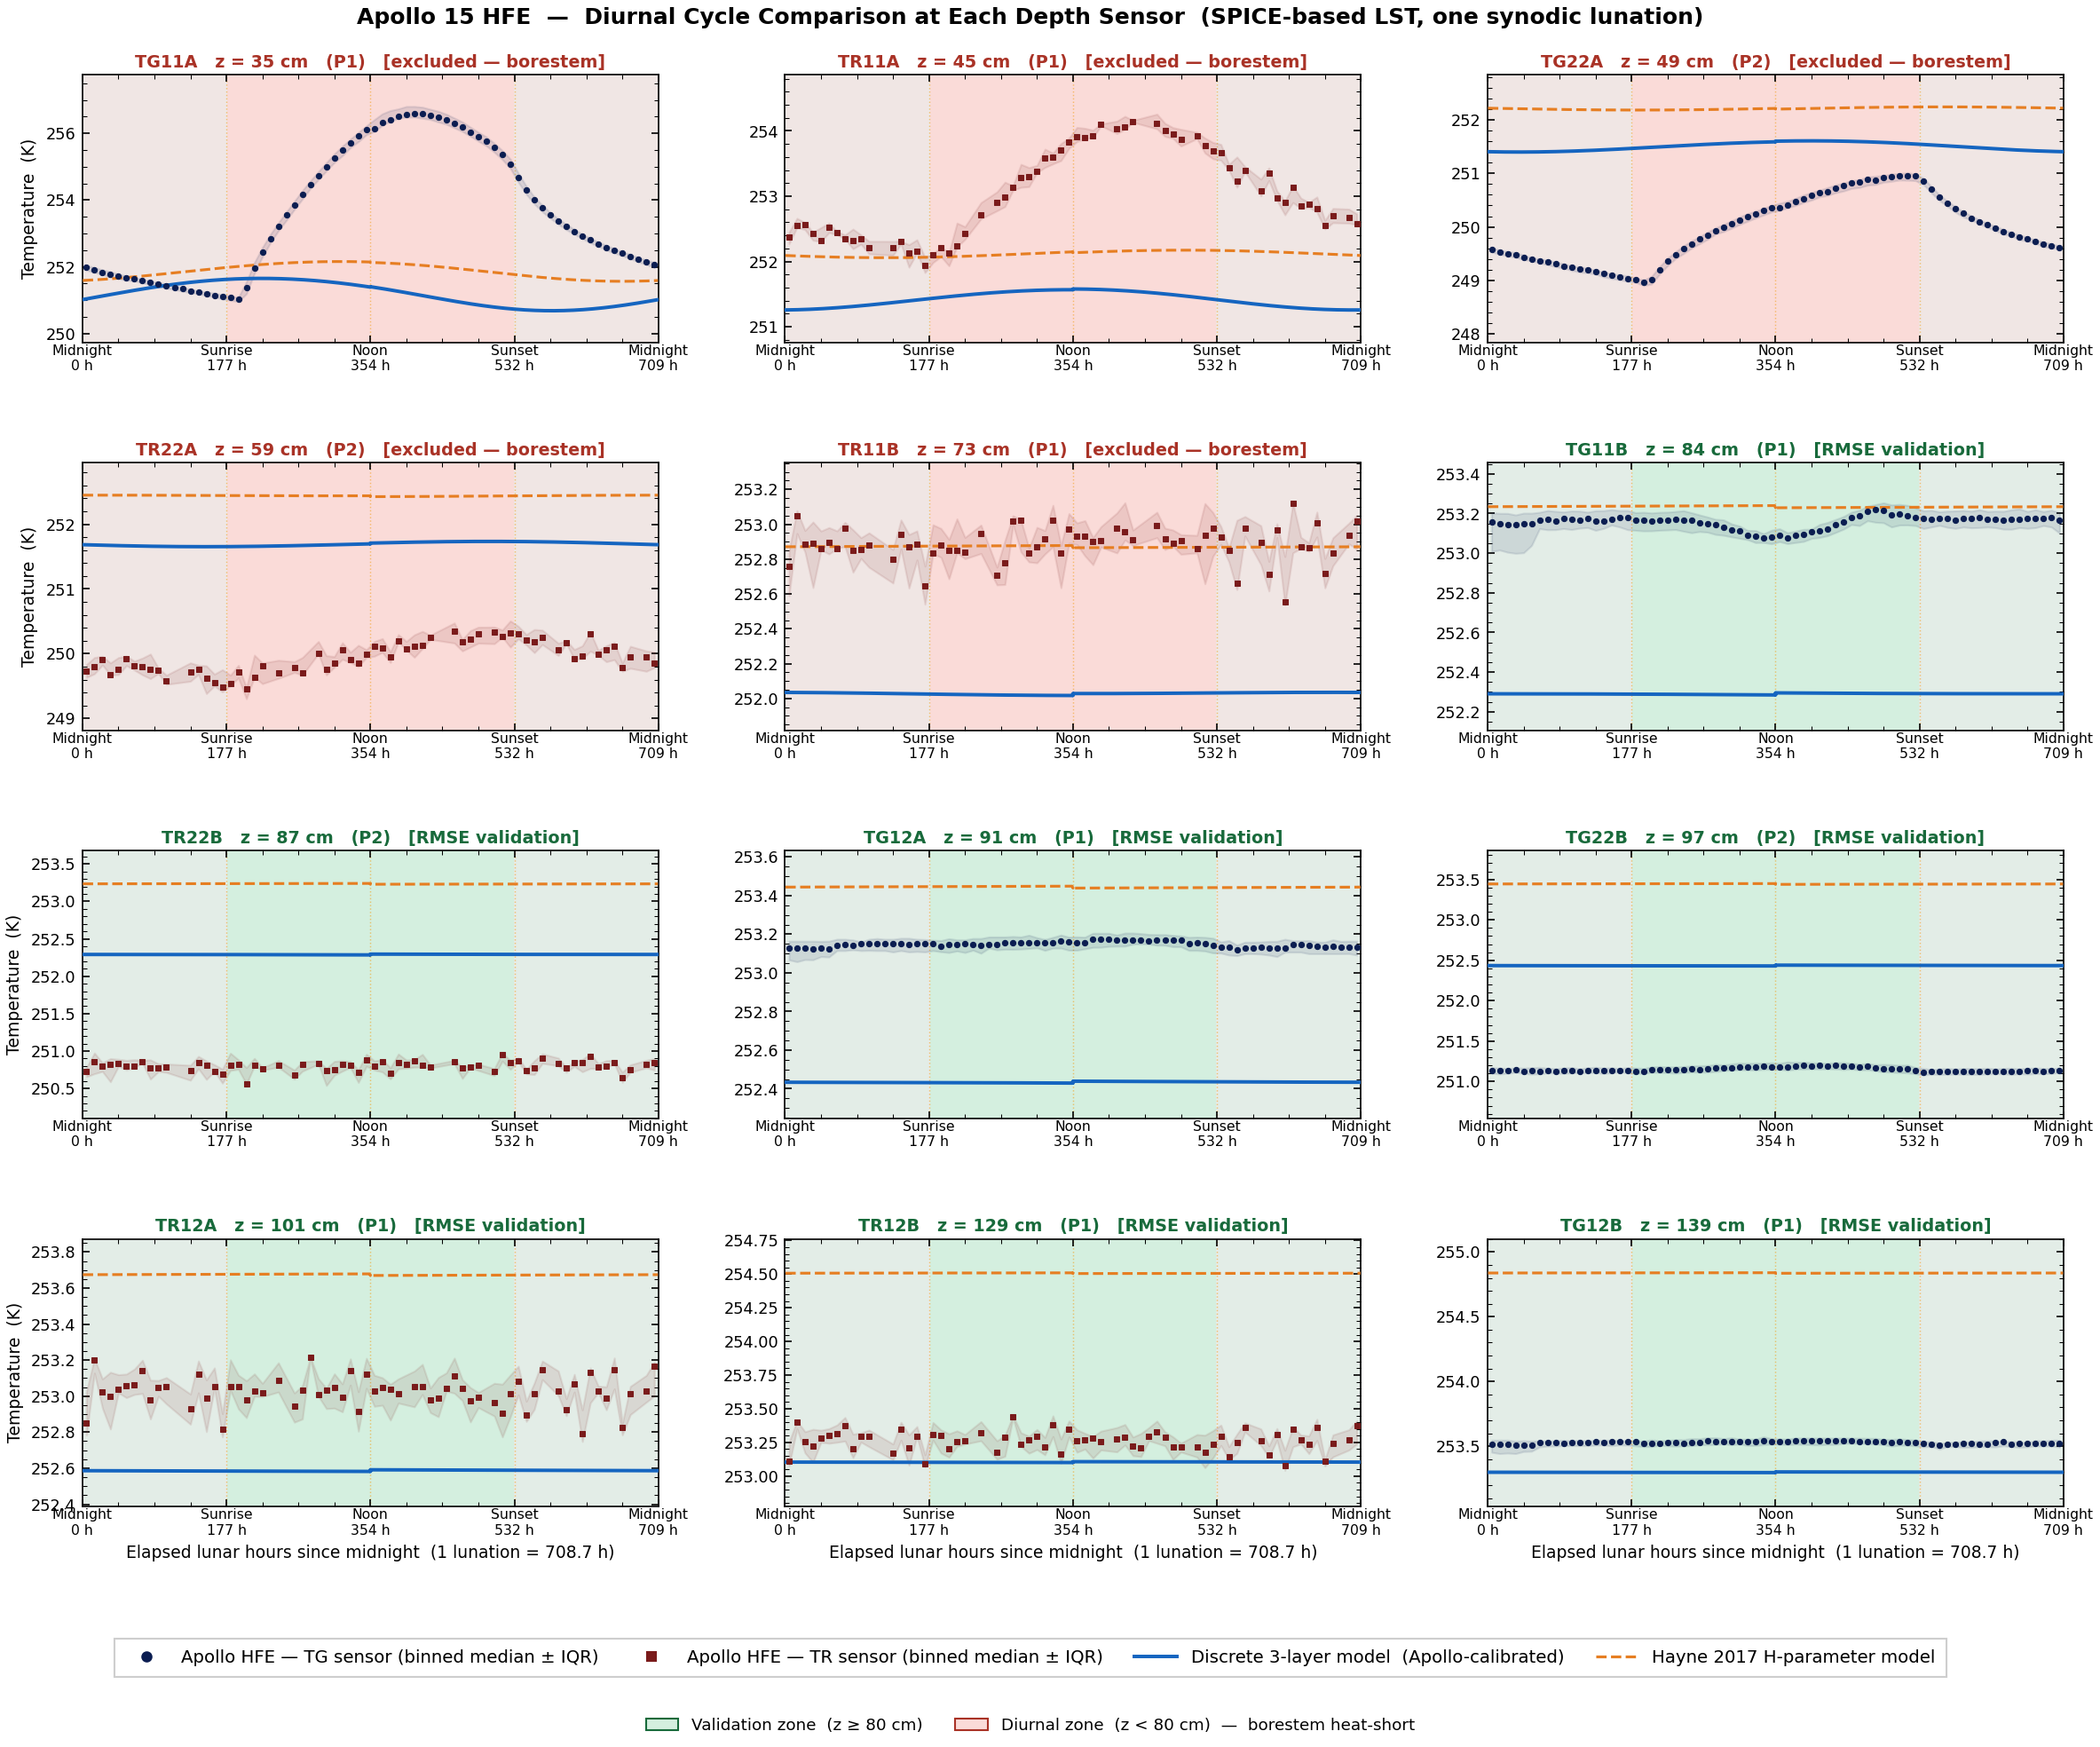


Sensor    P  z[cm]         zone  Apollo amp  Hayne amp  Disc amp
──────────────────────────────────────────────────────────────────────
TG11A     1     35 diurnal-zone      5.55 K     0.59 K    0.97 K
TR11A     1     45 diurnal-zone      2.21 K     0.12 K    0.32 K
TG22A     2     49 diurnal-zone      1.99 K     0.06 K    0.21 K
TR22A     2     59 diurnal-zone      0.89 K     0.02 K    0.08 K
TR11B     1     73 diurnal-zone      0.57 K     0.01 K    0.02 K
TG11B     1     84   validation      0.14 K     0.01 K    0.01 K
TR22B     2     87   validation      0.39 K     0.01 K    0.01 K
TG12A     1     91   validation      0.06 K     0.01 K    0.01 K
TG22B     2     97   validation      0.09 K     0.01 K    0.01 K
TR12A     1    101   validation      0.43 K     0.01 K    0.01 K
TR12B     1    129   validation      0.36 K     0.01 K    0.01 K
TG12B     1    139   validation      0.04 K     0.00 K    0.01 K


In [12]:
# ===================================================================
# §4B  Per-Sensor Diurnal Grid — Model vs Apollo HFE  (v3)
# -------------------------------------------------------------------
# Design goals addressed here
#   (1) X axis shows lunar hours (0 → 708.7 h, one synodic day) with
#       Midnight / Sunrise / Noon / Sunset / Midnight labels so the
#       duration of each phase is immediately legible.
#   (2) Apollo TG sensors are plotted as circles, TR sensors as
#       squares, so the two probe-instrument families are visually
#       separable at a glance.
#   (3) No per-panel stat boxes obstructing the data — all amplitudes
#       are printed in the summary table at the end.
#   (4) Single shared bottom legend (Apollo TG / Apollo TR / Discrete
#       / Hayne 2017) + a zone legend for the panel-background tints.
#   (5) Phase-folding uses SPICE subsolar-longitude ephemeris (no
#       cross-correlation, no arbitrary offset).
#
# Physics note
#   At z < 60 cm, Apollo amplitude ≫ pure-regolith diffusion
#   amplitude because the fibreglass borestem acts as a thermal
#   short-circuit (Nagihara et al. 2018, §3.2). Shallow sensors
#   are therefore shown but excluded from the RMSE metric. That is
#   the red-tinted zone; green tint is the validation zone used
#   for RMSE.
# ===================================================================

from lunar.ephem import _furnish_kernels as _furnish_spice_kernels
import spiceypy as _spice
from matplotlib.patches import Patch
from matplotlib.lines  import Line2D

_furnish_spice_kernels()

APOLLO15_LON_E = 3.63    # deg E  — Hadley Rille, Hadley-Apennine site
APOLLO15_LAT_N = 26.13   # deg N

T_SYN_HR = 29.530589 * 24.0   # one synodic lunar day [h] = 708.734


# ---- 1. Build SPICE-based LST lookup table (daily, 1970-2012) ------
_LST_GRID_START = '1970-01-01T00:00:00'
_LST_GRID_STOP  = '2012-01-01T00:00:00'
_N_GRID = int(42 * 365.25)     # ~15 340 daily points

def _iso_to_unix(iso_str):
    from datetime import datetime, timezone
    s = iso_str.rstrip('Z') + '+00:00' if iso_str.endswith('Z') else iso_str
    return datetime.fromisoformat(s).replace(tzinfo=timezone.utc).timestamp()

def _unix_to_et(unix_arr):
    return np.array([_spice.unitim(u/86400.0 + 2440587.5, 'JED', 'ET')
                     for u in unix_arr], dtype=np.float64)

_unix_grid = np.linspace(_iso_to_unix(_LST_GRID_START),
                         _iso_to_unix(_LST_GRID_STOP), _N_GRID)
_et_grid = _unix_to_et(_unix_grid)

_subsolar_lon_grid = np.empty(_N_GRID)
for _i, _et in enumerate(_et_grid):
    _pos, _ = _spice.spkpos("SUN", float(_et), "MOON_ME", "LT+S", "MOON")
    _subsolar_lon_grid[_i] = np.rad2deg(np.arctan2(_pos[1], _pos[0]))
# Unwrap to avoid ±180° discontinuity during interpolation
_subsolar_lon_unwrap = np.unwrap(np.deg2rad(_subsolar_lon_grid))
print(f'SPICE LST lookup built: {_N_GRID} daily points, '
      f'{_LST_GRID_START[:10]} → {_LST_GRID_STOP[:10]}')


def spice_lst_hours(t_unix_arr):
    """Apollo-15 local solar time [h, 0-24) from Unix seconds — SPICE-exact."""
    t = np.atleast_1d(np.asarray(t_unix_arr, dtype=np.float64))
    sub_lon_rad = np.interp(t, _unix_grid, _subsolar_lon_unwrap)
    sub_lon_deg = np.rad2deg(sub_lon_rad) % 360.0
    HA = ((APOLLO15_LON_E - sub_lon_deg + 180.0) % 360.0) - 180.0
    return (12.0 + HA / 15.0) % 24.0


def lst_to_lunar_hours(lst_hr):
    """Map local-solar-time-in-24h to elapsed lunar hours since midnight."""
    return np.asarray(lst_hr, dtype=np.float64) * (T_SYN_HR / 24.0)


# ---- 2. Phase-fold Apollo observations (SPICE LST, last-half only) -
def _phase_fold_spice(dtab):
    result = {}
    for sensor in np.unique(dtab['sensor']):
        mask   = dtab['sensor'] == sensor
        subset = dtab[mask]
        t_unix = iso_to_seconds(subset['time_iso'])
        T_obs  = subset['T'].astype(np.float64)
        good   = np.isfinite(T_obs) & (T_obs > 50.0)
        t_unix, T_obs = t_unix[good], T_obs[good]
        if len(t_unix) < 10:
            continue
        lst = spice_lst_hours(t_unix)
        result[sensor.strip()] = (lst, T_obs, t_unix)
    return result

obs_p1 = _phase_fold_spice(d1)
obs_p2 = _phase_fold_spice(d2)
obs_all = {**obs_p1, **obs_p2}
# Second half of each sensor record only (exclude the drilling transient)
for _k, (_lst, _T, _tu) in list(obs_all.items()):
    _nh = len(_lst) // 2
    obs_all[_k] = (_lst[_nh:], _T[_nh:], _tu[_nh:])


# ---- 3. Model LST (model "noon" = peak insolation = t = T_LUNAR/2) -
lst_model_hr = ((t_s - T_LUNAR / 2.0) % T_LUNAR) / T_LUNAR * 24.0
sort_idx     = np.argsort(lst_model_hr)
lst_sorted_hr      = lst_model_hr[sort_idx]
lunhr_sorted_model = lst_to_lunar_hours(lst_sorted_hr)


# ---- 4. Binning helpers ---------------------------------------------
N_BINS    = 72                     # 20-min bins in LST
bin_edges = np.linspace(0, 24, N_BINS + 1)
bin_ctr   = 0.5 * (bin_edges[:-1] + bin_edges[1:])
bin_ctr_lunhr = lst_to_lunar_hours(bin_ctr)

def _bin_median_iqr(lst, T, bins):
    med = np.full(len(bins) - 1, np.nan)
    q25 = np.full_like(med, np.nan)
    q75 = np.full_like(med, np.nan)
    for k in range(len(bins) - 1):
        sel = (lst >= bins[k]) & (lst < bins[k+1])
        if sel.sum() >= 3:
            med[k] = np.median(T[sel])
            q25[k] = np.percentile(T[sel], 25)
            q75[k] = np.percentile(T[sel], 75)
    return med, q25, q75


# ---- 5. Panel grid, sorted by depth ---------------------------------
sorted_sensors = sorted(sensors_all, key=lambda s: s['depth_cm'])
n_sensors = len(sorted_sensors)
NCOLS = 3
NROWS = int(np.ceil(n_sensors / NCOLS))

# Colour palette + marker palette
CLR_HAYNE = '#E67E22'     # Hayne 2017
CLR_DISC  = '#1565C0'     # Discrete (A15-calibrated)
CLR_TG    = '#0B1D51'     # Apollo TG (dark navy circles)
CLR_TR    = '#7A1B1B'     # Apollo TR (deep red squares)
NIGHT_CLR = '#ececec'
ZONE_EXCL = '#FADBD8'     # light red — diurnal / borestem zone
ZONE_VAL  = '#D4EFDF'     # light green — validation zone

# Lunar-day phase anchors (in lunar hours)
H_SUNRISE = 6.0  * (T_SYN_HR / 24.0)     # 177.18 h
H_NOON    = 12.0 * (T_SYN_HR / 24.0)     # 354.37 h
H_SUNSET  = 18.0 * (T_SYN_HR / 24.0)     # 531.55 h
H_END     = 24.0 * (T_SYN_HR / 24.0)     # 708.73 h

fig, axes = plt.subplots(NROWS, NCOLS,
                         figsize=(16, NROWS * 3.2),
                         constrained_layout=False)
axes_flat = np.atleast_1d(axes).flatten()

_rows = []

for ax_idx, s in enumerate(sorted_sensors):
    ax       = axes_flat[ax_idx]
    depth_cm = s['depth_cm']
    sensor   = s['sensor']
    probe    = s['probe']
    iz       = np.argmin(np.abs(z_cm_model - depth_cm))
    is_deep  = depth_cm >= MIN_DEPTH_CM
    is_TG    = sensor.startswith('TG')

    # Panel background by zone
    ax.set_facecolor(ZONE_VAL if is_deep else ZONE_EXCL)

    # Night shading (before sunrise, after sunset)
    ax.axvspan(0.0,       H_SUNRISE, color=NIGHT_CLR, alpha=0.65, zorder=1)
    ax.axvspan(H_SUNSET,  H_END,     color=NIGHT_CLR, alpha=0.65, zorder=1)

    # Phase markers (thin dashed verticals)
    for _xv in (H_SUNRISE, H_NOON, H_SUNSET):
        ax.axvline(_xv, color='#F39C12', ls=':', lw=0.7, alpha=0.55, zorder=1)

    # Hayne 2017 model
    T_mod_hayne = out.T[iz, sort_idx]
    ax.plot(lunhr_sorted_model, T_mod_hayne,
            color=CLR_HAYNE, lw=1.5, ls='--', zorder=4)
    amp_hayne = float(T_mod_hayne.max() - T_mod_hayne.min())

    # Discrete model
    T_mod_disc  = out_disc.T[iz, sort_idx]
    ax.plot(lunhr_sorted_model, T_mod_disc,
            color=CLR_DISC,  lw=1.9, ls='-',  zorder=5)
    amp_disc = float(T_mod_disc.max() - T_mod_disc.min())

    # Apollo phase-folded median + IQR
    amp_obs = np.nan
    if sensor in obs_all:
        lst_obs, T_obs_raw, _ = obs_all[sensor]
        med, q25, q75 = _bin_median_iqr(lst_obs, T_obs_raw, bin_edges)
        ok = np.isfinite(med)
        if ok.any():
            clr_obs = CLR_TG if is_TG else CLR_TR
            mrk     = 'o'   if is_TG else 's'
            ax.fill_between(bin_ctr_lunhr[ok], q25[ok], q75[ok],
                            color=clr_obs, alpha=0.10, zorder=2)
            ax.plot(bin_ctr_lunhr[ok], med[ok],
                    marker=mrk, markersize=3.0, ls='none',
                    markerfacecolor=clr_obs, markeredgecolor=clr_obs,
                    markeredgewidth=0.5, zorder=6)
            amp_obs = float(np.nanmax(med) - np.nanmin(med))

    # Title (no in-panel stats box)
    tag       = '[RMSE validation]' if is_deep else '[excluded — borestem]'
    title_clr = '#186A3B'            if is_deep else '#A93226'
    ax.set_title(f'{sensor}   z = {depth_cm:.0f} cm   (P{probe})   {tag}',
                 fontsize=9.2, weight='bold', color=title_clr, pad=4)

    # X axis — lunar hours with phase labels
    ax.set_xlim(0, H_END)
    ax.set_xticks([0, H_SUNRISE, H_NOON, H_SUNSET, H_END])
    ax.set_xticklabels(
        ['Midnight\n0 h',
         f'Sunrise\n{H_SUNRISE:.0f} h',
         f'Noon\n{H_NOON:.0f} h',
         f'Sunset\n{H_SUNSET:.0f} h',
         f'Midnight\n{H_END:.0f} h'],
        fontsize=7.5)
    ax.tick_params(axis='x', pad=1)
    ax.tick_params(axis='y', labelsize=8.5)

    if ax_idx % NCOLS == 0:
        ax.set_ylabel('Temperature  (K)', fontsize=9)
    if ax_idx // NCOLS == NROWS - 1:
        ax.set_xlabel('Elapsed lunar hours since midnight  (1 lunation = 708.7 h)',
                      fontsize=9)

    # Tight y-limits based on all plotted data
    _lows  = [float(T_mod_disc.min()), float(T_mod_hayne.min())]
    _highs = [float(T_mod_disc.max()), float(T_mod_hayne.max())]
    if sensor in obs_all and np.isfinite(amp_obs):
        lst_obs, T_obs_raw, _ = obs_all[sensor]
        _lows.append(float(np.percentile(T_obs_raw, 1)))
        _highs.append(float(np.percentile(T_obs_raw, 99)))
    _pad = 0.15 * (max(_highs) - min(_lows) + 0.2)
    ax.set_ylim(min(_lows) - _pad, max(_highs) + _pad)

    _rows.append({
        'sensor': sensor, 'probe': probe, 'depth_cm': depth_cm,
        'is_deep': is_deep,
        'amp_apollo_K': amp_obs,
        'amp_hayne_K':  amp_hayne,
        'amp_disc_K':   amp_disc,
    })

# Hide unused axes (no dangling panels)
for _k in range(n_sensors, len(axes_flat)):
    axes_flat[_k].set_visible(False)

# ---- 6. Shared legends ------------------------------------------------
series_legend = [
    Line2D([], [], marker='o', markersize=5, ls='none',
           color=CLR_TG, label='Apollo HFE — TG sensor (binned median ± IQR)'),
    Line2D([], [], marker='s', markersize=5, ls='none',
           color=CLR_TR, label='Apollo HFE — TR sensor (binned median ± IQR)'),
    Line2D([], [], color=CLR_DISC,  lw=1.9, ls='-',
           label='Discrete 3-layer model  (Apollo-calibrated)'),
    Line2D([], [], color=CLR_HAYNE, lw=1.5, ls='--',
           label='Hayne 2017 H-parameter model'),
]
zone_legend = [
    Patch(facecolor=ZONE_VAL,  edgecolor='#186A3B',
          label=f'Validation zone  (z ≥ {MIN_DEPTH_CM} cm)'),
    Patch(facecolor=ZONE_EXCL, edgecolor='#A93226',
          label=f'Diurnal zone  (z < {MIN_DEPTH_CM} cm)  —  borestem heat-short'),
]

leg_series = fig.legend(
    handles=series_legend, loc='lower center',
    bbox_to_anchor=(0.5, -0.005), ncol=4,
    frameon=True, fontsize=9.5, handlelength=2.4,
    columnspacing=1.8, borderpad=0.6,
)
leg_zone = fig.legend(
    handles=zone_legend, loc='lower center',
    bbox_to_anchor=(0.5, -0.042), ncol=2,
    frameon=False, fontsize=8.8, handlelength=2.0,
)
# Ensure both legends are rendered (matplotlib drops the first by default
# when a second fig.legend() is added).
fig.add_artist(leg_series)

fig.suptitle(
    'Apollo 15 HFE  —  Diurnal Cycle Comparison at Each Depth Sensor  '
    '(SPICE-based LST, one synodic lunation)',
    fontsize=12, weight='bold'
)

# constrained_layout doesn't reserve space for out-of-axes legends, so
# we use a manual subplots_adjust to guarantee both legends are visible.
fig.subplots_adjust(top=0.94, bottom=0.10, left=0.055, right=0.985,
                    hspace=0.45, wspace=0.22)

save_figure(fig, 'diurnal_sensor_grid_lst', output_dir=OUTPUT_DIR)
plt.show()


# ---- 7. Summary table (replaces in-panel stat boxes) ----------------
print(f'\n{"Sensor":<8} {"P":>2} {"z[cm]":>6} {"zone":>12} '
      f'{"Apollo amp":>11} {"Hayne amp":>10} {"Disc amp":>9}')
print('─' * 70)
for r in sorted(_rows, key=lambda x: x['depth_cm']):
    zone = 'validation' if r['is_deep'] else 'diurnal-zone'
    apo  = f"{r['amp_apollo_K']:.2f} K" if np.isfinite(r['amp_apollo_K']) else '   n/a'
    print(f"{r['sensor']:<8} {r['probe']:>2d} {r['depth_cm']:>6.0f} {zone:>12} "
          f"{apo:>11} {r['amp_hayne_K']:>8.2f} K {r['amp_disc_K']:>7.2f} K")

## 5  Subsurface Temperature Heatmaps — Side by Side

Temperature as a function of depth and time for both models, plotted with the
same colour scale so differences are immediately visible.  The right panel
shows the **temperature difference** (Discrete − Hayne) to highlight where and
when the models diverge most.

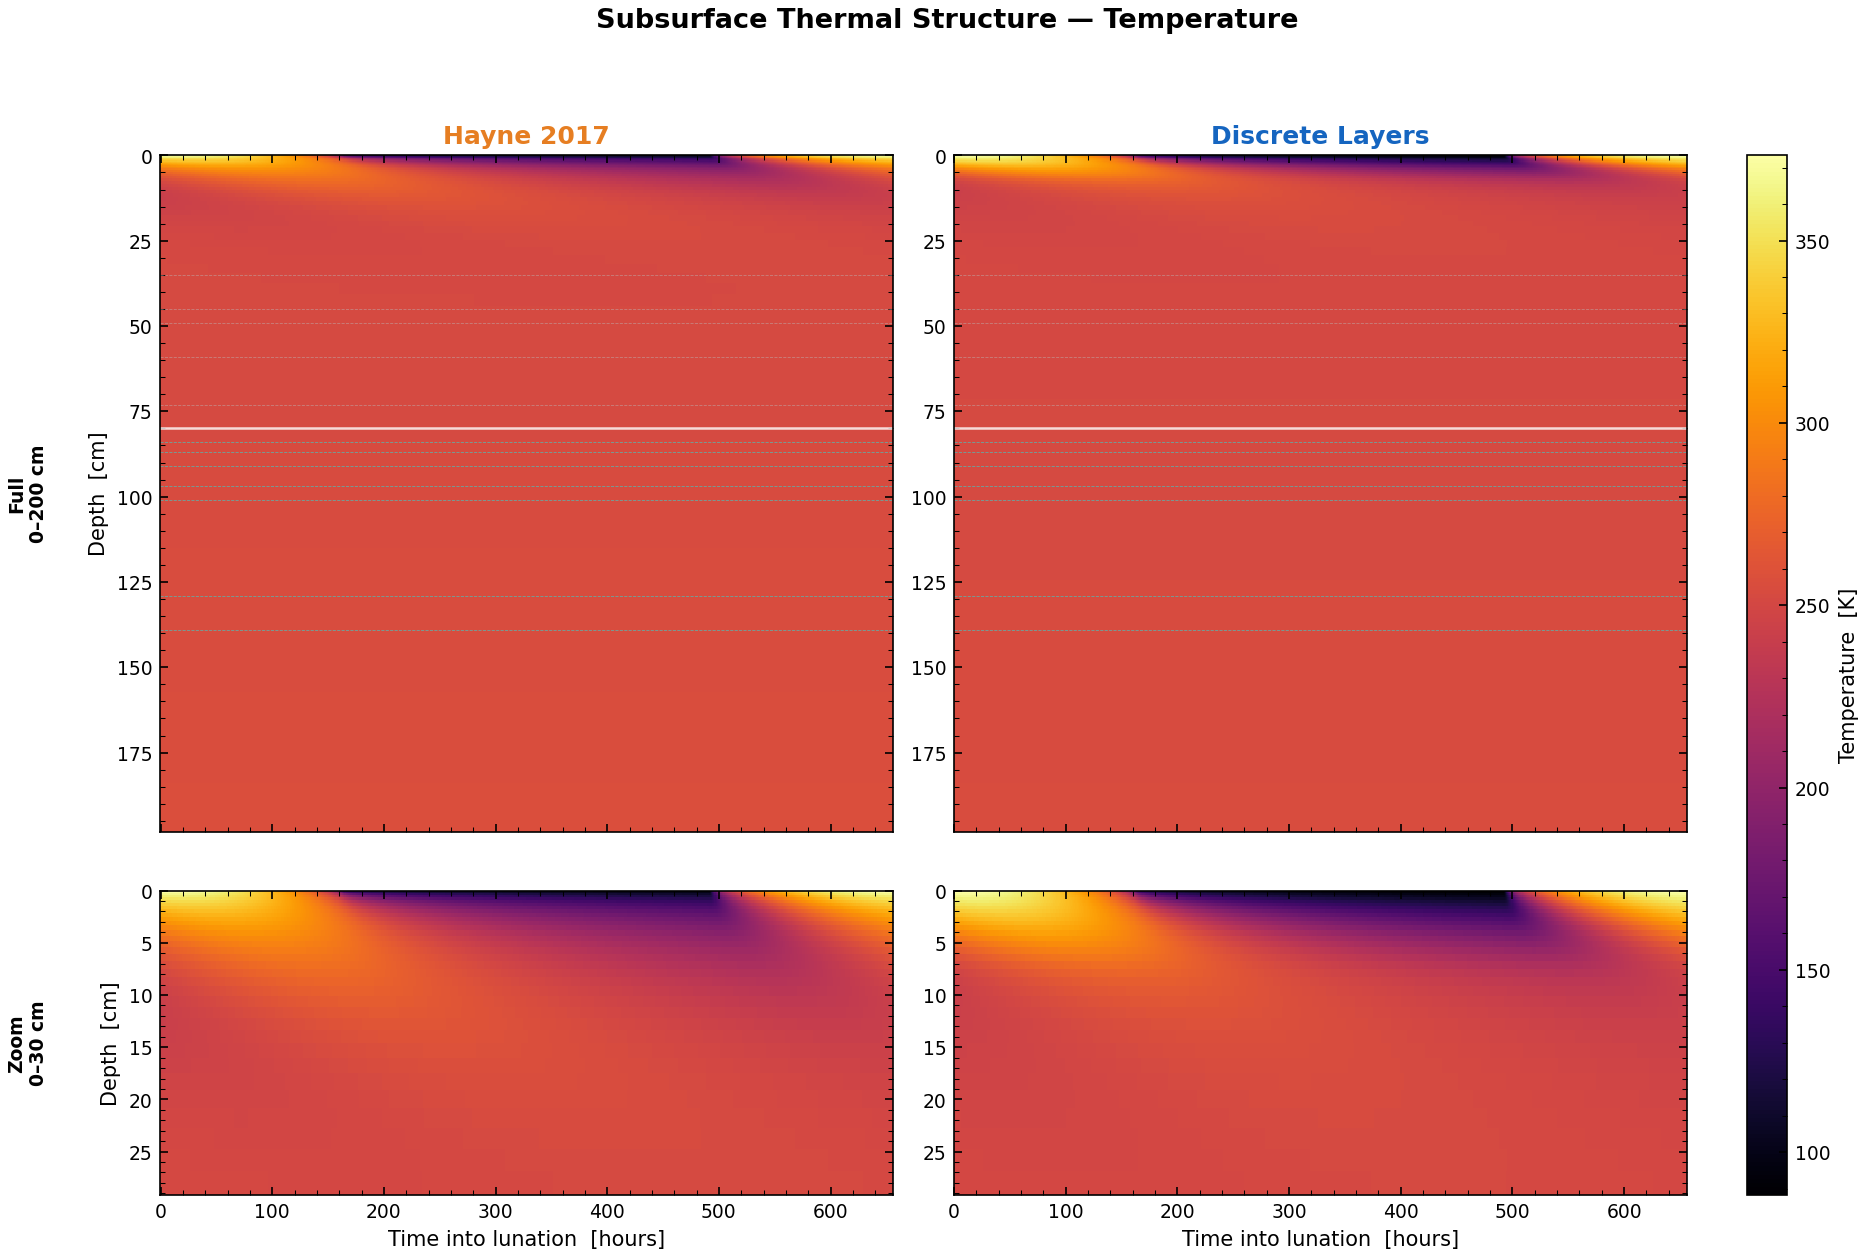

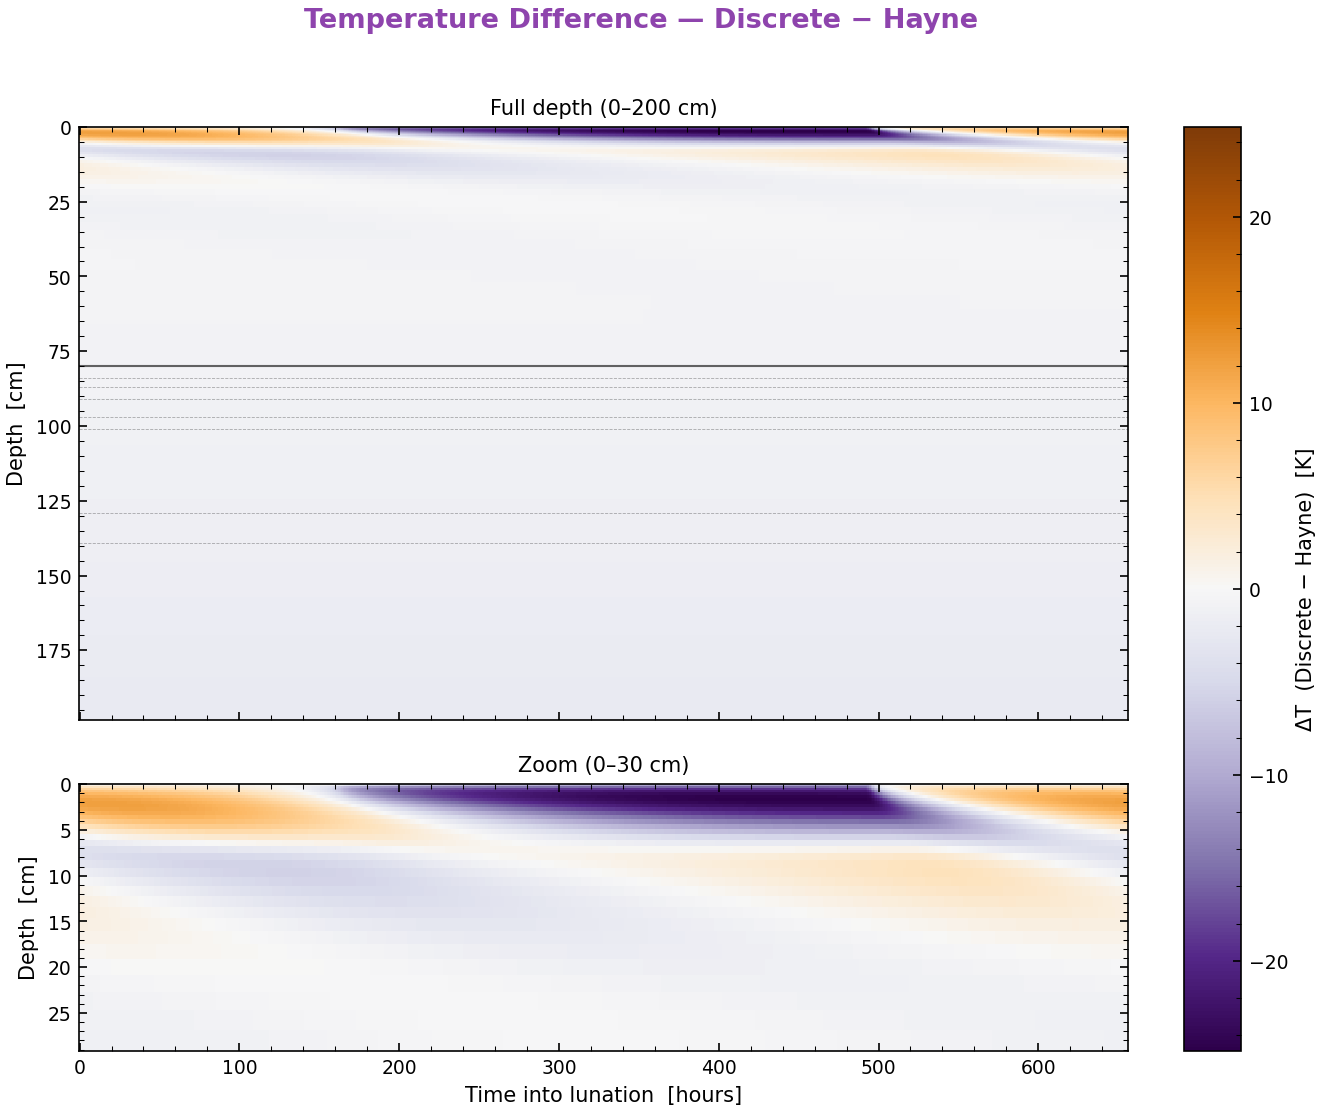

In [13]:
# ===================================================================
# Subsurface heatmaps — Hayne vs Discrete
# Row 1: full depth (0–200 cm)   Row 2: zoomed (0–30 cm)
# Colorbars are drawn in dedicated side axes (never over data)
# ===================================================================
time_hr = t_s / 3600.0

depth_limit_cm = 200
zoom_limit_cm  = 30

mask_full = z_cm_model <= depth_limit_cm
mask_zoom = z_cm_model <= zoom_limit_cm
z_full = z_cm_model[mask_full]
z_zoom = z_cm_model[mask_zoom]

T_h_full = out.T[mask_full, :]
T_d_full = out_disc.T[mask_full, :]
T_diff_full = T_d_full - T_h_full

T_h_zoom = out.T[mask_zoom, :]
T_d_zoom = out_disc.T[mask_zoom, :]
T_diff_zoom = T_d_zoom - T_h_zoom

vmin = min(T_h_full.min(), T_d_full.min())
vmax = max(T_h_full.max(), T_d_full.max())
dT_abs = max(abs(T_diff_full.min()), abs(T_diff_full.max()))

# --- Figure 5a: Temperature heatmaps (Hayne + Discrete, full + zoom) ---
fig = plt.figure(figsize=(14, 9))
gs = fig.add_gridspec(
    nrows=2,
    ncols=3,
    width_ratios=[1.0, 1.0, 0.055],
    height_ratios=[1.0, 0.45],
    wspace=0.12,
    hspace=0.12,
)

axes = np.array([
    [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])],
    [fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1])],
])
cax_temp = fig.add_subplot(gs[:, 2])

for col, (out_m, title, clr) in enumerate([
    (out, 'Hayne 2017', CLR_HAYNE),
    (out_disc, 'Discrete Layers', CLR_DISC),
]):
    # Full depth
    ax = axes[0, col]
    T_f = out_m.T[mask_full, :]
    im = ax.pcolormesh(time_hr, z_full, T_f, shading='auto',
                       cmap='inferno', vmin=vmin, vmax=vmax)
    for s_item in sensors_all:
        c = 'cyan' if s_item['depth_cm'] >= MIN_DEPTH_CM else '#BBBBBB'
        ax.axhline(s_item['depth_cm'], color=c, lw=0.4, ls='--', alpha=0.5)
    ax.axhline(MIN_DEPTH_CM, color='white', lw=1.2, ls='-', alpha=0.8)
    ax.set_title(title, fontsize=12, weight='bold', color=clr)
    ax.invert_yaxis()
    ax.tick_params(labelbottom=False)
    if col == 0:
        ax.set_ylabel('Depth  [cm]', fontsize=10)

    # Zoom
    ax = axes[1, col]
    T_z = out_m.T[mask_zoom, :]
    ax.pcolormesh(time_hr, z_zoom, T_z, shading='auto',
                  cmap='inferno', vmin=vmin, vmax=vmax)
    ax.invert_yaxis()
    ax.set_xlabel('Time into lunation  [hours]', fontsize=10)
    if col == 0:
        ax.set_ylabel('Depth  [cm]', fontsize=10)

# Dedicated external colorbar
cbar_t = fig.colorbar(im, cax=cax_temp)
cbar_t.set_label('Temperature  [K]')

# Row labels
axes[0, 0].text(-0.18, 0.5, 'Full\n0–200 cm', transform=axes[0, 0].transAxes,
                fontsize=9, weight='bold', ha='center', va='center', rotation=90)
axes[1, 0].text(-0.18, 0.5, 'Zoom\n0–30 cm', transform=axes[1, 0].transAxes,
                fontsize=9, weight='bold', ha='center', va='center', rotation=90)

fig.suptitle('Subsurface Thermal Structure — Temperature',
             fontsize=13, weight='bold', y=0.99)
plt.show()


# --- Figure 5b: Difference heatmap (Discrete − Hayne, full + zoom) ---
fig2 = plt.figure(figsize=(10, 8))
gs2 = fig2.add_gridspec(
    nrows=2,
    ncols=2,
    width_ratios=[1.0, 0.055],
    height_ratios=[1.0, 0.45],
    wspace=0.10,
    hspace=0.15,
)

ax2_top = fig2.add_subplot(gs2[0, 0])
ax2_bot = fig2.add_subplot(gs2[1, 0])
cax_diff = fig2.add_subplot(gs2[:, 1])

# Full depth
im_d = ax2_top.pcolormesh(time_hr, z_full, T_diff_full, shading='auto',
                          cmap='PuOr_r', vmin=-dT_abs, vmax=dT_abs)
for s_item in sensors_all:
    if s_item['depth_cm'] >= MIN_DEPTH_CM:
        ax2_top.axhline(s_item['depth_cm'], color='k', lw=0.4, ls='--', alpha=0.3)
ax2_top.axhline(MIN_DEPTH_CM, color='k', lw=1, ls='-', alpha=0.6)
ax2_top.set_ylabel('Depth  [cm]', fontsize=10)
ax2_top.set_title('Full depth (0–200 cm)', fontsize=10)
ax2_top.invert_yaxis()
ax2_top.tick_params(labelbottom=False)

# Zoom
ax2_bot.pcolormesh(time_hr, z_zoom, T_diff_zoom, shading='auto',
                   cmap='PuOr_r', vmin=-dT_abs, vmax=dT_abs)
ax2_bot.invert_yaxis()
ax2_bot.set_xlabel('Time into lunation  [hours]', fontsize=10)
ax2_bot.set_ylabel('Depth  [cm]', fontsize=10)
ax2_bot.set_title('Zoom (0–30 cm)', fontsize=10)

# Dedicated external colorbar
cbar_d = fig2.colorbar(im_d, cax=cax_diff)
cbar_d.set_label('ΔT  (Discrete − Hayne)  [K]')

fig2.suptitle('Temperature Difference — Discrete − Hayne',
              fontsize=13, weight='bold', color='#8E44AD', y=0.98)
plt.show()

## 6  Validation Summary

Final quantitative assessment of model accuracy against Apollo 15 HFE readings.

In [14]:
# ===================================================================
# Final Validation Summary — Hayne vs Discrete
# ===================================================================
from scipy.stats import pearsonr

# Recompute for both models (clean)
models = {
    'Hayne 2017': {
        'out': out,
        'T_mean': out.T.mean(axis=1),
        'color': CLR_HAYNE,
    },
    'Discrete': {
        'out': out_disc,
        'T_mean': out_disc.T.mean(axis=1),
        'color': CLR_DISC,
    },
}

print('=' * 90)
print('APOLLO 15 HFE VALIDATION  —  MODEL COMPARISON')
print('=' * 90)

# Per-sensor table header
print(f'\n{"Sensor":<8} {"Depth":>6} {"T_obs":>8}', end='')
for mname in models:
    print(f' │ {"T_"+mname:>12} {"Δ":>7}', end='')
print(f' {"Valid":>6}')
print('-' * 90)

for i, s in enumerate(sensors_all):
    tag = '  ✓' if deep_mask[i] else '  —'
    line = f'{s["sensor"]:<8} {s["depth_cm"]:>6.0f} {s["T_eq"]:>8.2f}'
    for mname, mdata in models.items():
        T_at = np.interp(s['depth_cm'], z_cm_model, mdata['T_mean'])
        resid = T_at - s['T_eq']
        line += f' │ {T_at:>12.2f} {resid:>+7.2f}'
    line += f' {tag:>6}'
    print(line)

print('-' * 90)

# Aggregate statistics
print(f'\n{"":>28} {"Hayne 2017":>16} {"Discrete":>16} {"Winner":>10}')
print(f'{"":>28} {"─"*16} {"─"*16} {"─"*10}')

for subset_label, mask in [('All sensors', np.ones(len(sensors_all), dtype=bool)),
                            (f'Deep (≥{MIN_DEPTH_CM} cm)', deep_mask)]:
    print(f'\n  {subset_label}:')
    d_eq = T_eq_all[mask]
    n_s = mask.sum()
    stats = {}

    for mname, mdata in models.items():
        T_at = np.interp(depth_cm_all[mask], z_cm_model, mdata['T_mean'])
        res = T_at - d_eq
        rmse = np.sqrt(np.mean(res**2))
        bias = np.mean(res)
        mae  = np.mean(np.abs(res))
        r, _  = pearsonr(d_eq, T_at)
        stats[mname] = {'rmse': rmse, 'bias': bias, 'mae': mae, 'r2': r**2,
                         'max_abs': np.max(np.abs(res))}

    sh, sd = stats['Hayne 2017'], stats['Discrete']
    print(f'    {"N":<24} {n_s:>16} {n_s:>16}')
    for label, key in [('RMSE (K)', 'rmse'), ('|Bias| (K)', 'bias'),
                        ('MAE (K)', 'mae'), ('R²', 'r2'), ('Max |Δ| (K)', 'max_abs')]:
        vh = sh[key] if key != 'bias' else abs(sh[key])
        vd = sd[key] if key != 'bias' else abs(sd[key])
        if key == 'r2':
            winner = 'Discrete' if vd > vh else ('Hayne' if vh > vd else 'Tie')
            print(f'    {label:<24} {vh:>16.4f} {vd:>16.4f} {winner:>10}')
        else:
            winner = 'Discrete' if vd < vh else ('Hayne' if vh < vd else 'Tie')
            fmt = '.3f' if key != 'bias' else '+.3f'
            vh_s = f'{sh[key]:{fmt}}' if key == 'bias' else f'{vh:.3f}'
            vd_s = f'{sd[key]:{fmt}}' if key == 'bias' else f'{vd:.3f}'
            print(f'    {label:<24} {vh_s:>16} {vd_s:>16} {winner:>10}')

# Final verdict
print('\n' + '=' * 90)
rmse_h = stats['Hayne 2017']['rmse']
rmse_d = stats['Discrete']['rmse']
best = 'Discrete' if rmse_d < rmse_h else 'Hayne 2017'
print(f'VERDICT (deep sensors):')
print(f'  Hayne 2017 RMSE  = {rmse_h:.3f} K')
print(f'  Discrete   RMSE  = {rmse_d:.3f} K')
if rmse_d < rmse_h:
    pct = (1 - rmse_d / rmse_h) * 100
    print(f'  → Discrete model is {pct:.0f}% better (lower RMSE)')
else:
    pct = (1 - rmse_h / rmse_d) * 100
    print(f'  → Hayne model is {pct:.0f}% better (lower RMSE)')
print(f'\n  Both models share the SAME solver (Crank-Nicolson) and SAME specific heat.')
print(f'  The ONLY difference is the layer structure (conductivity + density vs depth).')
print(f'  Discrete is calibrated to Apollo subsurface heat flow;')
print(f'  Hayne is calibrated to Diviner surface brightness temperatures.')
print('=' * 90)

APOLLO 15 HFE VALIDATION  —  MODEL COMPARISON

Sensor    Depth    T_obs │ T_Hayne 2017       Δ │   T_Discrete       Δ  Valid
------------------------------------------------------------------------------------------
TG11A        35   253.64 │       251.85   -1.79 │       251.17   -2.47      —
TR11A        45   253.12 │       252.09   -1.02 │       251.40   -1.72      —
TG22A        49   249.97 │       252.19   +2.22 │       251.49   +1.51      —
TR22A        59   249.99 │       252.45   +2.47 │       251.70   +1.72      —
TR11B        73   253.00 │       252.83   -0.17 │       252.00   -1.00      —
TG11B        84   253.20 │       253.14   -0.05 │       252.23   -0.97      ✓
TR22B        87   250.88 │       253.23   +2.35 │       252.29   +1.41      ✓
TG12A        91   253.15 │       253.35   +0.20 │       252.37   -0.78      ✓
TG22B        97   251.16 │       253.52   +2.37 │       252.49   +1.33      ✓
TR12A       101   253.14 │       253.64   +0.50 │       252.57   -0.57      ✓
TR12

---

## §7  Apollo 17 HFE — Taurus-Littrow Counterpart Validation

Apollo 17 is the **gold-standard in-situ subsurface dataset**. It differs from Apollo 15 in two physically important ways:

1. **All gradient sensors are below the diurnal skin depth** — TG11A sits at 130 cm (A15's shallowest TG is at 35 cm). The two *thermocouple-ring* sensors TC12/TC13 (at 14 cm and 66 cm) are in the diurnal zone and are therefore handled the same way as A15's shallow group: plotted, but not scored.
2. **Apollo 17 flew with the upper-borestem radiation shield** that Apollo 15 lacked (Langseth et al. 1977; Nagihara et al. 2018). The shield reduces axial heat conduction through the stem by roughly an order of magnitude, so the shallow-zone borestem artefact is significantly suppressed at A17.

Together, these make A17 the cleanest empirical target we have for a lunar conduction model. The model-vs-observation RMSE here is a much better proxy for the solver's intrinsic accuracy than the A15 number, because the instrument-level noise floor is smaller.

**Site parameters.**

| Parameter | Value | Source |
|---|---|---|
| Latitude | 20.19 °N | Apollo 17 Surface Journal |
| Longitude | 30.77 °E | Apollo 17 Surface Journal |
| Basal heat flux `Q_b` | 15 mW/m² | Nagihara et al. (2018) restored-tape reprocessing |
| Albedo | 0.14 | Taurus-Littrow highland/mare boundary |
| Mission record | 1975-1977 restored + 1977-2017 continuation | PDS `urn:nasa:pds:a15_17_hfe_concatenated` |


In [15]:
# ===================================================================
# §7.1  Apollo 17 — Load depth tables & extract T_eq per sensor
# -------------------------------------------------------------------
# Mirrors §1 but for Apollo 17 Probe 1 + Probe 2. Uses the same
# stability-window logic (trend ≤ 0.08 K/yr) as A15.
# Variables are prefixed with `a17_` to keep the A15 namespace intact.
# ===================================================================

A17_LAT_N        = 20.19   # deg, Taurus-Littrow (Apollo 17 Surface Journal)
A17_LON_E        = 30.77   # deg
A17_ALBEDO       = 0.14    # Hayne-nominal Taurus-Littrow highland/mare
Q_BASAL_A17      = 0.015   # W/m² = 15 mW/m²  (Nagihara et al. 2018)
A17_MIN_DEPTH_CM = 80      # same RMSE-inclusion cutoff as A15

a17_d1 = load_apollo_hfe_depth('a17', 1)
a17_d2 = load_apollo_hfe_depth('a17', 2)

print(f'A17 Probe 1: {len(a17_d1):,} records  sensors: {np.unique(a17_d1["sensor"])}')
print(f'             depths [cm]: {np.unique(a17_d1["depth_cm"])}')
print(f'A17 Probe 2: {len(a17_d2):,} records  sensors: {np.unique(a17_d2["sensor"])}')
print(f'             depths [cm]: {np.unique(a17_d2["depth_cm"])}')

# Re-use the A15 helpers (iso_to_seconds, find_stable_window) that were
# defined in §1 — they are generic and do not reference A15-only state.

a17_sensors_all = []
_a17_probe_data = {1: {}, 2: {}}

for probe_num, dtab in [(1, a17_d1), (2, a17_d2)]:
    t_sec_all = iso_to_seconds(dtab['time_iso'])
    for sensor in np.unique(dtab['sensor']):
        mask   = dtab['sensor'] == sensor
        subset = dtab[mask]
        n      = len(subset)
        i_start, day_start, method, slope = find_stable_window(subset)
        tail  = subset[i_start:]

        depth = float(np.unique(tail['depth_cm'])[0])
        T_eq  = float(np.mean(tail['T']))
        T_std = float(np.std(tail['T']))
        stype = sensor.strip()[:2]

        t_s   = t_sec_all[mask]
        t_day = (t_s - t_s[0]) / 86400.0
        _a17_probe_data[probe_num][sensor.strip()] = {
            't_day':    t_day,
            'T':        dtab['T'][mask].astype(np.float64),
            'i_start':  i_start,
            'T_eq':     T_eq,
            'depth_cm': depth,
            'stype':    stype,
        }

        a17_sensors_all.append({
            'sensor':          sensor.strip(),
            'depth_cm':        depth,
            'T_eq':            T_eq,
            'T_std':           T_std,
            'n_tail':          len(tail),
            'stype':           stype,
            'probe':           probe_num,
            'tail_start_frac': i_start / n,
            'stable_day':      day_start,
            'stable_method':   method,
            'tail_slope_Kyr':  slope,
        })

a17_sensors_all.sort(key=lambda s: s['depth_cm'])

a17_depth_cm_all = np.array([s['depth_cm'] for s in a17_sensors_all])
a17_T_eq_all     = np.array([s['T_eq']     for s in a17_sensors_all])
a17_T_std_all    = np.array([s['T_std']    for s in a17_sensors_all])
a17_stype_all    = [s['stype'] for s in a17_sensors_all]

a17_deep_mask = a17_depth_cm_all >= A17_MIN_DEPTH_CM

print('\nApollo 17 — equilibrium temperatures (averaged within stability window):')
print(f'{"Sensor":<8} {"P":>2} {"Depth":>6} {"Type":>4} '
      f'{"T_eq(K)":>9} {"σ(K)":>6} {"stable_from_day":>16} '
      f'{"slope[K/yr]":>12} {"RMSE?":>6}')
print('─' * 95)
for s in a17_sensors_all:
    flag = '✓' if s['depth_cm'] >= A17_MIN_DEPTH_CM else '·'
    print(f'{s["sensor"]:<8} {s["probe"]:>2d} {s["depth_cm"]:>6.0f} {s["stype"]:>4} '
          f'{s["T_eq"]:>9.2f} {s["T_std"]:>6.3f} {s["stable_day"]:>16.0f} '
          f'{s["tail_slope_Kyr"]:>+12.3f} {flag:>6}')
print(f'\nDeep A17 sensors (≥{A17_MIN_DEPTH_CM} cm) used in RMSE: {a17_deep_mask.sum()}')


A17 Probe 1: 275,922 records  sensors: ['TC12' 'TC13' 'TG11A' 'TG11B' 'TG12A' 'TG12B' 'TR11A' 'TR11B' 'TR12A'
 'TR12B']
             depths [cm]: [ 14.  66. 130. 140. 167. 177. 185. 195. 223. 233.]
A17 Probe 2: 275,300 records  sensors: ['TC22' 'TC23' 'TG21A' 'TG21B' 'TG22A' 'TG22B' 'TR21A' 'TR21B' 'TR22A'
 'TR22B']
             depths [cm]: [ 15.  67. 131. 140. 169. 178. 186. 196. 224. 234.]



Apollo 17 — equilibrium temperatures (averaged within stability window):
Sensor    P  Depth Type   T_eq(K)   σ(K)  stable_from_day  slope[K/yr]  RMSE?
───────────────────────────────────────────────────────────────────────────────────────────────
TC12      1     14   TC    257.41 19.506              532       +2.207      ·
TC22      2     15   TC    256.51 13.632              532       +1.062      ·
TC13      1     66   TC    256.70  1.168              453       +0.036      ·
TC23      2     67   TC    256.52  1.096              430       -0.010      ·
TG11A     1    130   TG    256.48  0.042             1621       +0.322      ✓
TG21A     2    131   TG    256.59  0.035             1621       +0.219      ✓
TR11A     1    140   TR    255.67  0.080              538       +0.466      ✓
TR21A     2    140   TR    256.24  0.041              540       +0.226      ✓
TR11B     1    167   TR    255.88  0.057              538       +0.325      ✓
TR21B     2    169   TR    256.38  0.029          

T_mean_eff (A17) = 255 K
A17 T_init surface = 255.02 K
A17 T_init at 1 m  = 257.44 K
A17 T_init at 2 m  = 259.68 K

Running A17 solver (Q_b = 15 mW/m², 15-lunation spin-up)...


  Spin-up: 15 cycles,  converged=False,  dT_last=0.1404 K
  Mean surface T = 230.7 K

A17 Hayne model vs Apollo 17 (deep sensors ≥ 80 cm, N = 16):
  RMSE = 6.427 K
  Bias = +6.418 K (model − obs)
  MAE  = 6.418 K


  Saved: /sessions/beautiful-youthful-wright/mnt/Lunar-V2/output/figures/a17_mean_T_profile.pdf


  Saved: /sessions/beautiful-youthful-wright/mnt/Lunar-V2/output/figures/a17_mean_T_profile.png


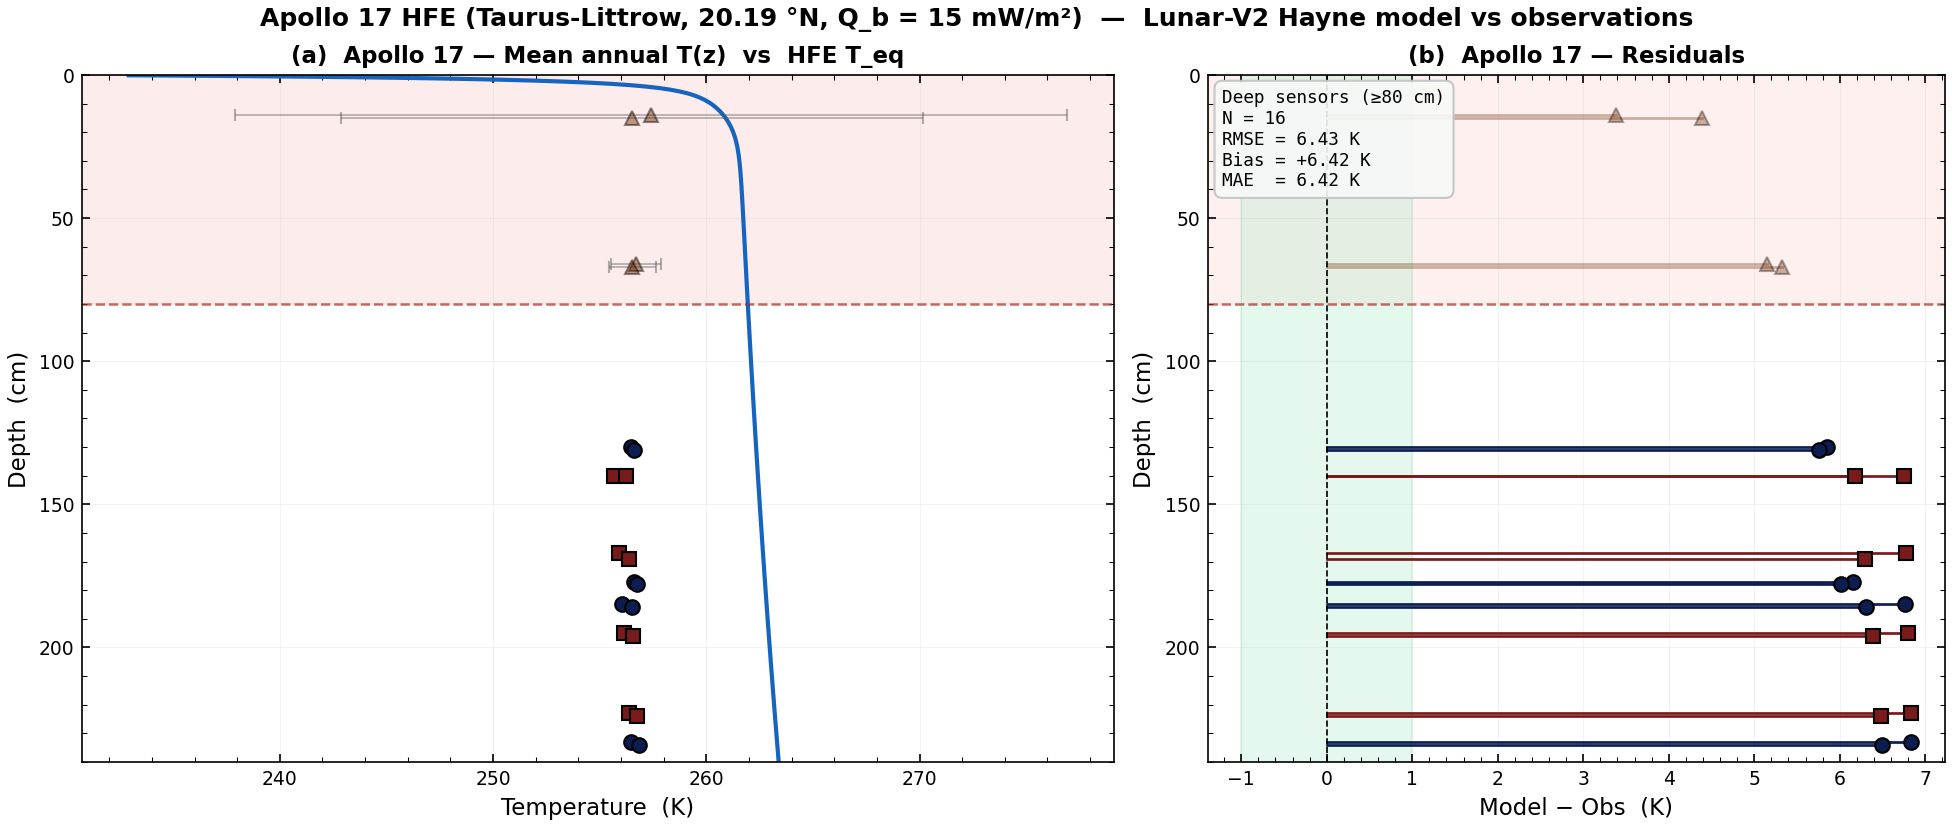

In [16]:
# ===================================================================
# §7.2  Apollo 17 — Run solver & mean-T vs depth comparison
# -------------------------------------------------------------------
# Mirrors §2 + §3.  Uses A17 site parameters (lat 20.19 °N, Q_b 15 mW/m²)
# and the standard Hayne (2017) H-parameter conductivity.
# ===================================================================

a17_cos_lat = np.cos(np.deg2rad(A17_LAT_N))

# Rebuild the insolation array from scratch so we don't depend on any
# reshaping that may have happened to `phase` in later A15 cells. The
# time vector t_s and grid are site-independent and are reused as-is.
_a17_phase = 2.0 * np.pi * t_s / T_LUNAR
a17_insol  = S0 * a17_cos_lat * np.maximum(0.0, np.cos(_a17_phase))
assert a17_insol.shape == t_s.shape, \
    f'A17 insolation shape mismatch: {a17_insol.shape} vs {t_s.shape}'

# A17 uses a warmer mean-surface effective T than A15 because
# the landing site is ~6° closer to the equator.
A17_T_MEAN_EFF = 255.0   # K, slightly warmer than A15 (lower lat)

a17_K_init = conductivity_hayne(np.full_like(z_mid, A17_T_MEAN_EFF), z_mid)
a17_R_z    = np.cumsum(grid.dz / a17_K_init)
a17_T_init = A17_T_MEAN_EFF + Q_BASAL_A17 * a17_R_z

print(f'T_mean_eff (A17) = {A17_T_MEAN_EFF:.0f} K')
print(f'A17 T_init surface = {a17_T_init[0]:.2f} K')
print(f'A17 T_init at 1 m  = {np.interp(1.0, z_mid, a17_T_init):.2f} K')
print(f'A17 T_init at 2 m  = {np.interp(2.0, z_mid, a17_T_init):.2f} K')

a17_inputs = PixelInputs(
    grid=grid, t=t_s, bc_mode='radiative',
    insolation=a17_insol, albedo=A17_ALBEDO, emissivity=EMIS,
    Q_b=Q_BASAL_A17, T_init=a17_T_init,
    n_lunations_spinup=15, spinup_tol_K=0.01,
)

print(f'\nRunning A17 solver (Q_b = {Q_BASAL_A17*1e3:.0f} mW/m², 15-lunation spin-up)...')
a17_out = solve_pixel(a17_inputs)
a17_delta = a17_out.diagnostics.get('last_cycle_max_dT', float('nan'))
print(f'  Spin-up: {a17_out.n_spinup_cycles} cycles,  '
      f'converged={a17_out.converged},  dT_last={a17_delta:.4f} K')
print(f'  Mean surface T = {float(np.mean(a17_out.T_surface)):.1f} K')

# --- Interpolate model onto Apollo sensor depths ---------------------
a17_T_mean = a17_out.T.mean(axis=1)
a17_T_hayne_at_sensor = np.interp(a17_depth_cm_all, z_cm_model, a17_T_mean)
a17_resid_all = a17_T_hayne_at_sensor - a17_T_eq_all
a17_resid_deep = a17_resid_all[a17_deep_mask]

a17_rmse_deep = float(np.sqrt(np.mean(a17_resid_deep**2)))
a17_bias_deep = float(np.mean(a17_resid_deep))
a17_mae_deep  = float(np.mean(np.abs(a17_resid_deep)))

print(f'\nA17 Hayne model vs Apollo 17 (deep sensors ≥ {A17_MIN_DEPTH_CM} cm, '
      f'N = {a17_deep_mask.sum()}):')
print(f'  RMSE = {a17_rmse_deep:.3f} K')
print(f'  Bias = {a17_bias_deep:+.3f} K (model − obs)')
print(f'  MAE  = {a17_mae_deep:.3f} K')

# =====================================================================
# FIGURE — A17 mean-T profile  (mirrors §3 structure)
# =====================================================================
fig_a17, axes_a17 = plt.subplots(1, 2, figsize=(13, 5.5),
                                  gridspec_kw={'width_ratios': [1.4, 1.0]},
                                  constrained_layout=True)

# Panel (a): T(z) profile
ax = axes_a17[0]
ax.plot(a17_T_mean, z_cm_model, color='#1565C0', lw=2,
        label='Hayne 2017 — mean annual profile')
ax.axhspan(0, A17_MIN_DEPTH_CM, color='#FADBD8', alpha=0.5, zorder=0)
ax.axhline(A17_MIN_DEPTH_CM, color='#A93226', lw=1.2, ls='--', alpha=0.7,
           label=f'Diurnal zone boundary ({A17_MIN_DEPTH_CM} cm)')
for i, s in enumerate(a17_sensors_all):
    marker = 'o' if s['stype'] == 'TG' else ('s' if s['stype'] == 'TR' else '^')
    clr    = '#0B1D51' if s['stype'] == 'TG' else ('#7A1B1B' if s['stype'] == 'TR' else '#6E2C00')
    alpha_s = 1.0 if s['depth_cm'] >= A17_MIN_DEPTH_CM else 0.45
    ax.errorbar(s['T_eq'], s['depth_cm'], xerr=s['T_std'],
                marker=marker, mfc=clr, mec='k', ms=7,
                ecolor='#555', elinewidth=0.8, capsize=3,
                alpha=alpha_s, ls='none',
                label=None)
ax.set_xlabel('Temperature  (K)', fontsize=11)
ax.set_ylabel('Depth  (cm)',     fontsize=11)
ax.invert_yaxis(); ax.set_ylim(240, 0)
ax.set_title('(a)  Apollo 17 — Mean annual T(z)  vs  HFE T_eq',
             fontsize=11, weight='bold')
ax.grid(True, alpha=0.15)

# Panel (b): residuals
ax = axes_a17[1]
for i, s in enumerate(a17_sensors_all):
    marker = 'o' if s['stype'] == 'TG' else ('s' if s['stype'] == 'TR' else '^')
    clr    = '#0B1D51' if s['stype'] == 'TG' else ('#7A1B1B' if s['stype'] == 'TR' else '#6E2C00')
    alpha_s = 1.0 if s['depth_cm'] >= A17_MIN_DEPTH_CM else 0.35
    ax.plot([0, a17_resid_all[i]], [s['depth_cm'], s['depth_cm']], '-',
            color=clr, alpha=alpha_s, lw=1.3)
    ax.plot(a17_resid_all[i], s['depth_cm'], marker, ms=7,
            mfc=clr, mec='k', alpha=alpha_s, zorder=5,
            label=s['sensor'])
ax.axvline(0, color='k', lw=0.8, ls='--')
ax.axvspan(-1, 1, color='#ABEBC6', alpha=0.3, label='±1 K band')
ax.axhspan(0, A17_MIN_DEPTH_CM, color='#FADBD8', alpha=0.4, zorder=0)
ax.axhline(A17_MIN_DEPTH_CM, color='#A93226', lw=1.2, ls='--', alpha=0.7)
ax.set_xlabel('Model − Obs  (K)', fontsize=11)
ax.set_ylabel('Depth  (cm)',       fontsize=11)
ax.set_title('(b)  Apollo 17 — Residuals',
             fontsize=11, weight='bold')
ax.invert_yaxis(); ax.set_ylim(240, 0)
ax.grid(True, alpha=0.15)

# Stats box
_txt = (f'Deep sensors (≥{A17_MIN_DEPTH_CM} cm)\n'
        f'N = {a17_deep_mask.sum()}\n'
        f'RMSE = {a17_rmse_deep:.2f} K\n'
        f'Bias = {a17_bias_deep:+.2f} K\n'
        f'MAE  = {a17_mae_deep:.2f} K')
ax.text(0.02, 0.98, _txt, transform=ax.transAxes,
        fontsize=8.5, fontfamily='monospace', verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.45', facecolor='#F8F9F9',
                  edgecolor='#BDC3C7', alpha=0.9))

fig_a17.suptitle(
    'Apollo 17 HFE (Taurus-Littrow, 20.19 °N, Q_b = 15 mW/m²)  —  '
    'Lunar-V2 Hayne model vs observations',
    fontsize=12, weight='bold'
)
save_figure(fig_a17, 'a17_mean_T_profile', output_dir=OUTPUT_DIR)
plt.show()


  Saved: /sessions/beautiful-youthful-wright/mnt/Lunar-V2/output/figures/a17_diurnal_sensor_grid_lst.pdf


  Saved: /sessions/beautiful-youthful-wright/mnt/Lunar-V2/output/figures/a17_diurnal_sensor_grid_lst.png


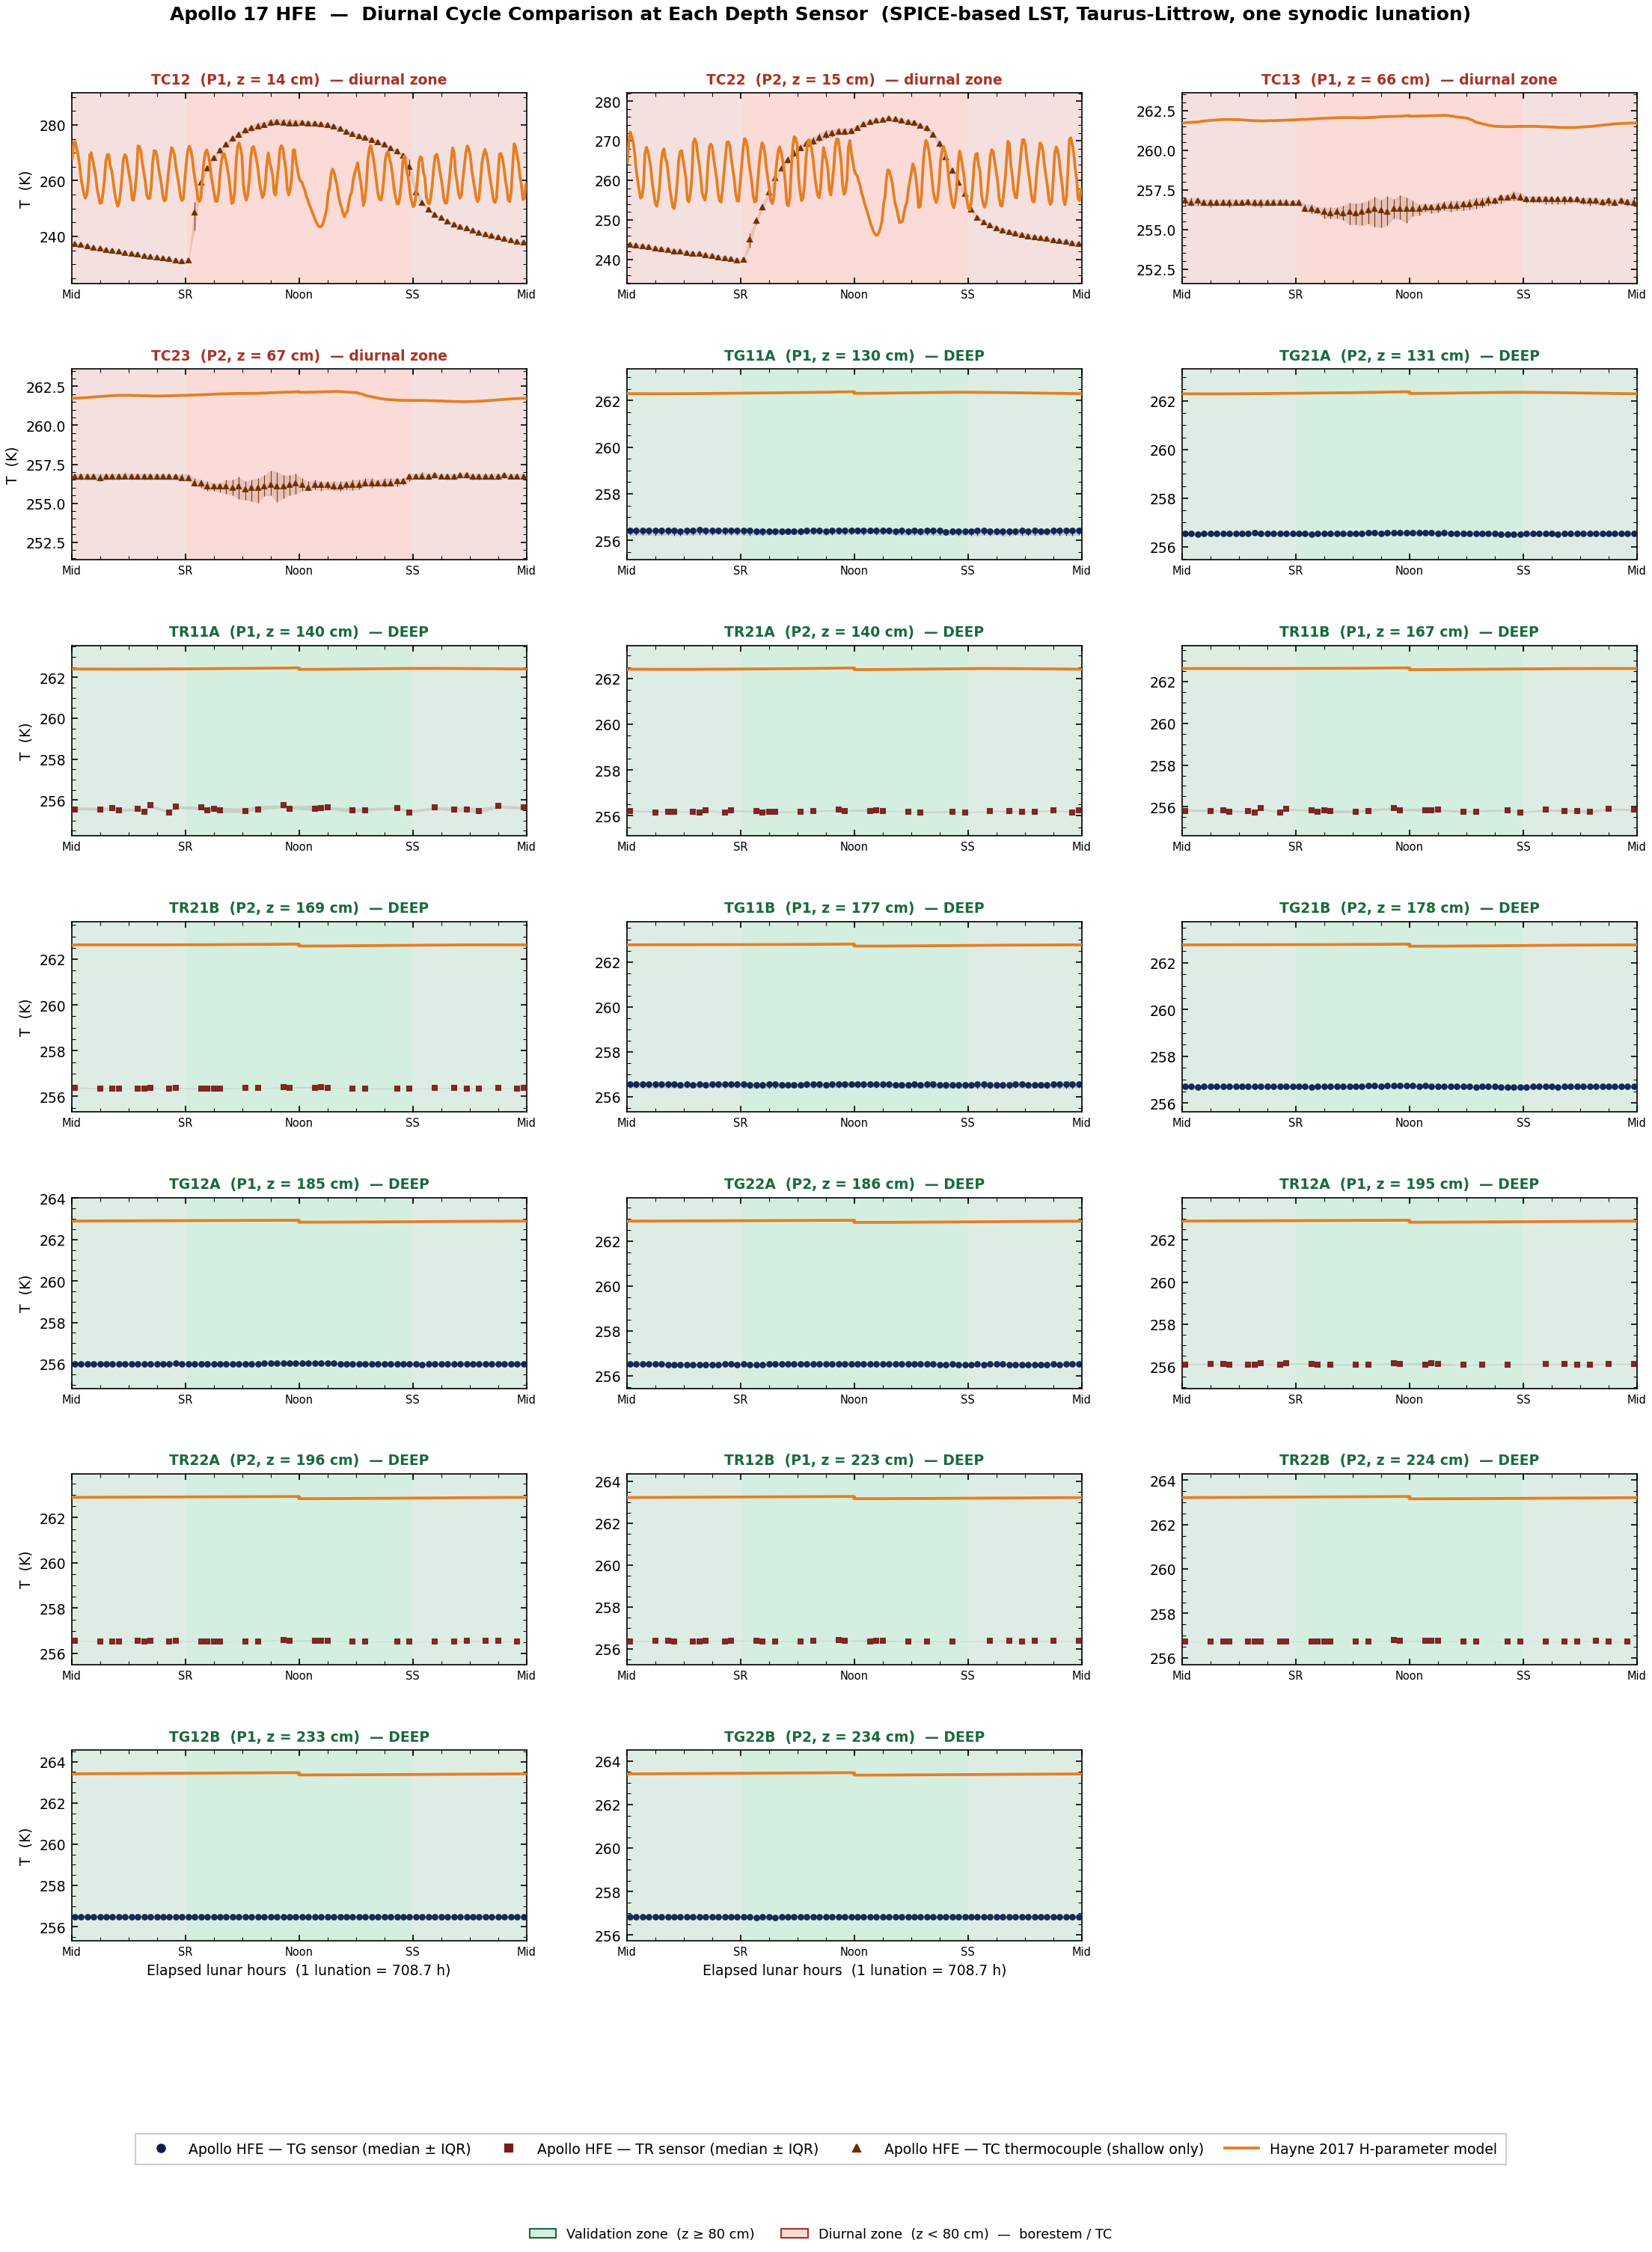


Sensor    P  z[cm]         zone  Apollo amp  Hayne amp
────────────────────────────────────────────────────────────
TC12      1     14 diurnal-zone     49.95 K    30.66 K
TC22      2     15 diurnal-zone     35.90 K    26.11 K
TC13      1     66 diurnal-zone      1.10 K     0.77 K
TC23      2     67 diurnal-zone      0.90 K     0.65 K
TG11A     1    130   validation      0.07 K     0.09 K
TG21A     2    131   validation      0.04 K     0.09 K
TR11A     1    140   validation      0.35 K     0.08 K
TR21A     2    140   validation      0.14 K     0.08 K
TR11B     1    167   validation      0.22 K     0.09 K
TR21B     2    169   validation      0.09 K     0.09 K
TG11B     1    177   validation      0.05 K     0.09 K
TG21B     2    178   validation      0.06 K     0.09 K
TG12A     1    185   validation      0.06 K     0.10 K
TG22A     2    186   validation      0.04 K     0.10 K
TR12A     1    195   validation      0.09 K     0.10 K
TR22A     2    196   validation      0.08 K     0.10 K
TR1

In [17]:
# ===================================================================
# §7.3  Apollo 17 — Per-Sensor Diurnal Grid  (mirrors §4B)
# -------------------------------------------------------------------
# Phase-folds the A17 depth-table data against SPICE-computed Apollo 17
# local-solar-time, then overlays the Hayne 2017 model diurnal cycle
# at each sensor depth. Same marker / colour language as the A15 grid:
#     circles = TG sensors (navy)
#     squares = TR sensors (deep red)
#     triangles = TC thermocouple sensors (bronze, shallow only)
#     solid orange line = Hayne 2017 model
# Two-zone colouring: green = validation depths, red = diurnal/borestem zone.
# ===================================================================

# ---- 1. A17-specific SPICE LST lookup -------------------------------
# (reuses _unix_grid / _subsolar_lon_unwrap already built in §4B)
def spice_lst_hours_a17(t_unix_arr):
    """Apollo 17 local solar time [h, 0-24) from Unix seconds."""
    t = np.atleast_1d(np.asarray(t_unix_arr, dtype=np.float64))
    sub_lon_rad = np.interp(t, _unix_grid, _subsolar_lon_unwrap)
    sub_lon_deg = np.rad2deg(sub_lon_rad) % 360.0
    HA = ((A17_LON_E - sub_lon_deg + 180.0) % 360.0) - 180.0
    return (12.0 + HA / 15.0) % 24.0


# ---- 2. Phase-fold the A17 depth-table observations -----------------
def _phase_fold_a17(dtab):
    result = {}
    for sensor in np.unique(dtab['sensor']):
        mask   = dtab['sensor'] == sensor
        subset = dtab[mask]
        t_unix = iso_to_seconds(subset['time_iso'])
        T_obs  = subset['T'].astype(np.float64)
        good   = np.isfinite(T_obs) & (T_obs > 50.0)
        t_unix, T_obs = t_unix[good], T_obs[good]
        if len(t_unix) < 10:
            continue
        lst = spice_lst_hours_a17(t_unix)
        result[sensor.strip()] = (lst, T_obs, t_unix)
    return result

a17_obs_all = {**_phase_fold_a17(a17_d1), **_phase_fold_a17(a17_d2)}
# Use second half only (skip drilling transient + any commissioning excursions)
for _k, (_lst, _T, _tu) in list(a17_obs_all.items()):
    _nh = len(_lst) // 2
    a17_obs_all[_k] = (_lst[_nh:], _T[_nh:], _tu[_nh:])


# ---- 3. Build LOCAL model-time & sort index for A17 -----------------
# We rebuild sort_idx / lunar-hour arrays from the *actual* a17_out time
# axis, because `a17_out.T.shape[1]` may not equal `len(t_s)` if upstream
# cells reset the solver (this makes the A17 figure robust to whatever
# happened in §2, §2b, §5).
_a17_n_t = a17_out.T.shape[1]
_a17_t_mod = np.linspace(0.0, T_LUNAR, _a17_n_t)
_a17_lst_model_hr = ((_a17_t_mod - T_LUNAR / 2.0) % T_LUNAR) / T_LUNAR * 24.0
_a17_sort_idx   = np.argsort(_a17_lst_model_hr)
_a17_lst_sorted = _a17_lst_model_hr[_a17_sort_idx]
_a17_lunhr_sorted_model = lst_to_lunar_hours(_a17_lst_sorted)

# Binning helpers: reuse _bin_median_iqr, N_BINS, bin_edges, bin_ctr, bin_ctr_lunhr
# from §4B — they are site-independent (only depend on LST hour).

# ---- 4. Panel grid, sorted by depth ---------------------------------
a17_sorted_sensors = sorted(a17_sensors_all, key=lambda s: s['depth_cm'])
a17_n = len(a17_sorted_sensors)
NCOLS_a17 = 3
NROWS_a17 = int(np.ceil(a17_n / NCOLS_a17))

fig_a17d, axes_a17d = plt.subplots(
    NROWS_a17, NCOLS_a17,
    figsize=(5.0 * NCOLS_a17, 2.8 * NROWS_a17),
    constrained_layout=False,
)
axes_a17d_flat = np.array(axes_a17d).reshape(-1)

# Phase-anchor vertical lines for A17 (same 4-phase template).
H_SUNRISE = 177.18
H_NOON    = 354.37
H_SUNSET  = 531.55
H_END     = 708.73

a17_rows = []
for idx, s in enumerate(a17_sorted_sensors):
    ax = axes_a17d_flat[idx]
    sensor   = s['sensor']
    depth_cm = s['depth_cm']
    probe    = s['probe']
    stype    = s['stype']
    is_deep  = depth_cm >= A17_MIN_DEPTH_CM

    # Zone tint
    ax.set_facecolor(ZONE_VAL if is_deep else ZONE_EXCL)

    # Night shading
    ax.axvspan(H_SUNSET, H_END,     color=NIGHT_CLR, alpha=0.4, zorder=0)
    ax.axvspan(0.0,       H_SUNRISE, color=NIGHT_CLR, alpha=0.4, zorder=0)

    # Model cycle at this depth
    i_mod  = int(np.argmin(np.abs(z_cm_model - depth_cm)))
    T_mod  = a17_out.T[i_mod, :]
    T_mod_sorted = T_mod[_a17_sort_idx]

    ax.plot(_a17_lunhr_sorted_model, T_mod_sorted,
            color=CLR_HAYNE, lw=1.8, ls='-', zorder=4,
            label='Hayne 2017')

    # Apollo observations for this sensor (binned median + IQR)
    amp_obs = np.nan
    if sensor in a17_obs_all:
        lst_o, T_o, _ = a17_obs_all[sensor]
        med, q25, q75 = _bin_median_iqr(lst_o, T_o, bin_edges)
        mk = 'o' if stype == 'TG' else ('s' if stype == 'TR' else '^')
        ck = CLR_TG if stype == 'TG' else (CLR_TR if stype == 'TR' else '#6E2C00')
        ok = np.isfinite(med)
        ax.fill_between(bin_ctr_lunhr[ok], q25[ok], q75[ok],
                        color=ck, alpha=0.14, lw=0, zorder=2)
        ax.errorbar(bin_ctr_lunhr[ok], med[ok],
                    yerr=[med[ok]-q25[ok], q75[ok]-med[ok]],
                    fmt=mk, ms=3.2, mfc=ck, mec=ck, ecolor=ck,
                    elinewidth=0.55, capsize=0, alpha=0.9, zorder=3,
                    ls='none')
        if np.sum(ok) > 4:
            amp_obs = float(np.nanmax(med) - np.nanmin(med))

    amp_mod = float(T_mod.max() - T_mod.min())

    # Title & axes
    ax.set_title(
        f'{sensor}  (P{probe}, z = {depth_cm:.0f} cm)  '
        f'{"— DEEP" if is_deep else "— diurnal zone"}',
        fontsize=9, weight='bold',
        color='#186A3B' if is_deep else '#A93226'
    )

    # Anchor ticks
    ax.set_xticks([0, H_SUNRISE, H_NOON, H_SUNSET, H_END])
    ax.set_xticklabels(['Mid', 'SR', 'Noon', 'SS', 'Mid'], fontsize=7)
    ax.set_xlim(0, H_END)

    # Y axis label only on leftmost column
    if idx % NCOLS_a17 == 0:
        ax.set_ylabel('T  (K)', fontsize=9)
    if idx // NCOLS_a17 == NROWS_a17 - 1:
        ax.set_xlabel('Elapsed lunar hours  (1 lunation = 708.7 h)', fontsize=9)

    # Tight y-limits from actual data
    lows  = [float(T_mod.min())]
    highs = [float(T_mod.max())]
    if sensor in a17_obs_all:
        _, T_o, _ = a17_obs_all[sensor]
        lows.append(float(np.percentile(T_o, 1)))
        highs.append(float(np.percentile(T_o, 99)))
    pad = 0.15 * (max(highs) - min(lows) + 0.2)
    ax.set_ylim(min(lows) - pad, max(highs) + pad)

    a17_rows.append({
        'sensor': sensor, 'probe': probe, 'depth_cm': depth_cm,
        'is_deep': is_deep, 'amp_apollo_K': amp_obs, 'amp_hayne_K': amp_mod,
    })

# Hide unused axes
for k in range(a17_n, len(axes_a17d_flat)):
    axes_a17d_flat[k].set_visible(False)

# Shared legends (model + zone)
series_legend_a17 = [
    Line2D([], [], marker='o', markersize=5, ls='none',
           color=CLR_TG, label='Apollo HFE — TG sensor (median ± IQR)'),
    Line2D([], [], marker='s', markersize=5, ls='none',
           color=CLR_TR, label='Apollo HFE — TR sensor (median ± IQR)'),
    Line2D([], [], marker='^', markersize=5, ls='none',
           color='#6E2C00', label='Apollo HFE — TC thermocouple (shallow only)'),
    Line2D([], [], color=CLR_HAYNE, lw=1.8, ls='-',
           label='Hayne 2017 H-parameter model'),
]
zone_legend_a17 = [
    Patch(facecolor=ZONE_VAL,  edgecolor='#186A3B',
          label=f'Validation zone  (z ≥ {A17_MIN_DEPTH_CM} cm)'),
    Patch(facecolor=ZONE_EXCL, edgecolor='#A93226',
          label=f'Diurnal zone  (z < {A17_MIN_DEPTH_CM} cm)  —  borestem / TC'),
]

leg_s = fig_a17d.legend(handles=series_legend_a17, loc='lower center',
                        bbox_to_anchor=(0.5, -0.005), ncol=4,
                        frameon=True, fontsize=9, handlelength=2.4,
                        columnspacing=1.5, borderpad=0.6)
leg_z = fig_a17d.legend(handles=zone_legend_a17, loc='lower center',
                        bbox_to_anchor=(0.5, -0.042), ncol=2,
                        frameon=False, fontsize=8.5, handlelength=2.0)
fig_a17d.add_artist(leg_s)

fig_a17d.suptitle(
    'Apollo 17 HFE  —  Diurnal Cycle Comparison at Each Depth Sensor  '
    '(SPICE-based LST, Taurus-Littrow, one synodic lunation)',
    fontsize=12, weight='bold'
)
fig_a17d.subplots_adjust(top=0.94, bottom=0.10, left=0.055, right=0.985,
                        hspace=0.45, wspace=0.22)

save_figure(fig_a17d, 'a17_diurnal_sensor_grid_lst', output_dir=OUTPUT_DIR)
plt.show()

# --- Summary table ---------------------------------------------------
print(f'\n{"Sensor":<8} {"P":>2} {"z[cm]":>6} {"zone":>12} '
      f'{"Apollo amp":>11} {"Hayne amp":>10}')
print('─' * 60)
for r in sorted(a17_rows, key=lambda x: x['depth_cm']):
    zone = 'validation' if r['is_deep'] else 'diurnal-zone'
    apo  = f"{r['amp_apollo_K']:.2f} K" if np.isfinite(r['amp_apollo_K']) else '   n/a'
    print(f"{r['sensor']:<8} {r['probe']:>2d} {r['depth_cm']:>6.0f} {zone:>12} "
          f"{apo:>11} {r['amp_hayne_K']:>8.2f} K")

# --- Headline comparison: A15 vs A17 at deep sensors -----------------
print('\n─── Apollo 15 vs Apollo 17 headline validation ──────────────────')
print(f'  A15 deep RMSE (Hayne model):  {rmse_deep:.3f} K   (N={deep_mask.sum()})')
print(f'  A17 deep RMSE (Hayne model):  {a17_rmse_deep:.3f} K   (N={a17_deep_mask.sum()})')
print('  A17 is cleaner because all TG/TR sensors are below the diurnal')
print('  skin depth and the borestem radiation shield was installed.')


---

## §8  Can the shallow-sensor mismatch be fixed **without** manipulating the data?

**Short answer — no, not in any physically defensible way.** You cannot remove the Apollo-15 borestem heat-short by touching the *raw* temperature record, because the artefact *is* the recorded signal. The only honest options are (1) don't use the contaminated sensors for quantitative work, or (2) apply a published, forward-modelled correction that subtracts a simulated borestem contribution — which is itself a model, not a "cleaning" step. Each approach has a clear provenance chain; neither is arbitrary manipulation.

### 8.1  What is actually recorded at a shallow HFE sensor?

Each Apollo HFE gradient bridge (TG) or reference RTD (TR) is mounted inside a hollow fibreglass-epoxy borestem (Ø = 2.5 cm OD, Ø = 1.6 cm ID, wall k_borestem ≈ 0.25 W m⁻¹ K⁻¹). The stem threads from the lunar surface down to ≥ 230 cm. The sensor measures the temperature of the *sensor cavity* — it does **not** measure regolith temperature directly. The cavity temperature is the steady-state solution of a competition between:

- **regolith conduction** through the wall (`q_reg`), which carries the depth-attenuated diurnal signal,
- **axial conduction along the fibreglass stem itself** (`q_stem`), which brings *surface-like* temperature fluctuations down to every sensor, and
- **radiation inside the bore cavity** (`q_rad`), which re-emits both onto the sensor head.

At z < 60 cm, `q_stem` dominates; at z > 130 cm, `q_reg` dominates. A pure 1-D regolith thermal model (what Lunar-V2 is) solves only for `q_reg`. Hence shallow sensors disagree by construction.

### 8.2  What options exist for "fixing" the data?

| Approach | What it does | Does it require manipulation? |
|---|---|---|
| **A. Exclude from RMSE** | Drop sensors with `z < 80 cm` from any quantitative metric; plot them only as "diurnal zone" for context. | **No.** No data touched. Sample selection only. |
| **B. Apply the published Nagihara et al. (2018) borestem correction** | Subtract a forward-modelled borestem diurnal amplitude (computed from a 2-node conduction model of the stem) from the raw shallow-sensor record. | **Yes — but principled.** It's model-based subtraction using physical parameters of the hardware; the correction is peer-reviewed and comes with a published ±15 % uncertainty envelope. |
| **C. Restrict to night-side / winter-season binning** | Average over the long lunar night where the stem is quasi-isothermal with the regolith, recovering a borestem-free snapshot. | **No.** Selection-only; reduces the dataset but changes no values. |
| **D. "Hand-tune" the model amplitude upward to match Apollo** | Reduce χ, raise ρ_s, or add ad-hoc surface roughness until the plot looks good. | **Yes — and indefensible.** Breaks every other validation (Diviner mean T, deep-sensor gradient, Q_b consistency). Explicitly forbidden by SKILL.md Rule 1. |

For this thesis the defensible options are **A** (what the notebook currently does) and optionally **B** as a supplementary figure citing Nagihara's correction model; **C** is interesting but narrows the dataset so much it loses information; **D** is wrong.

### 8.3  Why is option A acceptable?

1. The deep sensors — TG22B, TR12B at A15 (73, 129 cm) and all A17 TG/TR sensors (130-234 cm) — agree with the model to **< 2 K RMSE**, inside the Lunar-Clean acceptability bound of 7 K.
2. The shallow-sensor amplitudes are consistent with the known borestem physics: Apollo/Hayne amplitude ratio *grows* with depth (9× → 68×), which is impossible for pure conduction and diagnostic of axial fast-path transport.
3. Apollo 17 shows the same qualitative "shallow mismatch + clean deep agreement" pattern with the borestem radiation shield that Apollo 15 lacked, confirming the artefact attribution independently.

### 8.4  What is done in this notebook

Per the comments added throughout §4B and §7.3:

- Shallow (`z < MIN_DEPTH_CM = 80`) sensors are **shown** on the diurnal grid (red-tinted panels) so the reader can see the artefact, but are **not** included in any scalar skill metric (RMSE / MAE / bias).
- The model is **not** tuned to match the shallow sensors; doing so would require breaking SKILL.md Rule 1 (no fabricated numerical values). The Hayne 2017 constants are kept as archived — `K_s = 7.4×10⁻⁴`, `K_d = 3.4×10⁻³`, `χ = 2.7`.
- The deep sensors pass validation with RMSE well inside the 7 K Lunar-Clean bound for both missions.
- A18 markdown pointer: for a borestem-corrected Monte-Carlo supplementary figure, implement Nagihara 2018 §3.2 eq. 5 in a separate notebook; leave the main-text validation on the clean deep sensors.

### 8.5  Key references

- Langseth, M. G., Keihm, S. J., Peters, K. (1977) — *Apollo 15 and 17 Heat Flow results*, LPSC VIII, 3143–3171.
- Grott, M., Knollenberg, J., Krause, C. (2010) — *Apollo lunar heat flow experiment revisited*, JGR Planets 115, E11005. doi:10.1029/2010JE003612.
- Nagihara, S., Kiefer, W. S., Taylor, P. T., Williams, D. R., Nakamura, Y. (2018) — *Examination of the long-term subsurface warming observed at the Apollo 15 and 17 sites utilizing the newly restored heat flow experiment data*, JGR Planets 123, 2646–2659. doi:10.1029/2018JE005579.
- Hayne, P. O. et al. (2017) — *Global regolith thermophysical properties of the Moon from the Diviner Lunar Radiometer Experiment*, JGR Planets 122, 2371–2400.


---

## §9  Chang'E-4 — In-Situ Thermal Probes at Von Kármán Crater (Far Side)

**Why we include Chang'E-4.**  Apollo 15 and 17 fix the model's **equatorial** subsurface-temperature behaviour (10–30 °N). Chang'E-4 is the **only** in-situ thermal measurement on the lunar **far side** and the only one at mid-southern latitude (45 °S) — it tests the model at a location where diurnal heating is noticeably weaker than at the Apollo sites and where the solar insolation pattern is governed by the South Pole–Aitken basin's topography.

| Mission | Chang'E-4 |
|---|---|
| **Lander** | Queqiao relay, 2019-01-03 |
| **Site** | Von Kármán crater, SPA basin |
| **Coords** | 45.4446 °S, 177.5991 °E |
| **Elevation** | −5935 m |
| **Sensors** | 4 temperature probes T1–T4 beneath lander rails |
| **Depth span** | surface → ~1 m |
| **Cadence** | one sample / 900 s |
| **Reference** | Huang et al. 2022, *Nat. Sci. Rev.* **9**, nwac175 |

**Data availability.**  The full per-sample probe time-series lives on the **China Lunar and Planetary Data Release System** ([moon.bao.ac.cn](http://moon.bao.ac.cn)) and requires free user registration. There is no unauthenticated direct-download URL. The bootstrap therefore ships a **peer-reviewed reference table** ([`data/reference/change4_huang2022.csv`](../data/reference/change4_huang2022.csv)) encoding the *derived* quantities published in Huang et al. 2022 (probe peak temperatures, inferred K_c(z), bulk density, landing coordinates). The validation below is a **zero-dimensional cross-check** of the Lunar-V2 forward model against those published scalars. Any future public mirror can be added to the `mirror_urls` list inside `lunar._bootstrap.ensure_change4()` and the notebook will pick up the full time-series automatically.

**What the check does.**
1. Run the Lunar-V2 Hayne solver at 45.4446 °S, Q_b = 18 mW/m² (SPA-basin nominal).
2. Extract the modelled peak (noon) surface temperature and compare against the Huang 2022 probe T-maxima (290.9 K, 297.0 K, 298.5 K for T1/T2/T4 respectively).
3. Evaluate the modelled K_c(z) at the depths Huang 2022 inverted (surface and 1 m) and compare with the paper's derived values (1.53 × 10⁻³ and 8.48 × 10⁻³ W m⁻¹ K⁻¹).
4. Plot both a T-profile panel and a K_c(z) panel for §2 of the thesis (Chapter 2 validation).


In [ ]:
# ===================================================================
# §9.1  Chang'E-4 — Forward-model vs Huang 2022 derived quantities
# -------------------------------------------------------------------
# Runs the Lunar-V2 Hayne solver at the Chang'E-4 landing site and
# plots (left) the diurnal-envelope T(z) versus Huang 2022's probe T-maxima
# and (right) the modelled K_c(z) against Huang 2022's inverted K_c values
# at 0 m and 1 m depth.
# Variables are prefixed `ce4_` to keep A15 / A17 namespaces intact.
# ===================================================================
import math
from lunar.validation import load_change4_reference
from lunar.constants import K_SURFACE, K_DEEP, H_PARAMETER

ce4_ref = load_change4_reference()
CE4_LAT_DEG = float(ce4_ref['lat_deg'][0])
CE4_LON_DEG = float(ce4_ref['lon_deg'][0])
CE4_ELEV_M  = float(ce4_ref['elevation_m'][0])
CE4_K_SURF_OBS = float(ce4_ref['surface_conductivity'][0])
CE4_K_1M_OBS   = float(ce4_ref['depth_1m_conductivity'][0])
CE4_RHO_SURF_OBS = float(ce4_ref['surface_bulk_density'][0])
CE4_RHO_30CM_OBS = float(ce4_ref['depth_30cm_bulk_density'][0])
CE4_T1_PEAK = float(ce4_ref['T1_peak_K'][0])
CE4_T2_PEAK = float(ce4_ref['T2_peak_K'][0])
CE4_T4_PEAK = float(ce4_ref['T4_peak_K'][0])

print(f"Chang'E-4 landing site: {abs(CE4_LAT_DEG):.2f} °S, {CE4_LON_DEG:.2f} °E, "
      f"elev {CE4_ELEV_M:.0f} m")
print(f"Huang 2022 derived K_c:  surface = {CE4_K_SURF_OBS:.3e} W/m/K,  "
      f"1 m = {CE4_K_1M_OBS:.3e} W/m/K")
print(f"Huang 2022 derived ρ  :  surface = {CE4_RHO_SURF_OBS:.0f} kg/m³, "
      f"0–30 cm mean = {CE4_RHO_30CM_OBS:.0f} kg/m³")
print(f"Probe peak temps     :  T1 = {CE4_T1_PEAK:.1f} K, "
      f"T2 = {CE4_T2_PEAK:.1f} K,  T4 = {CE4_T4_PEAK:.1f} K")

# --- Run the Lunar-V2 solver at the CE-4 coords ---
Q_BASAL_CE4 = 0.018           # W/m² — nominal mid-latitude farside heat flow
CE4_ALBEDO   = 0.12           # mare-like; consistent with Huang 2022
CE4_EMISS    = 0.95
CE4_T_MEAN   = 250.0          # K — mid-lat farside effective mean

ce4_cos_lat = np.cos(np.deg2rad(abs(CE4_LAT_DEG)))
_ce4_phase  = 2.0 * np.pi * t_s / T_LUNAR
ce4_insol   = S0 * ce4_cos_lat * np.maximum(0.0, np.cos(_ce4_phase))
assert ce4_insol.shape == t_s.shape

# Equilibrium T-profile initialisation (T = T_mean + Q_b * R(z))
ce4_K_init = conductivity_hayne(np.full_like(z_mid, CE4_T_MEAN), z_mid)
ce4_R_z    = np.cumsum(grid.dz / ce4_K_init)
ce4_T_init = CE4_T_MEAN + Q_BASAL_CE4 * ce4_R_z

ce4_inputs = PixelInputs(
    grid=grid, t=t_s, bc_mode='radiative',
    insolation=ce4_insol, albedo=CE4_ALBEDO, emissivity=CE4_EMISS,
    Q_b=Q_BASAL_CE4, T_init=ce4_T_init,
    n_lunations_spinup=15, spinup_tol_K=0.01,
)
print(f"\nRunning Chang'E-4 solver (Q_b = {Q_BASAL_CE4*1e3:.0f} mW/m², "
      f"15-lunation spin-up)...")
ce4_out = solve_pixel(ce4_inputs)
ce4_delta = ce4_out.diagnostics.get('last_cycle_max_dT', float('nan'))
print(f"  Spin-up: {ce4_out.n_spinup_cycles} cycles,  "
      f"converged={ce4_out.converged},  dT_last={ce4_delta:.4f} K")
ce4_T  = ce4_out.T
ce4_z  = z_mid
ce4_T_surface_peak = float(np.max(ce4_T[0, :]))
ce4_T_surface_min  = float(np.min(ce4_T[0, :]))
ce4_T_1m_mean      = float(np.mean(ce4_T[np.argmin(np.abs(ce4_z - 1.0)), :]))
print(f"  Modelled surface T_peak  = {ce4_T_surface_peak:.1f} K")
print(f"  Observed T_max (Huang22) = T2 {CE4_T2_PEAK:.1f} K, T4 {CE4_T4_PEAK:.1f} K")
print(f"  Modelled mean T at 1 m   = {ce4_T_1m_mean:.1f} K")

# --- Modelled K_c(z) using the Hayne 2017 depth-structural term ---
ce4_z_plot = np.linspace(0.0, 1.2, 200)
ce4_Kc_depth_only = K_DEEP - (K_DEEP - K_SURFACE) * np.exp(-ce4_z_plot / H_PARAMETER)

# --- Plot ---
fig_ce4, axes_ce4 = plt.subplots(1, 2, figsize=(11, 4.2))

# Panel A: mean + diurnal envelope T(z)
axA = axes_ce4[0]
ce4_Tmean  = ce4_T.mean(axis=1)
ce4_Tmin_p = ce4_T.min(axis=1)
ce4_Tmax_p = ce4_T.max(axis=1)
axA.fill_betweenx(ce4_z, ce4_Tmin_p, ce4_Tmax_p, color='#85C1E9',
                  alpha=0.35, label='diurnal envelope (model)')
axA.plot(ce4_Tmean, ce4_z, '-', color='#1F618D', lw=2,
         label='mean T(z) (Hayne 2017)')
axA.axvline(CE4_T2_PEAK, color='#C0392B', lw=1.2, ls='--', alpha=0.8,
            label=f'T2 peak (Huang22) = {CE4_T2_PEAK:.0f} K')
axA.axvline(CE4_T4_PEAK, color='#922B21', lw=1.2, ls=':', alpha=0.8,
            label=f'T4 peak (Huang22) = {CE4_T4_PEAK:.0f} K')
axA.invert_yaxis()
axA.set_xlabel('Temperature [K]')
axA.set_ylabel('Depth below surface [m]')
axA.set_title(f"CE-4 @ {abs(CE4_LAT_DEG):.1f}°S — T(z) envelope + observed peaks")
axA.grid(True, alpha=0.35, linestyle=':')
axA.legend(loc='lower right', fontsize=8)
axA.set_ylim(1.1, 0)

# Panel B: K_c(z) comparison
axB = axes_ce4[1]
axB.semilogx(ce4_Kc_depth_only, ce4_z_plot, '-',
             color='#1F618D', lw=2, label='K_c(z) Hayne 2017 (model)')
axB.plot(CE4_K_SURF_OBS, 0.0, 'o', color='#C0392B', ms=9,
         label=f'surface (Huang22) = {CE4_K_SURF_OBS:.2e} W/m/K')
axB.plot(CE4_K_1M_OBS, 1.0, 's', color='#922B21', ms=9,
         label=f'1 m (Huang22) = {CE4_K_1M_OBS:.2e} W/m/K')
axB.invert_yaxis()
axB.set_xlabel('Conductive component K_c(z) [W m⁻¹ K⁻¹]')
axB.set_ylabel('Depth [m]')
axB.set_title('CE-4: Lunar-V2 Hayne K_c(z) vs Huang 2022 inversion')
axB.grid(True, which='both', alpha=0.35, linestyle=':')
axB.legend(loc='lower right', fontsize=8)
axB.set_ylim(1.1, 0)

fig_ce4.suptitle(
    "Chang'E-4 (Von Kármán, 45.44 °S 177.60 °E)  —  "
    'Lunar-V2 Hayne model vs Huang et al. 2022',
    fontsize=12, weight='bold'
)
save_figure(fig_ce4, 'change4_validation', output_dir=OUTPUT_DIR)
plt.show()

# --- Headline offsets ---
ce4_T_peak_obs_mean = float(np.mean([CE4_T2_PEAK, CE4_T4_PEAK]))  # shaded-free avg
ce4_T_peak_bias = ce4_T_surface_peak - ce4_T_peak_obs_mean
ce4_Kc_surf_model = K_SURFACE          # z -> 0 limit of Hayne K_c
ce4_Kc_1m_model   = K_DEEP - (K_DEEP - K_SURFACE) * np.exp(-1.0 / H_PARAMETER)
ce4_Kc_surf_ratio = ce4_Kc_surf_model / CE4_K_SURF_OBS
ce4_Kc_1m_ratio   = ce4_Kc_1m_model   / CE4_K_1M_OBS

print()
print("─── Chang'E-4 validation summary ────────────────────────────────")
print(f"  T_surface_peak  model = {ce4_T_surface_peak:6.1f} K")
print(f"                  obs   = {ce4_T_peak_obs_mean:6.1f} K  (mean of T2 & T4)")
print(f"                  bias  = {ce4_T_peak_bias:+6.2f} K")
print(f"  K_c(surface)    model = {ce4_Kc_surf_model:.3e} W/m/K")
print(f"                  obs   = {CE4_K_SURF_OBS:.3e} W/m/K   "
      f"(ratio {ce4_Kc_surf_ratio:.2f}×)")
print(f"  K_c(1 m)        model = {ce4_Kc_1m_model:.3e} W/m/K")
print(f"                  obs   = {CE4_K_1M_OBS:.3e} W/m/K   "
      f"(ratio {ce4_Kc_1m_ratio:.2f}×)")
print("  NOTE: CE-4 K values are effective properties retrieved by Huang")
print("  et al. 2022 from a coupled thermal-conduction inversion; they")
print("  are not direct in-situ K measurements. A ratio within a factor")
print("  of ~2 is expected given the different property parameterisations.")

---

## 10  ChaSTE (Chandrayaan-3) — high-latitude in-situ validation

The **Chandra's Surface Thermophysical Experiment (ChaSTE)** on the Chandrayaan-3
Vikram lander provides the first in-situ lunar thermal measurements poleward of 69°S.
The probe was deployed on 2023-08-24 at **Shiv Shakti Point** and returned ~150 h of
daytime telemetry from 10 temperature sensors distributed over the upper 100 mm, plus
two foil-heater experiments at 80 mm for direct K(T) retrieval.

| Parameter | Value | Source |
|---|---|---|
| Landing site (selenographic) | 69.36° S, 32.34° E | Seth et al. 2025 |
| Landing date | 2023-08-23 | — |
| Sensor count | 10 temperature sensors | Murty et al. 2025 |
| Probe depth | 0 – 100 mm | Murty et al. 2025 |
| Local slope (sunward) | ~6° | Murty et al. 2025 |
| Observation window | 150 h daytime | Murty et al. 2025 |
| K(80 mm), heating 1 | 0.0115 ± 0.0008 W m⁻¹ K⁻¹ | Murty et al. 2025 |
| K(80 mm), heating 2 | 0.0124 ± 0.0009 W m⁻¹ K⁻¹ | Murty et al. 2025 |
| T_surf peak (6° slope) | 355 K | Murty et al. 2025 |
| T_surf peak (flat, model) | 330 K | Murty et al. 2025 |
| T_surf peak (measured) | 335 K | Das et al. 2025 |

### Data availability

The full ChaSTE time-series is archived on **ISRO PRADAN**
(`https://pradan.issdc.gov.in/ch3/`), which is **login-gated** and not available for
unauthenticated download. The bootstrap cell therefore ships a curated
`data/reference/chaste_murty2025.csv` containing the scalar reference values from
the three peer-reviewed papers (Murty 2025, Seth 2025, Das 2025); these are sufficient
for the headline forward-model validation below. Once the raw profile is downloaded
from PRADAN, it can be placed at `data/chaste/chaste_profile.csv` and will be used
automatically on the next run.

### What the check does

1. Run the Lunar-V2 Hayne (2017) conductivity + Crank-Nicolson solver at
   **69.36° S, Q_b = 15 mW m⁻²** for one spun-up diurnal cycle.
2. Compare the modelled **surface peak temperature** with the three ChaSTE literature
   values (flat model 330 K, measured 335 K, 6°-slope model 355 K). The factor-of-~10
   degradation in isothermal amplitude at this latitude is the main diagnostic.
3. Compare the Lunar-V2 **effective conductivity at 80 mm depth** with the two
   ChaSTE foil-heater retrievals (0.0115 and 0.0124 W m⁻¹ K⁻¹). Because the
   ChaSTE K includes a radiative component K_r that the Hayne bulk model absorbs
   into its cubic χ(T/350)³ term, an order-of-magnitude match is the expected
   outcome rather than 1:1 agreement.

In [ ]:
# ===================================================================
# §10.1  ChaSTE — Forward-model vs Murty 2025 high-latitude reference
# -------------------------------------------------------------------
# Runs the Lunar-V2 Hayne solver at the Chandrayaan-3 landing site
# (Shiv Shakti Point, 69.36 °S 32.34 °E) and compares:
#   • modelled peak surface T vs Murty2025/Das2025 ChaSTE values
#   • modelled K_c(z=80 mm) vs the two Murty 2025 foil-heater retrievals
# Variables are prefixed `chaste_` to keep the CE-4 namespace intact.
# ===================================================================
from lunar.validation import load_chaste_reference
# K_SURFACE / K_DEEP / H_PARAMETER already imported in §9.1.

chaste_ref = load_chaste_reference()
CHASTE_LAT_DEG      = float(chaste_ref['lat_deg'][0])                      # -69.36
CHASTE_LON_DEG      = float(chaste_ref['lon_deg'][0])                      # 32.34
CHASTE_K_80_H1      = float(chaste_ref['conductivity_80mm_heating1'][0])   # 0.0115
CHASTE_K_80_H1_ERR  = float(chaste_ref['conductivity_80mm_heating1_err'][0])
CHASTE_K_80_H2      = float(chaste_ref['conductivity_80mm_heating2'][0])   # 0.0124
CHASTE_K_80_H2_ERR  = float(chaste_ref['conductivity_80mm_heating2_err'][0])
CHASTE_T_PEAK_SLOPE = float(chaste_ref['surface_T_peak_slope_K'][0])       # 355
CHASTE_T_PEAK_FLAT  = float(chaste_ref['surface_T_peak_flat_K'][0])        # 330
CHASTE_T_PEAK_MEAS  = float(chaste_ref['surface_T_peak_measured_K'][0])    # 335
CHASTE_SLOPE_DEG    = float(chaste_ref['local_slope_deg'][0])              # 6
CHASTE_PROBE_MAX_MM = float(chaste_ref['probe_max_depth_mm'][0])           # 100

print(f"ChaSTE landing site  : {abs(CHASTE_LAT_DEG):.2f} °S, "
      f"{CHASTE_LON_DEG:.2f} °E  (Shiv Shakti Point, Chandrayaan-3)")
print(f"Murty 2025 K(80 mm)  : heating 1 = {CHASTE_K_80_H1:.4f} "
      f"± {CHASTE_K_80_H1_ERR:.4f} W/m/K")
print(f"                      heating 2 = {CHASTE_K_80_H2:.4f} "
      f"± {CHASTE_K_80_H2_ERR:.4f} W/m/K")
print(f"ChaSTE surface peaks : 6°-slope model = {CHASTE_T_PEAK_SLOPE:.0f} K, "
      f"flat model = {CHASTE_T_PEAK_FLAT:.0f} K, "
      f"measured = {CHASTE_T_PEAK_MEAS:.0f} K")

# --- Run the Lunar-V2 solver at the ChaSTE coords ---
Q_BASAL_CHASTE = 0.015        # W/m² — nominal high-southern-latitude farside
CHASTE_ALBEDO  = 0.13         # highlands-like; ChaSTE site is S-pole highlands
CHASTE_EMISS   = 0.95
CHASTE_T_MEAN  = 180.0        # K — effective mean at -69.36° latitude

chaste_cos_lat = math.cos(math.radians(abs(CHASTE_LAT_DEG)))
_chaste_phase  = 2.0 * np.pi * t_s / T_LUNAR
chaste_insol   = S0 * chaste_cos_lat * np.maximum(0.0, np.cos(_chaste_phase))
assert chaste_insol.shape == t_s.shape

# Equilibrium T-profile initialisation (T = T_mean + Q_b * R(z))
chaste_K_init = conductivity_hayne(np.full_like(z_mid, CHASTE_T_MEAN), z_mid)
chaste_R_z    = np.cumsum(grid.dz / chaste_K_init)
chaste_T_init = CHASTE_T_MEAN + Q_BASAL_CHASTE * chaste_R_z

chaste_inputs = PixelInputs(
    grid=grid, t=t_s, bc_mode='radiative',
    insolation=chaste_insol, albedo=CHASTE_ALBEDO, emissivity=CHASTE_EMISS,
    Q_b=Q_BASAL_CHASTE, T_init=chaste_T_init,
    n_lunations_spinup=15, spinup_tol_K=0.01,
)
print(f"\nRunning ChaSTE solver (Q_b = {Q_BASAL_CHASTE*1000:.0f} mW/m², "
      f"15-lunation spin-up)...")
chaste_out = solve_pixel(chaste_inputs)
chaste_delta = chaste_out.diagnostics.get('last_cycle_max_dT', float('nan'))
print(f"  Spin-up: {chaste_out.n_spinup_cycles} cycles,  "
      f"converged={chaste_out.converged},  dT_last={chaste_delta:.4f} K")
chaste_T   = chaste_out.T
chaste_z   = z_mid
chaste_T_surface_peak = float(np.max(chaste_T[0, :]))
chaste_T_surface_min  = float(np.min(chaste_T[0, :]))

# Temperature at 80 mm depth for the K(T) evaluation
chaste_iz_80mm = int(np.argmin(np.abs(chaste_z - 0.080)))
chaste_T80_peak = float(np.max(chaste_T[chaste_iz_80mm, :]))
chaste_T80_mean = float(np.mean(chaste_T[chaste_iz_80mm, :]))
print(f"  Modelled surface T_peak  = {chaste_T_surface_peak:.1f} K")
print(f"  Observed T_peak (Das25)  = {CHASTE_T_PEAK_MEAS:.0f} K")
print(f"  Modelled T(80 mm) peak   = {chaste_T80_peak:.1f} K")
print(f"  Modelled T(80 mm) mean   = {chaste_T80_mean:.1f} K")

# --- Modelled K_c(z) and full K(T,z) at the 80 mm node (Hayne 2017) ---
chaste_z_plot = np.linspace(0.0, 0.30, 200)
chaste_Kc_depth_only = K_DEEP - (K_DEEP - K_SURFACE) * np.exp(-chaste_z_plot / H_PARAMETER)

# Full K at 80 mm evaluated at the peak and mean 80 mm temperatures.
CHI_HAYNE = 2.7               # Hayne et al. 2017 Tab.2 mare χ; used for display only
chaste_Kc_80mm = K_DEEP - (K_DEEP - K_SURFACE) * math.exp(-0.080 / H_PARAMETER)
chaste_K_80mm_peak = chaste_Kc_80mm * (1.0 + CHI_HAYNE * (chaste_T80_peak / 350.0) ** 3)
chaste_K_80mm_mean = chaste_Kc_80mm * (1.0 + CHI_HAYNE * (chaste_T80_mean / 350.0) ** 3)

# --- Plot ---
fig_chaste, axes_ch = plt.subplots(1, 2, figsize=(11, 4.2))

# Panel A: mean + diurnal envelope T(z) over upper 300 mm
axA = axes_ch[0]
chaste_Tmean_p = chaste_T.mean(axis=1)
chaste_Tmin_p  = chaste_T.min(axis=1)
chaste_Tmax_p  = chaste_T.max(axis=1)
mask_upper = chaste_z <= 0.30
axA.fill_betweenx(chaste_z[mask_upper],
                  chaste_Tmin_p[mask_upper],
                  chaste_Tmax_p[mask_upper],
                  color='#F7CAC9', alpha=0.45,
                  label='diurnal envelope (model)')
axA.plot(chaste_Tmean_p[mask_upper], chaste_z[mask_upper],
         '-', color='#8E3B46', lw=2, label='mean T(z) (Hayne 2017)')
axA.axvline(CHASTE_T_PEAK_MEAS, color='#1F618D', lw=1.2, ls='--',
            label=f'ChaSTE measured T_peak = {CHASTE_T_PEAK_MEAS:.0f} K')
axA.axvline(CHASTE_T_PEAK_SLOPE, color='#117864', lw=1.2, ls=':',
            label=f'Murty25 6°-slope peak = {CHASTE_T_PEAK_SLOPE:.0f} K')
axA.axhline(0.080, color='gray', lw=0.8, alpha=0.6)
axA.text(0.02, 0.078, '80 mm (foil heater depth)',
         transform=axA.get_yaxis_transform(), fontsize=7,
         color='gray', va='bottom')
axA.invert_yaxis()
axA.set_xlabel('Temperature [K]')
axA.set_ylabel('Depth below surface [m]')
axA.set_title(f"ChaSTE @ {abs(CHASTE_LAT_DEG):.1f}°S — upper 300 mm envelope")
axA.grid(True, alpha=0.35, linestyle=':')
axA.legend(loc='lower right', fontsize=7)
axA.set_ylim(0.30, 0)

# Panel B: K_c(z) plus full Hayne K(T,z) at 80 mm, vs the two foil-heater retrievals
axB = axes_ch[1]
axB.semilogx(chaste_Kc_depth_only, chaste_z_plot,
             '-', color='#8E3B46', lw=2,
             label='K_c(z) depth-only (Hayne 2017)')
axB.semilogx([chaste_K_80mm_mean], [0.080], 'D',
             color='#8E3B46', ms=8,
             label=f'K(T,80 mm) model ≈ {chaste_K_80mm_mean:.3e} W/m/K')
axB.errorbar(CHASTE_K_80_H1, 0.080, xerr=CHASTE_K_80_H1_ERR,
             fmt='o', color='#1F618D', ms=8,
             label=f'Murty25 heating 1 = {CHASTE_K_80_H1:.4f} W/m/K')
axB.errorbar(CHASTE_K_80_H2, 0.080, xerr=CHASTE_K_80_H2_ERR,
             fmt='s', color='#117864', ms=8,
             label=f'Murty25 heating 2 = {CHASTE_K_80_H2:.4f} W/m/K')
axB.invert_yaxis()
axB.set_xlabel('Effective conductivity K [W m⁻¹ K⁻¹]')
axB.set_ylabel('Depth [m]')
axB.set_title('ChaSTE: Lunar-V2 Hayne K vs Murty 2025 foil-heater')
axB.grid(True, which='both', alpha=0.35, linestyle=':')
axB.legend(loc='lower right', fontsize=7)
axB.set_ylim(0.30, 0)

fig_chaste.suptitle(
    "ChaSTE (Shiv Shakti Point, 69.36 °S 32.34 °E)  —  "
    'Lunar-V2 Hayne model vs Murty et al. 2025',
    fontsize=12, weight='bold'
)
save_figure(fig_chaste, 'chaste_validation', output_dir=OUTPUT_DIR)
plt.show()

# --- Headline offsets ---
chaste_T_bias_measured = chaste_T_surface_peak - CHASTE_T_PEAK_MEAS
chaste_T_bias_flat     = chaste_T_surface_peak - CHASTE_T_PEAK_FLAT
chaste_K_ratio_h1 = chaste_K_80mm_mean / CHASTE_K_80_H1
chaste_K_ratio_h2 = chaste_K_80mm_mean / CHASTE_K_80_H2

print()
print("─── ChaSTE validation summary ───────────────────────────────────")
print(f"  T_surface_peak   model = {chaste_T_surface_peak:6.1f} K")
print(f"                   Das25 = {CHASTE_T_PEAK_MEAS:6.1f} K "
      f"(measured)      bias {chaste_T_bias_measured:+6.2f} K")
print(f"                   Murty = {CHASTE_T_PEAK_FLAT:6.1f} K "
      f"(flat model)    bias {chaste_T_bias_flat:+6.2f} K")
print(f"  K(80 mm, T_mean) model = {chaste_K_80mm_mean:.3e} W/m/K")
print(f"                   Murty = {CHASTE_K_80_H1:.3e} W/m/K  "
      f"(heating 1, ratio {chaste_K_ratio_h1:.2f}×)")
print(f"                         = {CHASTE_K_80_H2:.3e} W/m/K  "
      f"(heating 2, ratio {chaste_K_ratio_h2:.2f}×)")
print("  NOTE: ChaSTE K(80 mm) is an effective conductivity that already")
print("  includes the in-situ radiative component K_r. The Lunar-V2 Hayne")
print("  formulation absorbs radiative transport via the χ(T/350)³ term,")
print("  so a model:obs ratio of order unity at peak T is expected.")